RADCLIM dimensions: ('time', 'y', 'x')
RADCLIM shape: (736128, 700, 700)
Valid footprint shape: (700, 700)
Valid fraction of 700 × 700 domain: 0.6696857142857143
Using longitude and latitude coordinates from the dataset.


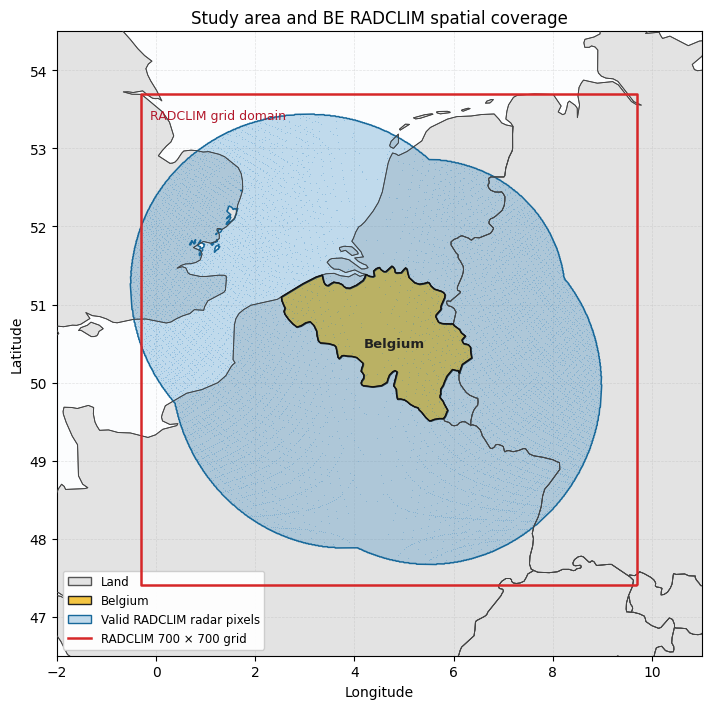

Saved: study_area_radclim_domain_with_mask.png


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import xarray as xr

from shapely.geometry import box
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

%matplotlib inline


# ============================================================
# Paths and RADCLIM settings
# ============================================================

ZARR_PATH = (
    "/data/brussel/vo/000/bvo00029/data/observations/"
    "RADCLIMrates_2017_2023_5m_be_v1/"
    "RADCLIMrates_f16.zarr"
)

VAR_NAME = "precip_intensity_EDK"

# Published approximate geographical extent of the RADCLIM grid
lon_min, lon_max = -0.3, 9.7
lat_min, lat_max = 47.4, 53.7

# Wider map extent used for geographical context
map_lon_min, map_lon_max = -2.0, 11.0
map_lat_min, map_lat_max = 46.5, 54.5


# ============================================================
# Load a representative RADCLIM valid-data footprint
# ============================================================

ds = xr.open_zarr(ZARR_PATH)

if VAR_NAME not in ds:
    raise KeyError(
        f"{VAR_NAME!r} was not found in the Zarr dataset.\n"
        f"Available variables: {list(ds.data_vars)}"
    )

radar = ds[VAR_NAME]

print("RADCLIM dimensions:", radar.dims)
print("RADCLIM shape:", radar.shape)

# Sample a small number of times across the archive.
# This avoids reading the full 700+ GB dataset.
n_sample_times = 24

sample_indices = np.linspace(
    0,
    radar.sizes["time"] - 1,
    n_sample_times,
    dtype=int,
)

sample_fields = radar.isel(time=sample_indices).values

# A pixel belongs to the normal RADCLIM footprint when it contains
# finite data in at least half of the sampled fields.
valid_fraction = np.isfinite(sample_fields).mean(axis=0)
valid_mask = valid_fraction >= 0.5

del sample_fields

print("Valid footprint shape:", valid_mask.shape)
print("Valid fraction of 700 × 700 domain:", valid_mask.mean())


# ============================================================
# Determine geographical coordinates for the mask
# ============================================================

def find_coordinate(dataset, possible_names):
    for name in possible_names:
        if name in dataset.coords:
            return np.asarray(dataset.coords[name])
        if name in dataset:
            return np.asarray(dataset[name])
    return None


longitude = find_coordinate(
    ds,
    ["longitude", "lon", "LONGITUDE", "LON"],
)

latitude = find_coordinate(
    ds,
    ["latitude", "lat", "LATITUDE", "LAT"],
)

if longitude is not None and latitude is not None:
    print("Using longitude and latitude coordinates from the dataset.")

    if longitude.ndim == 1 and latitude.ndim == 1:
        longitude_grid, latitude_grid = np.meshgrid(
            longitude,
            latitude,
        )
    elif longitude.ndim == 2 and latitude.ndim == 2:
        longitude_grid = longitude
        latitude_grid = latitude
    else:
        raise ValueError(
            "Longitude and latitude coordinates have incompatible shapes: "
            f"{longitude.shape} and {latitude.shape}"
        )

else:
    print(
        "No longitude/latitude coordinate arrays were found. "
        "Using the published RADCLIM geographical extent."
    )

    # Row 0 is treated as the northern edge of the radar array.
    longitude_1d = np.linspace(
        lon_min,
        lon_max,
        valid_mask.shape[1],
    )

    latitude_1d = np.linspace(
        lat_max,
        lat_min,
        valid_mask.shape[0],
    )

    longitude_grid, latitude_grid = np.meshgrid(
        longitude_1d,
        latitude_1d,
    )


# ============================================================
# Load geographical boundaries
# ============================================================

natural_earth_url = (
    "https://naturalearth.s3.amazonaws.com/"
    "50m_cultural/ne_50m_admin_0_countries.zip"
)

world = gpd.read_file(natural_earth_url).to_crs("EPSG:4326")

map_extent_polygon = box(
    map_lon_min,
    map_lat_min,
    map_lon_max,
    map_lat_max,
)

# Select all countries intersecting the map extent.
# This includes Switzerland automatically.
region = world[
    world.geometry.intersects(map_extent_polygon)
].copy()

belgium = world[world["NAME"] == "Belgium"].copy()

if belgium.empty:
    raise RuntimeError("Belgium was not found in the Natural Earth dataset.")


# RADCLIM rectangular grid domain
radclim_bbox = box(
    lon_min,
    lat_min,
    lon_max,
    lat_max,
)

radclim_gdf = gpd.GeoDataFrame(
    {"name": ["RADCLIM 700 × 700 domain"]},
    geometry=[radclim_bbox],
    crs="EPSG:4326",
)


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7.2))

# Ocean is controlled independently from the country layer.
ax.set_facecolor("#fcfdfe")

# All land polygons, including Switzerland.
region.plot(
    ax=ax,
    facecolor="#e3e3e3",
    edgecolor="#555555",
    linewidth=0.65,
    zorder=1,
)

# Highlight Belgium.
belgium.plot(
    ax=ax,
    facecolor="#f4c542",
    edgecolor="#222222",
    linewidth=1.0,
    zorder=2,
)

# Transparent invalid pixels and semi-transparent valid pixels.
mask_cmap = ListedColormap(
    [
        (0.0, 0.0, 0.0, 0.0),       # invalid: fully transparent
        (0.15, 0.50, 0.75, 0.28),    # valid: transparent blue
    ]
)

mask_for_plot = valid_mask.astype(np.uint8)

ax.pcolormesh(
    longitude_grid,
    latitude_grid,
    mask_for_plot,
    cmap=mask_cmap,
    vmin=0,
    vmax=1,
    shading="auto",
    zorder=3,
)

# Outline the valid radar footprint.
ax.contour(
    longitude_grid,
    latitude_grid,
    valid_mask.astype(float),
    levels=[0.5],
    colors=["#17689a"],
    linewidths=1.1,
    zorder=4,
)

# Draw country borders again above the transparent mask.
region.boundary.plot(
    ax=ax,
    color="#444444",
    linewidth=0.65,
    zorder=5,
)

belgium.boundary.plot(
    ax=ax,
    color="#111111",
    linewidth=1.0,
    zorder=6,
)

# RADCLIM rectangular grid boundary.
radclim_gdf.boundary.plot(
    ax=ax,
    color="#d62728",
    linewidth=1.8,
    zorder=7,
)

# Belgium label based on the country geometry.
belgium_label_point = belgium.geometry.representative_point().iloc[0]

ax.text(
    belgium_label_point.x,
    belgium_label_point.y,
    "Belgium",
    ha="center",
    va="center",
    fontsize=9.5,
    fontweight="bold",
    color="#222222",
    zorder=8,
)

# Domain label.
ax.text(
    lon_min + 0.18,
    lat_max - 0.20,
    "RADCLIM grid domain",
    color="#b2182b",
    fontsize=9,
    ha="left",
    va="top",
    zorder=8,
)


# ============================================================
# Legend and formatting
# ============================================================

legend_handles = [
    Patch(
        facecolor="#e3e3e3",
        edgecolor="#555555",
        label="Land",
    ),
    Patch(
        facecolor="#f4c542",
        edgecolor="#222222",
        label="Belgium",
    ),
    Patch(
        facecolor=(0.15, 0.50, 0.75, 0.28),
        edgecolor="#17689a",
        label="Valid RADCLIM radar pixels",
    ),
    Line2D(
        [0],
        [0],
        color="#d62728",
        linewidth=1.8,
        label="RADCLIM 700 × 700 grid",
    ),
]

ax.legend(
    handles=legend_handles,
    loc="lower left",
    frameon=True,
    framealpha=0.95,
    fontsize=8.5,
)

ax.set_xlim(map_lon_min, map_lon_max)
ax.set_ylim(map_lat_min, map_lat_max)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Study area and BE RADCLIM spatial coverage")

ax.grid(
    True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.35,
)

plt.tight_layout()

output_path = "study_area_radclim_domain_with_mask.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Saved:", output_path)

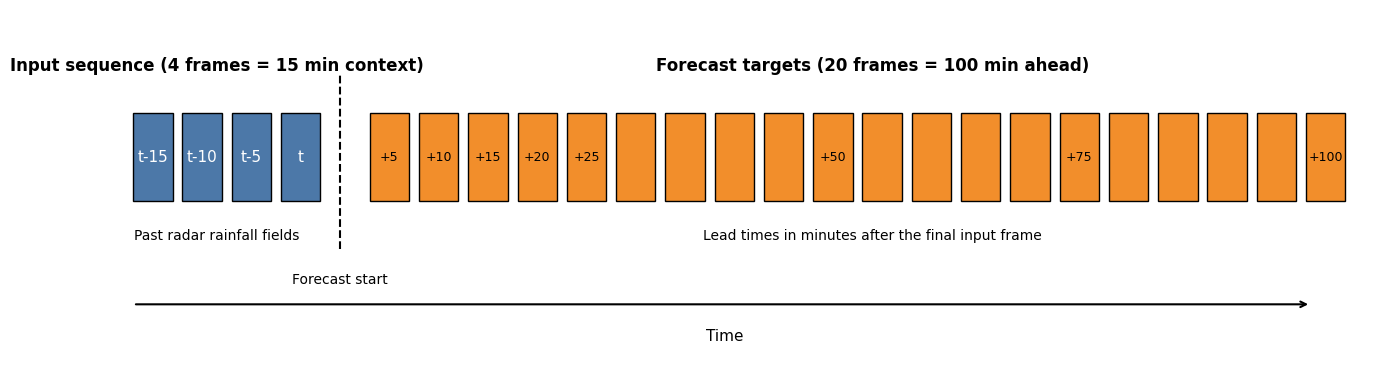

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
%matplotlib inline
# -----------------------------
# Figure settings
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 3.8))
ax.set_xlim(0, 25.5)
ax.set_ylim(0, 2.2)
ax.axis("off")

# -----------------------------
# Parameters
# -----------------------------
box_width = 0.8
box_height = 0.55
y = 1.0

input_color = "#4C78A8"   # blue
target_color = "#F28E2B"  # orange

# -----------------------------
# Input frames
# -----------------------------
input_labels = ["t-15", "t-10", "t-5", "t"]

for i, label in enumerate(input_labels):
    rect = Rectangle((i + 0.5, y), box_width, box_height,
                     facecolor=input_color, edgecolor="black")
    ax.add_patch(rect)
    ax.text(i + 0.5 + box_width/2, y + box_height/2, label,
            ha="center", va="center", fontsize=11, color="white")

# -----------------------------
# Separator line
# -----------------------------
sep_x = 4.7
ax.plot([sep_x, sep_x], [0.7, 1.8], linestyle="--", color="black", linewidth=1.5)
ax.text(sep_x, 0.55, "Forecast start", ha="center", va="top", fontsize=10)

# -----------------------------
# Target frames
# -----------------------------
target_labels = [f"+{5*(i+1)}" for i in range(20)]

for i, label in enumerate(target_labels):
    x = i + 5.3
    rect = Rectangle((x, y), box_width, box_height,
                     facecolor=target_color, edgecolor="black")
    ax.add_patch(rect)

    # show only some labels to avoid clutter
    if i < 5 or i in [9, 14, 19]:
        ax.text(x + box_width/2, y + box_height/2, label,
                ha="center", va="center", fontsize=9, color="black")

# -----------------------------
# Group labels
# -----------------------------
ax.text(2.2, 1.85, "Input sequence (4 frames = 15 min context)",
        ha="center", va="center", fontsize=12, fontweight="bold")

ax.text(15.5, 1.85, "Forecast targets (20 frames = 100 min ahead)",
        ha="center", va="center", fontsize=12, fontweight="bold")

# -----------------------------
# Extra explanation
# -----------------------------
ax.text(2.2, 0.78, "Past radar rainfall fields",
        ha="center", va="center", fontsize=10)

ax.text(15.5, 0.78, "Lead times in minutes after the final input frame",
        ha="center", va="center", fontsize=10)

# -----------------------------
# Optional timeline arrow
# -----------------------------
ax.annotate(
    "", xy=(24.4, 0.35), xytext=(0.5, 0.35),
    arrowprops=dict(arrowstyle="->", linewidth=1.5, color="black")
)
ax.text(12.5, 0.15, "Time", ha="center", va="center", fontsize=11)

# -----------------------------
# Save and show
# -----------------------------
plt.tight_layout()
plt.savefig("input_output_nowcasting_setup.png", dpi=300, bbox_inches="tight")
plt.show()

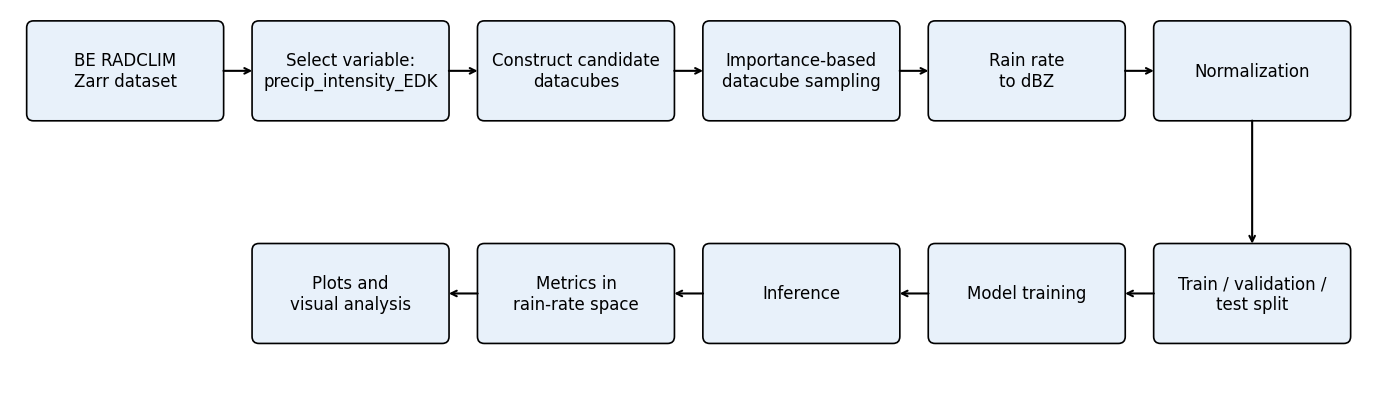

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
%matplotlib inline

# -----------------------------
# Helper function
# -----------------------------
BOX_W = 1.95
BOX_H = 0.95
FONT = 12

def add_box(ax, xy, text, width=BOX_W, height=BOX_H, fc="#E8F1FA", ec="black", fontsize=FONT):
    x, y = xy
    box = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.03,rounding_size=0.07",
        linewidth=1.2, edgecolor=ec, facecolor=fc
    )
    ax.add_patch(box)
    ax.text(
        x + width / 2, y + height / 2,
        text,
        ha="center", va="center",
        fontsize=fontsize,
        wrap=True
    )
    return box

def arrow(ax, start, end):
    ax.annotate(
        "", xy=end, xytext=start,
        arrowprops=dict(arrowstyle="->", lw=1.5, color="black")
    )

# -----------------------------
# Create figure
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 4.0))
ax.set_xlim(0, 14)
ax.set_ylim(4.25, 8.05)
ax.axis("off")

# -----------------------------
# Layout settings
# -----------------------------
x0 = 0.20
gap = 0.35

# Top row x positions
x1 = x0
x2 = x1 + BOX_W + gap
x3 = x2 + BOX_W + gap
x4 = x3 + BOX_W + gap
x5 = x4 + BOX_W + gap
x6 = x5 + BOX_W + gap

y_top = 6.95
y_bot = 4.70

# -----------------------------
# Top row
# -----------------------------
boxes = {}
boxes["radclim"]   = add_box(ax, (x1, y_top), "BE RADCLIM\nZarr dataset")
boxes["select"]    = add_box(ax, (x2, y_top), "Select variable:\nprecip_intensity_EDK")
boxes["cand"]      = add_box(ax, (x3, y_top), "Construct candidate\ndatacubes")
boxes["sample"]    = add_box(ax, (x4, y_top), "Importance-based\ndatacube sampling")
boxes["dbz"]       = add_box(ax, (x5, y_top), "Rain rate\nto dBZ")
boxes["norm"]      = add_box(ax, (x6, y_top), "Normalization")

# -----------------------------
# Bottom row
# -----------------------------
boxes["plots"]     = add_box(ax, (x2, y_bot), "Plots and\nvisual analysis")
boxes["metrics"]   = add_box(ax, (x3, y_bot), "Metrics in\nrain-rate space")
boxes["infer"]     = add_box(ax, (x4, y_bot), "Inference")
boxes["train"]     = add_box(ax, (x5, y_bot), "Model training")
boxes["split"]     = add_box(ax, (x6, y_bot), "Train / validation /\ntest split")

# -----------------------------
# Top row arrows (left to right)
# -----------------------------
arrow(ax, (x1 + BOX_W, y_top + BOX_H/2), (x2, y_top + BOX_H/2))
arrow(ax, (x2 + BOX_W, y_top + BOX_H/2), (x3, y_top + BOX_H/2))
arrow(ax, (x3 + BOX_W, y_top + BOX_H/2), (x4, y_top + BOX_H/2))
arrow(ax, (x4 + BOX_W, y_top + BOX_H/2), (x5, y_top + BOX_H/2))
arrow(ax, (x5 + BOX_W, y_top + BOX_H/2), (x6, y_top + BOX_H/2))

# -----------------------------
# Vertical arrow down
# -----------------------------
arrow(ax, (x6 + BOX_W/2, y_top), (x6 + BOX_W/2, y_bot + BOX_H))

# -----------------------------
# Bottom row arrows (right to left)
# -----------------------------
arrow(ax, (x6, y_bot + BOX_H/2), (x5 + BOX_W, y_bot + BOX_H/2))
arrow(ax, (x5, y_bot + BOX_H/2), (x4 + BOX_W, y_bot + BOX_H/2))
arrow(ax, (x4, y_bot + BOX_H/2), (x3 + BOX_W, y_bot + BOX_H/2))
arrow(ax, (x3, y_bot + BOX_H/2), (x2 + BOX_W, y_bot + BOX_H/2))

# NOTE:
# No final arrow after "Plots and visual analysis"

# -----------------------------
# Save
# -----------------------------
plt.subplots_adjust(left=0.01, right=0.99, top=0.98, bottom=0.04)

plt.savefig(
    "data_preparation_evaluation_pipeline.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.03
)
plt.savefig(
    "data_preparation_evaluation_pipeline.pdf",
    bbox_inches="tight",
    pad_inches=0.03
)

plt.show()

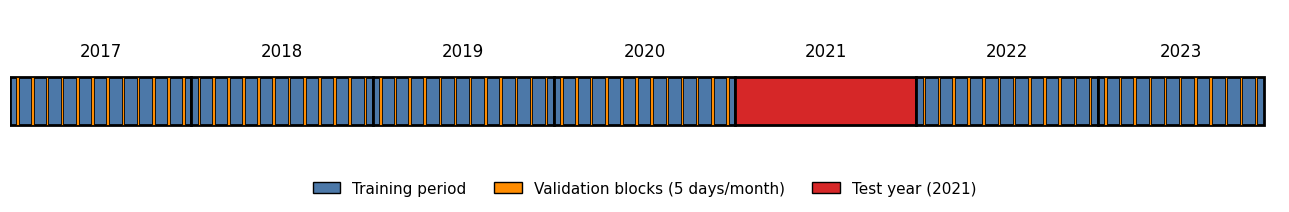

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
import calendar

# -----------------------------
# Settings
# -----------------------------
years = [2017, 2018, 2019, 2020, 2021, 2022, 2023]

train_color = "#4C78A8"   # blue
val_color   = "#FF8C00"   # orange
test_color  = "#D62728"   # red
edge_color  = "black"

fig, ax = plt.subplots(figsize=(13.5, 2.6))
ax.set_xlim(0, len(years))
ax.set_ylim(0, 1.05)
ax.axis("off")

bar_y = 0.42
bar_h = 0.26

# Keep validation blocks visually equal in width
fixed_block_width = 5 / 365.25

# -----------------------------
# Availability settings
# -----------------------------
# Full years except 2023, which ends at November 30
available_months = {
    2017: 12,
    2018: 12,
    2019: 12,
    2020: 12,
    2021: 12,
    2022: 12,
    2023: 11
}

# -----------------------------
# Helper
# -----------------------------
def days_in_year(year):
    return 366 if calendar.isleap(year) else 365

def days_available_in_year(year):
    months = available_months[year]
    return sum(calendar.monthrange(year, m)[1] for m in range(1, months + 1))

# -----------------------------
# Draw bars
# -----------------------------
for i, year in enumerate(years):
    x0 = i
    full_days = days_in_year(year)
    avail_days = days_available_in_year(year)

    # Bar width reflects actual data availability
    bar_width = avail_days / full_days

    # Base color
    base_color = test_color if year == 2021 else train_color

    # Draw year bar
    ax.add_patch(Rectangle(
        (x0, bar_y), bar_width, bar_h,
        facecolor=base_color, edgecolor=edge_color, linewidth=2.0
    ))

    # Add validation blocks for non-test years
    if year != 2021:
        cumulative = 0
        months = available_months[year]

        for m in range(1, months + 1):
            month_len = calendar.monthrange(year, m)[1]

            # Put each 5-day validation block roughly in the middle of the month
            block_center_day = cumulative + month_len / 2

            # Position relative to the full-year scale so 2023 is naturally shorter
            x_center = x0 + block_center_day / full_days
            x_start = x_center - fixed_block_width / 2

            ax.add_patch(Rectangle(
                (x_start, bar_y), fixed_block_width, bar_h,
                facecolor=val_color, edgecolor=edge_color, linewidth=0.6
            ))

            cumulative += month_len

    # Year label centered above actual available bar
    ax.text(
        x0 + bar_width / 2, bar_y + bar_h + 0.09, str(year),
        ha="center", va="bottom", fontsize=12
    )

# -----------------------------
# Legend
# -----------------------------
legend_handles = [
    Patch(facecolor=train_color, edgecolor=edge_color, label="Training period"),
    Patch(facecolor=val_color, edgecolor=edge_color, label="Validation blocks (5 days/month)"),
    Patch(facecolor=test_color, edgecolor=edge_color, label="Test year (2021)")
]

ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.18),
    ncol=3,
    frameon=False,
    fontsize=11,
    handlelength=1.8,
    columnspacing=1.8
)

plt.subplots_adjust(left=0.03, right=0.97, top=0.82, bottom=0.08)

plt.savefig("temporal_split_train_val_test.png", dpi=300, bbox_inches="tight", pad_inches=0.03)
plt.savefig("temporal_split_train_val_test.pdf", bbox_inches="tight", pad_inches=0.03)
plt.show()

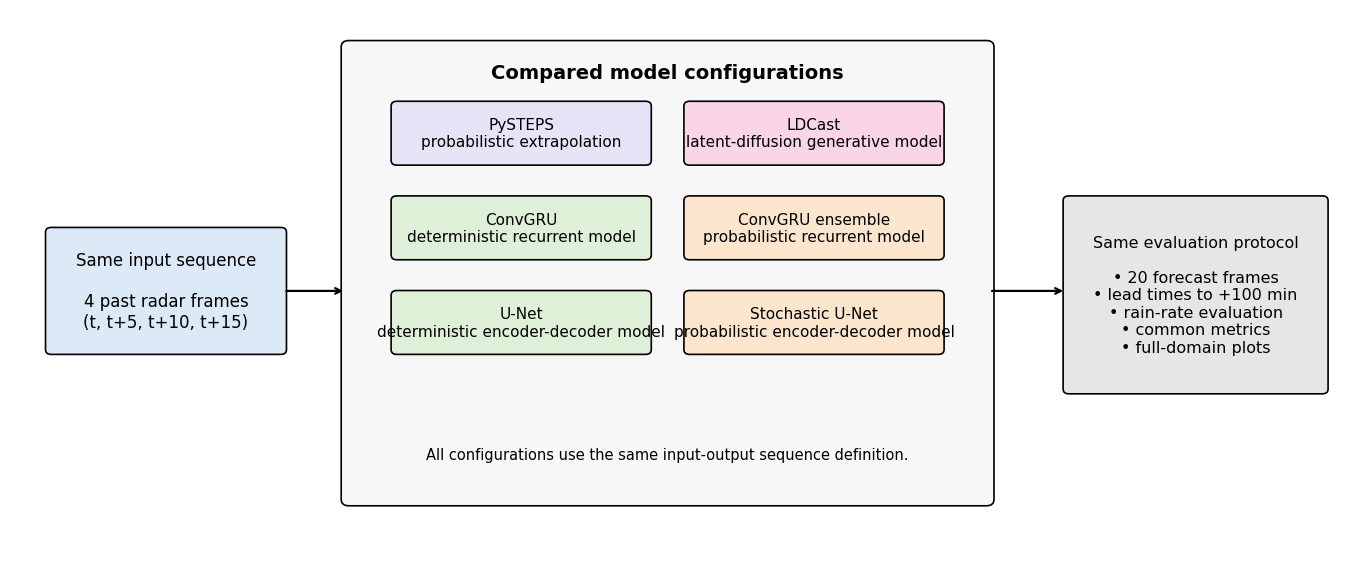

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
%matplotlib inline
# -----------------------------
# Helper functions
# -----------------------------
def add_box(ax, x, y, w, h, text, fc="#E8F1FA", ec="black", fontsize=11.5, lw=1.2):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03,rounding_size=0.06",
        linewidth=lw,
        edgecolor=ec,
        facecolor=fc
    )
    ax.add_patch(box)
    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        wrap=True
    )
    return box

def arrow(ax, start, end, lw=1.6):
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(arrowstyle="->", lw=lw, color="black")
    )

# -----------------------------
# Figure setup
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 6.0))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis("off")

# -----------------------------
# Colors
# -----------------------------
input_color = "#DCEAF7"
eval_color = "#E6E6E6"
group_color = "#F7F7F7"

pysteps_color = "#E8E3F6"
det_color = "#DFF0D8"
ens_color = "#FCE5CD"
ldcast_color = "#F9D5E5"

# -----------------------------
# Left: common input
# -----------------------------
add_box(
    ax, 0.4, 2.65, 2.45, 1.55,
    "Same input sequence\n\n"
    "4 past radar frames\n"
    "(t, t+5, t+10, t+15)",
    fc=input_color,
    fontsize=12
)

# -----------------------------
# Middle: model configurations group
# -----------------------------
group_x, group_y = 3.5, 0.75
group_w, group_h = 6.7, 5.8

group = FancyBboxPatch(
    (group_x, group_y), group_w, group_h,
    boxstyle="round,pad=0.05,rounding_size=0.08",
    linewidth=1.2,
    edgecolor="black",
    facecolor=group_color
)
ax.add_patch(group)

ax.text(
    group_x + group_w / 2,
    group_y + group_h - 0.35,
    "Compared model configurations",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold"
)

# Model boxes: two columns, three rows
box_w = 2.65
box_h = 0.75

left_x = 4.0
right_x = 7.05

ys = [5.05, 3.85, 2.65]

add_box(ax, left_x,  ys[0], box_w, box_h,
        "PySTEPS\nprobabilistic extrapolation",
        fc=pysteps_color, fontsize=11)

add_box(ax, right_x, ys[0], box_w, box_h,
        "LDCast\nlatent-diffusion generative model",
        fc=ldcast_color, fontsize=11)

add_box(ax, left_x,  ys[1], box_w, box_h,
        "ConvGRU\ndeterministic recurrent model",
        fc=det_color, fontsize=11)

add_box(ax, right_x, ys[1], box_w, box_h,
        "ConvGRU ensemble\nprobabilistic recurrent model",
        fc=ens_color, fontsize=11)

add_box(ax, left_x,  ys[2], box_w, box_h,
        "U-Net\ndeterministic encoder-decoder model",
        fc=det_color, fontsize=11)

add_box(ax, right_x, ys[2], box_w, box_h,
        "Stochastic U-Net\nprobabilistic encoder-decoder model",
        fc=ens_color, fontsize=11)

# Small note at bottom of group
ax.text(
    group_x + group_w / 2,
    1.35,
    "All configurations use the same input-output sequence definition.",
    ha="center",
    va="center",
    fontsize=10.5
)

# -----------------------------
# Right: common evaluation
# -----------------------------
add_box(
    ax, 11.0, 2.15, 2.7, 2.45,
    "Same evaluation protocol\n\n"
    "• 20 forecast frames\n"
    "• lead times to +100 min\n"
    "• rain-rate evaluation\n"
    "• common metrics\n"
    "• full-domain plots",
    fc=eval_color,
    fontsize=11.5
)

# -----------------------------
# Main arrows only
# -----------------------------
arrow(ax, (2.85, 3.425), (3.5, 3.425))
arrow(ax, (10.2, 3.425), (11.0, 3.425))

# -----------------------------
# Save
# -----------------------------
plt.subplots_adjust(left=0.02, right=0.98, top=0.96, bottom=0.04)

plt.savefig("model_comparison_overview.png", dpi=300, bbox_inches="tight", pad_inches=0.03)
plt.savefig("model_comparison_overview.pdf", bbox_inches="tight", pad_inches=0.03)

plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import xarray as xr

# =========================================================
# DATA SETTINGS
# =========================================================
zarr_path = (
    "/data/brussel/vo/000/bvo00029/data/observations/"
    "RADCLIMrates_2017_2023_5m_be_v1/"
    "RADCLIMrates_f16.zarr"
)

var_name = "precip_intensity_EDK"

# First frame of the four-frame input sequence
t0 = 1000

y_slice = slice(180, 308)
x_slice = slice(220, 348)


# =========================================================
# PRECIPITATION COLOUR MAP
# =========================================================
def get_precip_cmap_norm():
    colors = [
        "white",
        "cyan",
        "deepskyblue",
        "dodgerblue",
        "blue",
        "chartreuse",
        "limegreen",
        "green",
        "darkgreen",
        "yellow",
        "gold",
        "orange",
        "red",
        "magenta",
        "darkmagenta",
    ]

    levels = [
        0.0, 0.1, 0.25, 0.4, 0.63,
        1.0, 1.6, 2.5, 4.0, 6.3,
        10.0, 16.0, 25.0, 40.0,
        63.0, 100.0,
    ]

    cmap = mcolors.ListedColormap(colors)
    cmap.set_bad(color=(1, 1, 1, 0))

    norm = mcolors.BoundaryNorm(
        levels,
        cmap.N,
        clip=True,
    )

    return cmap, norm, levels


PRECIP_CMAP, PRECIP_NORM, PRECIP_LEVELS = (
    get_precip_cmap_norm()
)


# =========================================================
# FRAME PREPARATION
# =========================================================
def prepare_frame(arr, input_space="rainrate"):
    arr = np.asarray(arr, dtype=np.float32)

    arr = np.nan_to_num(
        arr,
        nan=0.0,
        posinf=100.0,
        neginf=0.0,
    )

    arr = np.clip(arr, 0.0, 100.0)

    return arr


# =========================================================
# LOAD RADCLIM
# =========================================================
ds = xr.open_zarr(zarr_path)
da = ds[var_name]

time_dim = [
    d for d in da.dims
    if "time" in d.lower()
][0]

spatial_dims = [
    d for d in da.dims
    if d != time_dim
]

y_dim, x_dim = spatial_dims[-2], spatial_dims[-1]


def get_frame(idx):
    frame = da.isel({
        time_dim: idx,
        y_dim: y_slice,
        x_dim: x_slice,
    }).values

    return prepare_frame(frame)


# Four observed input frames
input_frames = [
    get_frame(t0 + i)
    for i in range(4)
]

# Illustrative following frames
pred_frame_1 = get_frame(t0 + 4)
pred_frame_2 = get_frame(t0 + 5)
# =========================================================
# FINAL U-NET ARCHITECTURE + AUTOREGRESSIVE ROLLOUT FIGURE
#
# Run this in one cell after loading:
#   input_frames
#   pred_frame_1
#   pred_frame_2
#   prepare_frame
#   PRECIP_CMAP
#   PRECIP_NORM
# =========================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


# =========================================================
# Figure canvas
# =========================================================

fig, ax = plt.subplots(figsize=(20, 10))

ax.set_xlim(0, 24)
ax.set_ylim(0, 12)
ax.axis("off")


# =========================================================
# Title
# =========================================================

ax.text(
    12,
    11.55,
    "U-Net architecture and autoregressive rollout",
    ha="center",
    va="center",
    fontsize=26,
    fontweight="bold",
)


# =========================================================
# Colours
# =========================================================

enc_fc = "#d9e9fb"
enc_ec = "#5b8bd6"

pool_fc = "#efe5fb"
pool_ec = "#b38ac7"

dec_fc = "#dff0d9"
dec_ec = "#75b85b"

out_fc = "#fff3cf"
out_ec = "#d4ad31"

ensemble_fc = "#f4ecfa"
ensemble_ec = "#8357ae"

green_arrow = "#2f7d32"

blue_text = "#214aa8"
green_text = "#2f7d32"


# =========================================================
# Helper functions
# =========================================================

def box(
    ax,
    x,
    y,
    w,
    h,
    text,
    fc="white",
    ec="black",
    lw=1.2,
    fontsize=11,
    weight="bold",
    zorder=3,
    boxstyle="round,pad=0.03,rounding_size=0.08",
):
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle=boxstyle,
        linewidth=lw,
        edgecolor=ec,
        facecolor=fc,
        zorder=zorder,
    )

    ax.add_patch(patch)

    if text:
        ax.text(
            x + w / 2,
            y + h / 2,
            text,
            ha="center",
            va="center",
            fontsize=fontsize,
            fontweight=weight,
            zorder=zorder + 1,
        )

    return patch


def dashed_region(
    ax,
    x,
    y,
    w,
    h,
    label,
    color,
):
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.04,rounding_size=0.10",
        linewidth=1.1,
        edgecolor=color,
        facecolor="none",
        linestyle=(0, (2, 2)),
        zorder=1,
    )

    ax.add_patch(patch)

    ax.text(
        x + w / 2,
        y + h + 0.15,
        label,
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color=color,
    )


def arrow(
    ax,
    x1,
    y1,
    x2,
    y2,
    color="black",
    lw=1.35,
    mutation_scale=12,
    zorder=4,
):
    arr = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="-|>",
        mutation_scale=mutation_scale,
        linewidth=lw,
        color=color,
        shrinkA=0,
        shrinkB=0,
        zorder=zorder,
    )

    ax.add_patch(arr)

    return arr


def line(
    ax,
    x1,
    y1,
    x2,
    y2,
    color="black",
    lw=1.2,
    zorder=3,
):
    ax.plot(
        [x1, x2],
        [y1, y2],
        color=color,
        lw=lw,
        zorder=zorder,
    )


def routed_arrow(
    ax,
    pts,
    color="black",
    lw=1.2,
    mutation_scale=12,
    zorder=4,
):
    """
    Draw an arrow through several points.
    Intermediate segments are plain lines;
    the final segment has the arrow head.
    """

    for p1, p2 in zip(
        pts[:-2],
        pts[1:-1],
    ):
        line(
            ax,
            p1[0],
            p1[1],
            p2[0],
            p2[1],
            color=color,
            lw=lw,
            zorder=zorder,
        )

    p1, p2 = pts[-2], pts[-1]

    arrow(
        ax,
        p1[0],
        p1[1],
        p2[0],
        p2[1],
        color=color,
        lw=lw,
        mutation_scale=mutation_scale,
        zorder=zorder,
    )


def add_precip_thumb_data(
    ax,
    arr,
    x,
    y,
    w,
    h,
    bordercolor="0.65",
    lw=0.8,
):
    """
    Add a precipitation thumbnail using data coordinates.
    """

    ax_img = ax.inset_axes(
        [x, y, w, h],
        transform=ax.transData,
    )

    ax_img.imshow(
        prepare_frame(
            arr,
            input_space="rainrate",
        ),
        cmap=PRECIP_CMAP,
        norm=PRECIP_NORM,
        origin="upper",
        interpolation="nearest",
    )

    ax_img.set_xticks([])
    ax_img.set_yticks([])

    for s in ax_img.spines.values():
        s.set_edgecolor(bordercolor)
        s.set_linewidth(lw)

    return ax_img


def add_input_stack(
    ax,
    frames,
    x,
    y,
    w,
    h,
    dx=0.25,
    dy=0.58,
):
    # Four observed input frames:
    # t-15, t-10, t-5, t0
    labels = [
        r"$t{-}15\,\mathrm{min}$",
        r"$t{-}10\,\mathrm{min}$",
        r"$t{-}5\,\mathrm{min}$",
        r"$t_0$",
    ]

    # Draw back to front
    for i in reversed(range(4)):

        xi = x + i * dx
        yi = y + (3 - i) * dy

        add_precip_thumb_data(
            ax,
            frames[i],
            xi,
            yi,
            w,
            h,
            bordercolor="0.55",
            lw=0.8,
        )

        ax.text(
            x - 0.45,
            yi + h / 2,
            labels[i],
            ha="right",
            va="center",
            fontsize=10.5,
            fontweight="bold",
        )

    ax.text(
        x + w / 2 + 1.5 * dx,
        y - 0.35,
        r"$H \times W$",
        ha="center",
        va="top",
        fontsize=14,
        fontweight="bold",
    )


def mini_frame_row(
    ax,
    frames,
    x,
    y,
    w,
    h,
    gap,
    labels,
    crossed=None,
    highlight_idx=None,
):
    for i, fr in enumerate(frames):

        xi = x + i * (w + gap)

        ax_img = add_precip_thumb_data(
            ax,
            fr,
            xi,
            y,
            w,
            h,
            bordercolor="0.65",
            lw=0.7,
        )

        if crossed is not None and i in crossed:

            ax_img.plot(
                [0, 1],
                [0, 1],
                transform=ax_img.transAxes,
                color="0.55",
                lw=1.0,
            )

            ax_img.plot(
                [0, 1],
                [1, 0],
                transform=ax_img.transAxes,
                color="0.55",
                lw=1.0,
            )

        if (
            highlight_idx is not None
            and i == highlight_idx
        ):
            for s in ax_img.spines.values():
                s.set_edgecolor("#d4a017")
                s.set_linewidth(1.4)

        ax.text(
            xi + w / 2,
            y - 0.12,
            labels[i],
            ha="center",
            va="top",
            fontsize=8.5,
        )


# =========================================================
# LEFT: input block
# =========================================================

ax.text(
    1.9,
    9.30,
    "Stacked input frames\n(4 channels)",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold",
)

add_input_stack(
    ax,
    input_frames,
    x=1.25,
    y=4.40,
    w=0.90,
    h=0.85,
    dx=0.23,
    dy=0.58,
)

arrow(
    ax,
    3.15,
    6.15,
    4.05,
    6.15,
    lw=1.4,
)

box(
    ax,
    0.55,
    2.05,
    2.70,
    0.65,
    "Past frames are stacked along\n"
    "the channel dimension.",
    fc="#f4f4f4",
    ec="0.55",
    lw=0.9,
    fontsize=9.5,
    weight="normal",
)


# =========================================================
# Main U-Net regions
# =========================================================

dashed_region(
    ax,
    4.20,
    1.85,
    4.10,
    8.55,
    "Encoder",
    enc_ec,
)

dashed_region(
    ax,
    8.70,
    1.85,
    3.20,
    8.55,
    "Bottleneck",
    pool_ec,
)

dashed_region(
    ax,
    12.30,
    1.85,
    4.10,
    8.55,
    "Decoder",
    dec_ec,
)


# =========================================================
# Geometry
# =========================================================

w_block = 2.35
h_block = 0.72

w_small = 1.15
h_small = 0.48


# Encoder

x_enc = 5.25
enc_cx = x_enc + w_block / 2

x_pool = (
    enc_cx
    - w_small / 2
)


# Bottleneck

x_bot = 9.25
bot_y = 2.35


# Decoder

x_dec = 13.10
dec_cx = x_dec + w_block / 2

x_up = (
    dec_cx
    - w_small / 2
)


levels_y = [
    9.20,
    7.25,
    5.30,
    3.35,
]

dec_y = [
    3.35,
    5.30,
    7.25,
    9.20,
]


channels = [
    32,
    64,
    128,
    256,
]

sizes = [
    r"$H \times W$",
    r"$H/2 \times W/2$",
    r"$H/4 \times W/4$",
    r"$H/8 \times W/8$",
]


# =========================================================
# Encoder
#
# Four encoder levels:
# 32 -> 64 -> 128 -> 256
#
# Importantly, there are FOUR MaxPool operations:
# the fourth goes from 256 channels to the
# 512-channel bottleneck.
# =========================================================

for i, (yy, ch, sz) in enumerate(
    zip(
        levels_y,
        channels,
        sizes,
    )
):

    ax.text(
        4.65,
        yy + 0.12,
        f"{ch}\nchannels",
        ha="center",
        va="center",
        fontsize=11,
        color=blue_text,
        fontweight="bold",
    )

    ax.text(
        4.65,
        yy - 0.28,
        sz,
        ha="center",
        va="center",
        fontsize=10.5,
    )

    # DoubleConv block
    box(
        ax,
        x_enc,
        yy - h_block / 2,
        w_block,
        h_block,
        "DoubleConv",
        fc=enc_fc,
        ec=enc_ec,
        lw=1.2,
        fontsize=11.5,
    )

    # MaxPool after every encoder level,
    # including the 256 -> 512 bottleneck transition.
    pool_y = yy - 0.95

    box(
        ax,
        x_pool,
        pool_y - h_small / 2,
        w_small,
        h_small,
        "MaxPool\n2×2",
        fc=pool_fc,
        ec=pool_ec,
        lw=1.0,
        fontsize=8.8,
    )

    # DoubleConv -> MaxPool
    arrow(
        ax,
        enc_cx,
        yy - h_block / 2,
        enc_cx,
        pool_y + h_small / 2,
        lw=1.05,
        mutation_scale=10,
    )

    # MaxPool -> next encoder level
    if i < 3:

        next_y = levels_y[i + 1]

        arrow(
            ax,
            enc_cx,
            pool_y - h_small / 2,
            enc_cx,
            next_y + h_block / 2,
            lw=1.05,
            mutation_scale=10,
        )


# =========================================================
# Bottleneck
# =========================================================

ax.text(
    8.55,
    bot_y + 0.14,
    "512\nchannels",
    ha="center",
    va="center",
    fontsize=11,
    color=blue_text,
    fontweight="bold",
)

ax.text(
    8.55,
    bot_y - 0.28,
    r"$H/16 \times W/16$",
    ha="center",
    va="center",
    fontsize=10.5,
)


# Output of the fourth MaxPool

last_pool_y = (
    levels_y[-1]
    - 0.95
)

routed_arrow(
    ax,
    [
        (
            enc_cx,
            last_pool_y - h_small / 2,
        ),
        (
            enc_cx,
            bot_y,
        ),
        (
            x_bot,
            bot_y,
        ),
    ],
    color="black",
    lw=1.1,
    mutation_scale=10,
)


box(
    ax,
    x_bot,
    bot_y - h_block / 2,
    w_block,
    h_block,
    "DoubleConv",
    fc=enc_fc,
    ec=enc_ec,
    lw=1.2,
    fontsize=11.5,
)


# =========================================================
# Decoder DoubleConv blocks
# =========================================================

dec_channels = [
    256,
    128,
    64,
    32,
]

dec_sizes = [
    r"$H/8 \times W/8$",
    r"$H/4 \times W/4$",
    r"$H/2 \times W/2$",
    r"$H \times W$",
]


for yy, ch, sz in zip(
    dec_y,
    dec_channels,
    dec_sizes,
):

    box(
        ax,
        x_dec,
        yy - h_block / 2,
        w_block,
        h_block,
        "DoubleConv",
        fc=dec_fc,
        ec=dec_ec,
        lw=1.2,
        fontsize=11.5,
    )

    ax.text(
        15.85,
        yy + 0.12,
        f"{ch}\nchannels",
        ha="center",
        va="center",
        fontsize=11,
        color=green_text,
        fontweight="bold",
    )

    ax.text(
        15.85,
        yy - 0.28,
        sz,
        ha="center",
        va="center",
        fontsize=10.5,
    )


# =========================================================
# Decoder UpConv path
#
# Four UpConv operations:
# 512 -> 256 -> 128 -> 64 -> 32
# =========================================================

up_y = [
    2.85,
    4.40,
    6.35,
    8.30,
]


# ---------------------------------------------------------
# FIRST UpConv:
# bottleneck 512 -> decoder 256
# ---------------------------------------------------------

box(
    ax,
    x_up,
    up_y[0] - h_small / 2,
    w_small,
    h_small,
    "UpConv\n2×2",
    fc="#ebf5e6",
    ec=dec_ec,
    lw=1.0,
    fontsize=8.8,
)

routed_arrow(
    ax,
    [
        (
            x_bot + w_block,
            bot_y,
        ),
        (
            dec_cx,
            bot_y,
        ),
        (
            dec_cx,
            up_y[0] - h_small / 2,
        ),
    ],
    color=green_arrow,
    lw=1.15,
    mutation_scale=10,
)

arrow(
    ax,
    dec_cx,
    up_y[0] + h_small / 2,
    dec_cx,
    dec_y[0] - h_block / 2,
    color=green_arrow,
    lw=1.15,
    mutation_scale=10,
)


# ---------------------------------------------------------
# Remaining three UpConv stages
# ---------------------------------------------------------

for i in range(1, 4):

    box(
        ax,
        x_up,
        up_y[i] - h_small / 2,
        w_small,
        h_small,
        "UpConv\n2×2",
        fc="#ebf5e6",
        ec=dec_ec,
        lw=1.0,
        fontsize=8.8,
    )

    # Decoder block -> UpConv
    arrow(
        ax,
        dec_cx,
        dec_y[i - 1] + h_block / 2,
        dec_cx,
        up_y[i] - h_small / 2,
        color=green_arrow,
        lw=1.15,
        mutation_scale=10,
    )

    # UpConv -> next decoder block
    arrow(
        ax,
        dec_cx,
        up_y[i] + h_small / 2,
        dec_cx,
        dec_y[i] - h_block / 2,
        color=green_arrow,
        lw=1.15,
        mutation_scale=10,
    )


# =========================================================
# Skip connections
# =========================================================

skip_pairs = [
    (
        levels_y[0],
        dec_y[3],
    ),
    (
        levels_y[1],
        dec_y[2],
    ),
    (
        levels_y[2],
        dec_y[1],
    ),
    (
        levels_y[3],
        dec_y[0],
    ),
]


for y_left, y_right in skip_pairs:

    arrow(
        ax,
        x_enc + w_block,
        y_left,
        x_dec,
        y_right,
        color="black",
        lw=1.15,
        mutation_scale=11,
    )


ax.text(
    10.30,
    9.45,
    "skip connection",
    ha="center",
    va="bottom",
    fontsize=11,
    style="italic",
)


# =========================================================
# Output convolution and first prediction
# =========================================================

x_out = 16.90
w_out = 1.75


box(
    ax,
    x_out,
    levels_y[0] - h_block / 2,
    w_out,
    h_block,
    "Output conv\n1×1",
    fc=out_fc,
    ec=out_ec,
    lw=1.1,
    fontsize=10.5,
)


arrow(
    ax,
    x_dec + w_block,
    levels_y[0],
    x_out,
    levels_y[0],
    lw=1.2,
    mutation_scale=11,
)


ax.text(
    20.25,
    10.05,
    "One-step\nprediction\n(+5 min)",
    ha="center",
    va="center",
    fontsize=16.5,
    fontweight="bold",
)


arrow(
    ax,
    x_out + w_out,
    levels_y[0],
    19.70,
    levels_y[0],
    lw=1.2,
    mutation_scale=11,
)


add_precip_thumb_data(
    ax,
    pred_frame_1,
    x=20.00,
    y=8.15,
    w=0.95,
    h=0.90,
    bordercolor="0.60",
    lw=0.9,
)


ax.text(
    20.48,
    7.80,
    r"$H \times W$",
    ha="center",
    va="center",
    fontsize=12.5,
)


# =========================================================
# Autoregressive rollout panel
# =========================================================

panel_x = 18.95
panel_y = 2.10
panel_w = 4.35
panel_h = 5.60


box(
    ax,
    panel_x,
    panel_y,
    panel_w,
    panel_h,
    "",
    fc="white",
    ec="#173a99",
    lw=1.4,
    fontsize=10,
    boxstyle="round,pad=0.05,rounding_size=0.10",
)


ax.text(
    panel_x + panel_w / 2,
    panel_y + panel_h - 0.35,
    "Autoregressive rollout",
    ha="center",
    va="center",
    fontsize=15.5,
    fontweight="bold",
    color="#173a99",
)


ax.text(
    panel_x + 1.30,
    panel_y + panel_h - 1.00,
    "Input window\n(4 frames)",
    ha="center",
    va="center",
    fontsize=9.8,
    fontweight="bold",
)


ax.text(
    panel_x + 3.15,
    panel_y + panel_h - 1.00,
    "Predict next\nframe (+5 min)",
    ha="center",
    va="center",
    fontsize=9.8,
    fontweight="bold",
)


mini_w = 0.34
mini_h = 0.32
mini_gap = 0.08


# ---------------------------------------------------------
# Initial four-frame input window
# ---------------------------------------------------------

mini_frame_row(
    ax,
    input_frames,
    x=panel_x + 0.60,
    y=panel_y + 4.00,
    w=mini_w,
    h=mini_h,
    gap=mini_gap,
    labels=[
        r"$t{-}15$",
        r"$t{-}10$",
        r"$t{-}5$",
        r"$t_0$",
    ],
)


# First predicted frame

add_precip_thumb_data(
    ax,
    pred_frame_1,
    panel_x + 3.05,
    panel_y + 4.00,
    0.40,
    mini_h,
    bordercolor="#7aa35e",
    lw=0.9,
)


arrow(
    ax,
    panel_x + 2.28,
    panel_y + 4.16,
    panel_x + 2.93,
    panel_y + 4.16,
    lw=1.0,
    mutation_scale=9,
)


ax.text(
    panel_x + 3.25,
    panel_y + 3.72,
    r"$t{+}5$",
    ha="center",
    va="top",
    fontsize=8.5,
)


arrow(
    ax,
    panel_x + 3.25,
    panel_y + 3.90,
    panel_x + 3.25,
    panel_y + 3.35,
    lw=1.0,
    mutation_scale=9,
)


ax.text(
    panel_x + panel_w / 2,
    panel_y + 3.15,
    "Slide window: drop oldest,\nappend prediction",
    ha="center",
    va="center",
    fontsize=9.6,
    fontweight="bold",
)


# ---------------------------------------------------------
# Show the window update
#
# t-15 is removed,
# t+5 is appended.
# ---------------------------------------------------------

row2 = [
    input_frames[0],
    input_frames[1],
    input_frames[2],
    input_frames[3],
    pred_frame_1,
]


mini_frame_row(
    ax,
    row2,
    x=panel_x + 0.55,
    y=panel_y + 2.30,
    w=mini_w,
    h=mini_h,
    gap=mini_gap,
    labels=[
        r"$t{-}15$",
        r"$t{-}10$",
        r"$t{-}5$",
        r"$t_0$",
        r"$t{+}5$",
    ],
    crossed={0},
    highlight_idx=4,
)


ax.text(
    panel_x + panel_w / 2,
    panel_y + 1.65,
    "Repeat",
    ha="center",
    va="center",
    fontsize=10.8,
    fontweight="bold",
)


ax.text(
    panel_x + panel_w / 2,
    panel_y + 1.25,
    "⋯",
    ha="center",
    va="center",
    fontsize=18,
)


arrow(
    ax,
    panel_x + 1.85,
    panel_y + 1.25,
    panel_x + 2.75,
    panel_y + 1.25,
    lw=1.0,
    mutation_scale=9,
)


# Example of the following prediction (+10 min)

add_precip_thumb_data(
    ax,
    pred_frame_2,
    panel_x + 3.10,
    panel_y + 0.95,
    0.40,
    mini_h,
    bordercolor="#7aa35e",
    lw=0.9,
)


ax.text(
    panel_x + 3.30,
    panel_y + 0.78,
    r"$t{+}10$",
    ha="center",
    va="top",
    fontsize=8.5,
)


# =========================================================
# Blue recurrence indicator
# =========================================================

loop_x = (
    panel_x
    + panel_w
    + 0.22
)

top_y = (
    panel_y
    + 4.25
)

bot_y_loop = (
    panel_y
    + 1.25
)


line(
    ax,
    loop_x,
    bot_y_loop,
    loop_x,
    top_y,
    color="#173a99",
    lw=2.0,
    zorder=4,
)


arrow(
    ax,
    loop_x,
    top_y,
    panel_x + panel_w - 0.05,
    top_y,
    color="#173a99",
    lw=2.0,
    mutation_scale=12,
)


arrow(
    ax,
    loop_x,
    bot_y_loop,
    panel_x + panel_w - 0.05,
    bot_y_loop,
    color="#173a99",
    lw=2.0,
    mutation_scale=12,
)


ax.text(
    panel_x + panel_w / 2,
    panel_y + 0.55,
    "Repeat to produce\n"
    "20 forecast frames\n"
    "from +5 to +100 min",
    ha="center",
    va="center",
    fontsize=13.2,
    fontweight="bold",
    color="#173a99",
)


ax.text(
    panel_x + panel_w / 2,
    panel_y + 0.15,
    "(one future frame every 5 min)",
    ha="center",
    va="center",
    fontsize=8.8,
    fontweight="bold",
    color="#173a99",
)


# =========================================================
# Architecture legend
# =========================================================

legend_x = 0.70
legend_y = 0.45
legend_w = 17.70
legend_h = 1.10


legend_patch = FancyBboxPatch(
    (
        legend_x,
        legend_y,
    ),
    legend_w,
    legend_h,
    boxstyle="round,pad=0.06,rounding_size=0.08",
    linewidth=1.0,
    edgecolor="0.35",
    facecolor="white",
    linestyle=(0, (3, 2)),
    zorder=1,
)

ax.add_patch(
    legend_patch
)


# DoubleConv

box(
    ax,
    1.00,
    0.80,
    1.50,
    0.36,
    "DoubleConv",
    fc=enc_fc,
    ec=enc_ec,
    lw=1.0,
    fontsize=8.5,
)


ax.text(
    2.65,
    0.98,
    "two 3×3 conv + ReLU layers; no BatchNorm",
    ha="left",
    va="center",
    fontsize=9.1,
)


# MaxPool

box(
    ax,
    6.15,
    0.80,
    1.30,
    0.36,
    "MaxPool\n2×2",
    fc=pool_fc,
    ec=pool_ec,
    lw=1.0,
    fontsize=8.0,
)


ax.text(
    7.65,
    0.98,
    "downsampling by 2",
    ha="left",
    va="center",
    fontsize=9.1,
)


# UpConv

box(
    ax,
    10.15,
    0.80,
    1.30,
    0.36,
    "UpConv\n2×2",
    fc="#ebf5e6",
    ec=dec_ec,
    lw=1.0,
    fontsize=8.0,
)


ax.text(
    11.65,
    0.98,
    "transposed convolution, stride 2",
    ha="left",
    va="center",
    fontsize=9.1,
)


# Skip connection

arrow(
    ax,
    15.55,
    0.98,
    16.25,
    0.98,
    lw=1.1,
)


ax.text(
    16.40,
    0.98,
    "skip connection",
    ha="left",
    va="center",
    fontsize=9.1,
)


# =========================================================
# U-Net ensemble variant note
# =========================================================

ensemble_note = FancyBboxPatch(
    (
        18.95,
        0.45,
    ),
    4.35,
    1.10,
    boxstyle="round,pad=0.05,rounding_size=0.10",
    linewidth=1.1,
    edgecolor=ensemble_ec,
    facecolor=ensemble_fc,
    zorder=1,
)

ax.add_patch(
    ensemble_note
)


ax.text(
    21.125,
    1.27,
    "U-Net ensemble variant",
    ha="center",
    va="center",
    fontsize=10.5,
    fontweight="bold",
    color=ensemble_ec,
)


ax.text(
    21.125,
    0.86,
    "4 Gaussian noise channels are concatenated\n"
    "before each one-step prediction; independent\n"
    "noise is used for each member and rollout step.",
    ha="center",
    va="center",
    fontsize=8.1,
    color="0.30",
)


# =========================================================
# Bottom explanatory sentence
# =========================================================

ax.text(
    9.20,
    0.17,
    "The model predicts one future frame at a time; "
    "the 20-frame forecast sequence is generated autoregressively.",
    ha="center",
    va="center",
    fontsize=11.5,
    style="italic",
)


# =========================================================
# Save
# =========================================================

out_png = (
    "u_net_architecture_autoregressive_final.png"
)

out_pdf = (
    "u_net_architecture_autoregressive_final.pdf"
)


fig.savefig(
    out_png,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.04,
)


fig.savefig(
    out_pdf,
    bbox_inches="tight",
    pad_inches=0.04,
)


print(
    f"Saved PNG: {out_png}"
)

print(
    f"Saved PDF: {out_pdf}"
)


plt.show()

Saved PNG: u_net_architecture_autoregressive_final.png
Saved PDF: u_net_architecture_autoregressive_final.pdf


In [19]:
import sys
!{sys.executable} -m pip install python-pptx pillow

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 142.9 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


NameError: name 'input_frames' is not defined

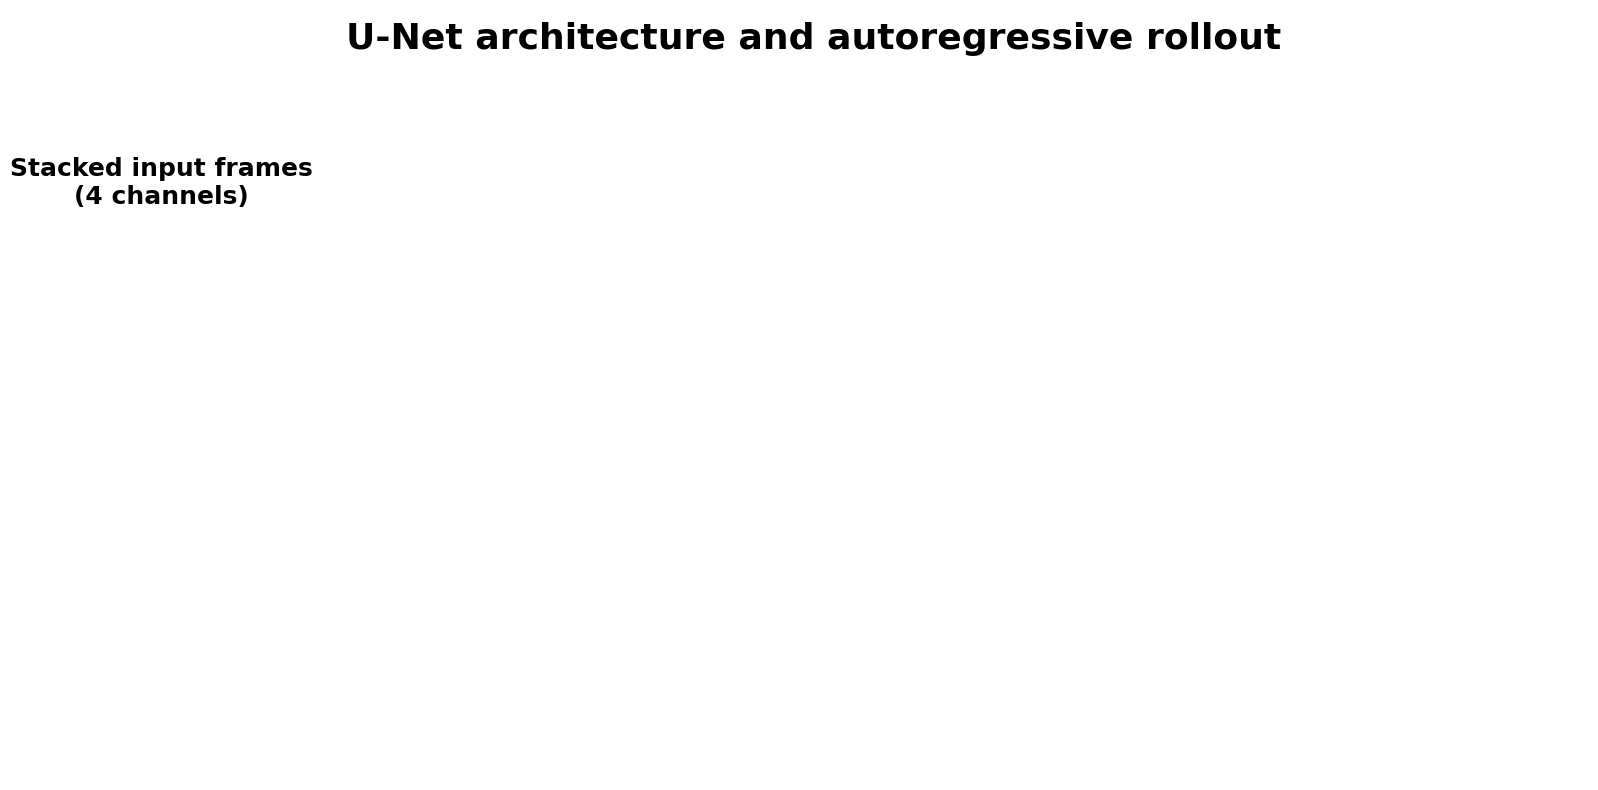

In [3]:
# =========================================================
# FINAL U-NET ARCHITECTURE + AUTOREGRESSIVE ROLLOUT FIGURE
#
# Run this in one cell after loading:
#   input_frames
#   pred_frame_1
#   pred_frame_2
#   prepare_frame
#   PRECIP_CMAP
#   PRECIP_NORM
# =========================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
%matplotlib inline

# =========================================================
# Figure canvas
# =========================================================

fig, ax = plt.subplots(figsize=(20, 10))

ax.set_xlim(0, 24)
ax.set_ylim(0, 12)
ax.axis("off")


# =========================================================
# Title
# =========================================================

ax.text(
    12,
    11.55,
    "U-Net architecture and autoregressive rollout",
    ha="center",
    va="center",
    fontsize=26,
    fontweight="bold",
)


# =========================================================
# Colours
# =========================================================

enc_fc = "#d9e9fb"
enc_ec = "#5b8bd6"

pool_fc = "#efe5fb"
pool_ec = "#b38ac7"

dec_fc = "#dff0d9"
dec_ec = "#75b85b"

out_fc = "#fff3cf"
out_ec = "#d4ad31"

ensemble_fc = "#f4ecfa"
ensemble_ec = "#8357ae"

green_arrow = "#2f7d32"

blue_text = "#214aa8"
green_text = "#2f7d32"


# =========================================================
# Helper functions
# =========================================================

def box(
    ax,
    x,
    y,
    w,
    h,
    text,
    fc="white",
    ec="black",
    lw=1.2,
    fontsize=11,
    weight="bold",
    zorder=3,
    boxstyle="round,pad=0.03,rounding_size=0.08",
):
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle=boxstyle,
        linewidth=lw,
        edgecolor=ec,
        facecolor=fc,
        zorder=zorder,
    )

    ax.add_patch(patch)

    if text:
        ax.text(
            x + w / 2,
            y + h / 2,
            text,
            ha="center",
            va="center",
            fontsize=fontsize,
            fontweight=weight,
            zorder=zorder + 1,
        )

    return patch


def dashed_region(
    ax,
    x,
    y,
    w,
    h,
    label,
    color,
):
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.04,rounding_size=0.10",
        linewidth=1.1,
        edgecolor=color,
        facecolor="none",
        linestyle=(0, (2, 2)),
        zorder=1,
    )

    ax.add_patch(patch)

    ax.text(
        x + w / 2,
        y + h + 0.15,
        label,
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color=color,
    )


def arrow(
    ax,
    x1,
    y1,
    x2,
    y2,
    color="black",
    lw=1.35,
    mutation_scale=12,
    zorder=4,
):
    arr = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="-|>",
        mutation_scale=mutation_scale,
        linewidth=lw,
        color=color,
        shrinkA=0,
        shrinkB=0,
        zorder=zorder,
    )

    ax.add_patch(arr)

    return arr


def line(
    ax,
    x1,
    y1,
    x2,
    y2,
    color="black",
    lw=1.2,
    zorder=3,
):
    ax.plot(
        [x1, x2],
        [y1, y2],
        color=color,
        lw=lw,
        zorder=zorder,
    )


def routed_arrow(
    ax,
    pts,
    color="black",
    lw=1.2,
    mutation_scale=12,
    zorder=4,
):
    """
    Draw an arrow through several points.
    Intermediate segments are plain lines;
    the final segment has the arrow head.
    """

    for p1, p2 in zip(
        pts[:-2],
        pts[1:-1],
    ):
        line(
            ax,
            p1[0],
            p1[1],
            p2[0],
            p2[1],
            color=color,
            lw=lw,
            zorder=zorder,
        )

    p1, p2 = pts[-2], pts[-1]

    arrow(
        ax,
        p1[0],
        p1[1],
        p2[0],
        p2[1],
        color=color,
        lw=lw,
        mutation_scale=mutation_scale,
        zorder=zorder,
    )


def add_precip_thumb_data(
    ax,
    arr,
    x,
    y,
    w,
    h,
    bordercolor="0.65",
    lw=0.8,
):
    """
    Add a precipitation thumbnail using data coordinates.
    """

    ax_img = ax.inset_axes(
        [x, y, w, h],
        transform=ax.transData,
    )

    ax_img.imshow(
        prepare_frame(
            arr,
            input_space="rainrate",
        ),
        cmap=PRECIP_CMAP,
        norm=PRECIP_NORM,
        origin="upper",
        interpolation="nearest",
    )

    ax_img.set_xticks([])
    ax_img.set_yticks([])

    for s in ax_img.spines.values():
        s.set_edgecolor(bordercolor)
        s.set_linewidth(lw)

    return ax_img


def add_input_stack(
    ax,
    frames,
    x,
    y,
    w,
    h,
    dx=0.25,
    dy=0.58,
):
    # Four observed input frames:
    # t-15, t-10, t-5, t0
    labels = [
        r"$t{-}15\,\mathrm{min}$",
        r"$t{-}10\,\mathrm{min}$",
        r"$t{-}5\,\mathrm{min}$",
        r"$t_0$",
    ]

    # Draw back to front
    for i in reversed(range(4)):

        xi = x + i * dx
        yi = y + (3 - i) * dy

        add_precip_thumb_data(
            ax,
            frames[i],
            xi,
            yi,
            w,
            h,
            bordercolor="0.55",
            lw=0.8,
        )

        ax.text(
            x - 0.45,
            yi + h / 2,
            labels[i],
            ha="right",
            va="center",
            fontsize=10.5,
            fontweight="bold",
        )

    ax.text(
        x + w / 2 + 1.5 * dx,
        y - 0.35,
        r"$H \times W$",
        ha="center",
        va="top",
        fontsize=14,
        fontweight="bold",
    )


def mini_frame_row(
    ax,
    frames,
    x,
    y,
    w,
    h,
    gap,
    labels,
    crossed=None,
    highlight_idx=None,
):
    for i, fr in enumerate(frames):

        xi = x + i * (w + gap)

        ax_img = add_precip_thumb_data(
            ax,
            fr,
            xi,
            y,
            w,
            h,
            bordercolor="0.65",
            lw=0.7,
        )

        if crossed is not None and i in crossed:

            ax_img.plot(
                [0, 1],
                [0, 1],
                transform=ax_img.transAxes,
                color="0.55",
                lw=1.0,
            )

            ax_img.plot(
                [0, 1],
                [1, 0],
                transform=ax_img.transAxes,
                color="0.55",
                lw=1.0,
            )

        if (
            highlight_idx is not None
            and i == highlight_idx
        ):
            for s in ax_img.spines.values():
                s.set_edgecolor("#d4a017")
                s.set_linewidth(1.4)

        ax.text(
            xi + w / 2,
            y - 0.12,
            labels[i],
            ha="center",
            va="top",
            fontsize=8.5,
        )


# =========================================================
# LEFT: input block
# =========================================================

ax.text(
    1.9,
    9.30,
    "Stacked input frames\n(4 channels)",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold",
)

add_input_stack(
    ax,
    input_frames,
    x=1.25,
    y=4.40,
    w=0.90,
    h=0.85,
    dx=0.23,
    dy=0.58,
)

arrow(
    ax,
    3.15,
    6.15,
    4.05,
    6.15,
    lw=1.4,
)

box(
    ax,
    0.55,
    2.05,
    2.70,
    0.65,
    "Past frames are stacked along\n"
    "the channel dimension.",
    fc="#f4f4f4",
    ec="0.55",
    lw=0.9,
    fontsize=9.5,
    weight="normal",
)


# =========================================================
# Main U-Net regions
# =========================================================

dashed_region(
    ax,
    4.20,
    1.85,
    4.10,
    8.55,
    "Encoder",
    enc_ec,
)

dashed_region(
    ax,
    8.70,
    1.85,
    3.20,
    8.55,
    "Bottleneck",
    pool_ec,
)

dashed_region(
    ax,
    12.30,
    1.85,
    4.10,
    8.55,
    "Decoder",
    dec_ec,
)


# =========================================================
# Geometry
# =========================================================

w_block = 2.35
h_block = 0.72

w_small = 1.15
h_small = 0.48


# Encoder

x_enc = 5.25
enc_cx = x_enc + w_block / 2

x_pool = (
    enc_cx
    - w_small / 2
)


# Bottleneck

x_bot = 9.25
bot_y = 2.35


# Decoder

x_dec = 13.10
dec_cx = x_dec + w_block / 2

x_up = (
    dec_cx
    - w_small / 2
)


levels_y = [
    9.20,
    7.25,
    5.30,
    3.35,
]

dec_y = [
    3.35,
    5.30,
    7.25,
    9.20,
]


channels = [
    32,
    64,
    128,
    256,
]

sizes = [
    r"$H \times W$",
    r"$H/2 \times W/2$",
    r"$H/4 \times W/4$",
    r"$H/8 \times W/8$",
]


# =========================================================
# Encoder
#
# Four encoder levels:
# 32 -> 64 -> 128 -> 256
#
# Importantly, there are FOUR MaxPool operations:
# the fourth goes from 256 channels to the
# 512-channel bottleneck.
# =========================================================

for i, (yy, ch, sz) in enumerate(
    zip(
        levels_y,
        channels,
        sizes,
    )
):

    ax.text(
        4.65,
        yy + 0.12,
        f"{ch}\nchannels",
        ha="center",
        va="center",
        fontsize=11,
        color=blue_text,
        fontweight="bold",
    )

    ax.text(
        4.65,
        yy - 0.28,
        sz,
        ha="center",
        va="center",
        fontsize=10.5,
    )

    # DoubleConv block
    box(
        ax,
        x_enc,
        yy - h_block / 2,
        w_block,
        h_block,
        "DoubleConv",
        fc=enc_fc,
        ec=enc_ec,
        lw=1.2,
        fontsize=11.5,
    )

    # MaxPool after every encoder level,
    # including the 256 -> 512 bottleneck transition.
    pool_y = yy - 0.95

    box(
        ax,
        x_pool,
        pool_y - h_small / 2,
        w_small,
        h_small,
        "MaxPool\n2×2",
        fc=pool_fc,
        ec=pool_ec,
        lw=1.0,
        fontsize=8.8,
    )

    # DoubleConv -> MaxPool
    arrow(
        ax,
        enc_cx,
        yy - h_block / 2,
        enc_cx,
        pool_y + h_small / 2,
        lw=1.05,
        mutation_scale=10,
    )

    # MaxPool -> next encoder level
    if i < 3:

        next_y = levels_y[i + 1]

        arrow(
            ax,
            enc_cx,
            pool_y - h_small / 2,
            enc_cx,
            next_y + h_block / 2,
            lw=1.05,
            mutation_scale=10,
        )


# =========================================================
# Bottleneck
# =========================================================

ax.text(
    8.55,
    bot_y + 0.14,
    "512\nchannels",
    ha="center",
    va="center",
    fontsize=11,
    color=blue_text,
    fontweight="bold",
)

ax.text(
    8.55,
    bot_y - 0.28,
    r"$H/16 \times W/16$",
    ha="center",
    va="center",
    fontsize=10.5,
)


# Output of the fourth MaxPool

last_pool_y = (
    levels_y[-1]
    - 0.95
)

routed_arrow(
    ax,
    [
        (
            enc_cx,
            last_pool_y - h_small / 2,
        ),
        (
            enc_cx,
            bot_y,
        ),
        (
            x_bot,
            bot_y,
        ),
    ],
    color="black",
    lw=1.1,
    mutation_scale=10,
)


box(
    ax,
    x_bot,
    bot_y - h_block / 2,
    w_block,
    h_block,
    "DoubleConv",
    fc=enc_fc,
    ec=enc_ec,
    lw=1.2,
    fontsize=11.5,
)


# =========================================================
# Decoder DoubleConv blocks
# =========================================================

dec_channels = [
    256,
    128,
    64,
    32,
]

dec_sizes = [
    r"$H/8 \times W/8$",
    r"$H/4 \times W/4$",
    r"$H/2 \times W/2$",
    r"$H \times W$",
]


for yy, ch, sz in zip(
    dec_y,
    dec_channels,
    dec_sizes,
):

    box(
        ax,
        x_dec,
        yy - h_block / 2,
        w_block,
        h_block,
        "DoubleConv",
        fc=dec_fc,
        ec=dec_ec,
        lw=1.2,
        fontsize=11.5,
    )

    ax.text(
        15.85,
        yy + 0.12,
        f"{ch}\nchannels",
        ha="center",
        va="center",
        fontsize=11,
        color=green_text,
        fontweight="bold",
    )

    ax.text(
        15.85,
        yy - 0.28,
        sz,
        ha="center",
        va="center",
        fontsize=10.5,
    )


# =========================================================
# Decoder UpConv path
#
# Four UpConv operations:
# 512 -> 256 -> 128 -> 64 -> 32
# =========================================================

up_y = [
    2.85,
    4.40,
    6.35,
    8.30,
]


# ---------------------------------------------------------
# FIRST UpConv:
# bottleneck 512 -> decoder 256
# ---------------------------------------------------------

box(
    ax,
    x_up,
    up_y[0] - h_small / 2,
    w_small,
    h_small,
    "UpConv\n2×2",
    fc="#ebf5e6",
    ec=dec_ec,
    lw=1.0,
    fontsize=8.8,
)

routed_arrow(
    ax,
    [
        (
            x_bot + w_block,
            bot_y,
        ),
        (
            dec_cx,
            bot_y,
        ),
        (
            dec_cx,
            up_y[0] - h_small / 2,
        ),
    ],
    color=green_arrow,
    lw=1.15,
    mutation_scale=10,
)

arrow(
    ax,
    dec_cx,
    up_y[0] + h_small / 2,
    dec_cx,
    dec_y[0] - h_block / 2,
    color=green_arrow,
    lw=1.15,
    mutation_scale=10,
)


# ---------------------------------------------------------
# Remaining three UpConv stages
# ---------------------------------------------------------

for i in range(1, 4):

    box(
        ax,
        x_up,
        up_y[i] - h_small / 2,
        w_small,
        h_small,
        "UpConv\n2×2",
        fc="#ebf5e6",
        ec=dec_ec,
        lw=1.0,
        fontsize=8.8,
    )

    # Decoder block -> UpConv
    arrow(
        ax,
        dec_cx,
        dec_y[i - 1] + h_block / 2,
        dec_cx,
        up_y[i] - h_small / 2,
        color=green_arrow,
        lw=1.15,
        mutation_scale=10,
    )

    # UpConv -> next decoder block
    arrow(
        ax,
        dec_cx,
        up_y[i] + h_small / 2,
        dec_cx,
        dec_y[i] - h_block / 2,
        color=green_arrow,
        lw=1.15,
        mutation_scale=10,
    )


# =========================================================
# Skip connections
# =========================================================

skip_pairs = [
    (
        levels_y[0],
        dec_y[3],
    ),
    (
        levels_y[1],
        dec_y[2],
    ),
    (
        levels_y[2],
        dec_y[1],
    ),
    (
        levels_y[3],
        dec_y[0],
    ),
]


for y_left, y_right in skip_pairs:

    arrow(
        ax,
        x_enc + w_block,
        y_left,
        x_dec,
        y_right,
        color="black",
        lw=1.15,
        mutation_scale=11,
    )


ax.text(
    10.30,
    9.45,
    "skip connection",
    ha="center",
    va="bottom",
    fontsize=11,
    style="italic",
)


# =========================================================
# Output convolution and first prediction
# =========================================================

x_out = 16.90
w_out = 1.75


box(
    ax,
    x_out,
    levels_y[0] - h_block / 2,
    w_out,
    h_block,
    "Output conv\n1×1",
    fc=out_fc,
    ec=out_ec,
    lw=1.1,
    fontsize=10.5,
)


arrow(
    ax,
    x_dec + w_block,
    levels_y[0],
    x_out,
    levels_y[0],
    lw=1.2,
    mutation_scale=11,
)


ax.text(
    20.25,
    10.05,
    "One-step\nprediction\n(+5 min)",
    ha="center",
    va="center",
    fontsize=16.5,
    fontweight="bold",
)


arrow(
    ax,
    x_out + w_out,
    levels_y[0],
    19.70,
    levels_y[0],
    lw=1.2,
    mutation_scale=11,
)


add_precip_thumb_data(
    ax,
    pred_frame_1,
    x=20.00,
    y=8.15,
    w=0.95,
    h=0.90,
    bordercolor="0.60",
    lw=0.9,
)


ax.text(
    20.48,
    7.80,
    r"$H \times W$",
    ha="center",
    va="center",
    fontsize=12.5,
)


# =========================================================
# Autoregressive rollout panel
# =========================================================

panel_x = 18.95
panel_y = 2.10
panel_w = 4.35
panel_h = 5.60


box(
    ax,
    panel_x,
    panel_y,
    panel_w,
    panel_h,
    "",
    fc="white",
    ec="#173a99",
    lw=1.4,
    fontsize=10,
    boxstyle="round,pad=0.05,rounding_size=0.10",
)


ax.text(
    panel_x + panel_w / 2,
    panel_y + panel_h - 0.35,
    "Autoregressive rollout",
    ha="center",
    va="center",
    fontsize=15.5,
    fontweight="bold",
    color="#173a99",
)


ax.text(
    panel_x + 1.30,
    panel_y + panel_h - 1.00,
    "Input window\n(4 frames)",
    ha="center",
    va="center",
    fontsize=9.8,
    fontweight="bold",
)


ax.text(
    panel_x + 3.15,
    panel_y + panel_h - 1.00,
    "Predict next\nframe (+5 min)",
    ha="center",
    va="center",
    fontsize=9.8,
    fontweight="bold",
)


mini_w = 0.34
mini_h = 0.32
mini_gap = 0.08


# ---------------------------------------------------------
# Initial four-frame input window
# ---------------------------------------------------------

mini_frame_row(
    ax,
    input_frames,
    x=panel_x + 0.60,
    y=panel_y + 4.00,
    w=mini_w,
    h=mini_h,
    gap=mini_gap,
    labels=[
        r"$t{-}15$",
        r"$t{-}10$",
        r"$t{-}5$",
        r"$t_0$",
    ],
)


# First predicted frame

add_precip_thumb_data(
    ax,
    pred_frame_1,
    panel_x + 3.05,
    panel_y + 4.00,
    0.40,
    mini_h,
    bordercolor="#7aa35e",
    lw=0.9,
)


arrow(
    ax,
    panel_x + 2.28,
    panel_y + 4.16,
    panel_x + 2.93,
    panel_y + 4.16,
    lw=1.0,
    mutation_scale=9,
)


ax.text(
    panel_x + 3.25,
    panel_y + 3.72,
    r"$t{+}5$",
    ha="center",
    va="top",
    fontsize=8.5,
)


arrow(
    ax,
    panel_x + 3.25,
    panel_y + 3.90,
    panel_x + 3.25,
    panel_y + 3.35,
    lw=1.0,
    mutation_scale=9,
)


ax.text(
    panel_x + panel_w / 2,
    panel_y + 3.15,
    "Slide window: drop oldest,\nappend prediction",
    ha="center",
    va="center",
    fontsize=9.6,
    fontweight="bold",
)


# ---------------------------------------------------------
# Show the window update
#
# t-15 is removed,
# t+5 is appended.
# ---------------------------------------------------------

row2 = [
    input_frames[0],
    input_frames[1],
    input_frames[2],
    input_frames[3],
    pred_frame_1,
]


mini_frame_row(
    ax,
    row2,
    x=panel_x + 0.55,
    y=panel_y + 2.30,
    w=mini_w,
    h=mini_h,
    gap=mini_gap,
    labels=[
        r"$t{-}15$",
        r"$t{-}10$",
        r"$t{-}5$",
        r"$t_0$",
        r"$t{+}5$",
    ],
    crossed={0},
    highlight_idx=4,
)


ax.text(
    panel_x + panel_w / 2,
    panel_y + 1.65,
    "Repeat",
    ha="center",
    va="center",
    fontsize=10.8,
    fontweight="bold",
)


ax.text(
    panel_x + panel_w / 2,
    panel_y + 1.25,
    "⋯",
    ha="center",
    va="center",
    fontsize=18,
)


arrow(
    ax,
    panel_x + 1.85,
    panel_y + 1.25,
    panel_x + 2.75,
    panel_y + 1.25,
    lw=1.0,
    mutation_scale=9,
)


# Example of the following prediction (+10 min)

add_precip_thumb_data(
    ax,
    pred_frame_2,
    panel_x + 3.10,
    panel_y + 0.95,
    0.40,
    mini_h,
    bordercolor="#7aa35e",
    lw=0.9,
)


ax.text(
    panel_x + 3.30,
    panel_y + 0.78,
    r"$t{+}10$",
    ha="center",
    va="top",
    fontsize=8.5,
)


# =========================================================
# Blue recurrence indicator
# =========================================================

loop_x = (
    panel_x
    + panel_w
    + 0.22
)

top_y = (
    panel_y
    + 4.25
)

bot_y_loop = (
    panel_y
    + 1.25
)


line(
    ax,
    loop_x,
    bot_y_loop,
    loop_x,
    top_y,
    color="#173a99",
    lw=2.0,
    zorder=4,
)


arrow(
    ax,
    loop_x,
    top_y,
    panel_x + panel_w - 0.05,
    top_y,
    color="#173a99",
    lw=2.0,
    mutation_scale=12,
)


arrow(
    ax,
    loop_x,
    bot_y_loop,
    panel_x + panel_w - 0.05,
    bot_y_loop,
    color="#173a99",
    lw=2.0,
    mutation_scale=12,
)


ax.text(
    panel_x + panel_w / 2,
    panel_y + 0.55,
    "Repeat to produce\n"
    "20 forecast frames\n"
    "from +5 to +100 min",
    ha="center",
    va="center",
    fontsize=13.2,
    fontweight="bold",
    color="#173a99",
)


ax.text(
    panel_x + panel_w / 2,
    panel_y + 0.15,
    "(one future frame every 5 min)",
    ha="center",
    va="center",
    fontsize=8.8,
    fontweight="bold",
    color="#173a99",
)


# =========================================================
# Architecture legend
# =========================================================

legend_x = 0.70
legend_y = 0.45
legend_w = 17.70
legend_h = 1.10


legend_patch = FancyBboxPatch(
    (
        legend_x,
        legend_y,
    ),
    legend_w,
    legend_h,
    boxstyle="round,pad=0.06,rounding_size=0.08",
    linewidth=1.0,
    edgecolor="0.35",
    facecolor="white",
    linestyle=(0, (3, 2)),
    zorder=1,
)

ax.add_patch(
    legend_patch
)


# DoubleConv

box(
    ax,
    1.00,
    0.80,
    1.50,
    0.36,
    "DoubleConv",
    fc=enc_fc,
    ec=enc_ec,
    lw=1.0,
    fontsize=8.5,
)


ax.text(
    2.65,
    0.98,
    "two 3×3 conv + ReLU layers; no BatchNorm",
    ha="left",
    va="center",
    fontsize=9.1,
)


# MaxPool

box(
    ax,
    6.15,
    0.80,
    1.30,
    0.36,
    "MaxPool\n2×2",
    fc=pool_fc,
    ec=pool_ec,
    lw=1.0,
    fontsize=8.0,
)


ax.text(
    7.65,
    0.98,
    "downsampling by 2",
    ha="left",
    va="center",
    fontsize=9.1,
)


# UpConv

box(
    ax,
    10.15,
    0.80,
    1.30,
    0.36,
    "UpConv\n2×2",
    fc="#ebf5e6",
    ec=dec_ec,
    lw=1.0,
    fontsize=8.0,
)


ax.text(
    11.65,
    0.98,
    "transposed convolution, stride 2",
    ha="left",
    va="center",
    fontsize=9.1,
)


# Skip connection

arrow(
    ax,
    15.55,
    0.98,
    16.25,
    0.98,
    lw=1.1,
)


ax.text(
    16.40,
    0.98,
    "skip connection",
    ha="left",
    va="center",
    fontsize=9.1,
)


# =========================================================
# U-Net ensemble variant note
# =========================================================

ensemble_note = FancyBboxPatch(
    (
        18.95,
        0.45,
    ),
    4.35,
    1.10,
    boxstyle="round,pad=0.05,rounding_size=0.10",
    linewidth=1.1,
    edgecolor=ensemble_ec,
    facecolor=ensemble_fc,
    zorder=1,
)

ax.add_patch(
    ensemble_note
)


ax.text(
    21.125,
    1.27,
    "U-Net ensemble variant",
    ha="center",
    va="center",
    fontsize=10.5,
    fontweight="bold",
    color=ensemble_ec,
)


ax.text(
    21.125,
    0.86,
    "4 Gaussian noise channels are concatenated\n"
    "before each one-step prediction; independent\n"
    "noise is used for each member and rollout step.",
    ha="center",
    va="center",
    fontsize=8.1,
    color="0.30",
)


# =========================================================
# Bottom explanatory sentence
# =========================================================

ax.text(
    9.20,
    0.17,
    "The model predicts one future frame at a time; "
    "the 20-frame forecast sequence is generated autoregressively.",
    ha="center",
    va="center",
    fontsize=11.5,
    style="italic",
)


# =========================================================
# Save
# =========================================================

out_png = (
    "u_net_architecture_autoregressive_final.png"
)

out_pdf = (
    "u_net_architecture_autoregressive_final.pdf"
)


fig.savefig(
    out_png,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.04,
)


fig.savefig(
    out_pdf,
    bbox_inches="tight",
    pad_inches=0.04,
)


print(
    f"Saved PNG: {out_png}"
)

print(
    f"Saved PDF: {out_pdf}"
)


plt.show()

In [1]:
# =========================================================
# SAVE U-NET ARCHITECTURE AS FULLY EDITABLE POWERPOINT
# Boxes, arrows, labels, and regions are editable.
# Radar thumbnails are inserted as separate editable images.
# =========================================================

import os
import tempfile
import numpy as np
import matplotlib.pyplot as plt

from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.dml.color import RGBColor
from pptx.enum.shapes import MSO_SHAPE, MSO_CONNECTOR
from pptx.enum.text import PP_ALIGN, MSO_ANCHOR
from pptx.enum.dml import MSO_LINE_DASH_STYLE
from pptx.oxml.xmlchemy import OxmlElement


# =========================================================
# Output
# =========================================================
out_pptx = "u_net_architecture.pptx"


# =========================================================
# Slide coordinate system
# =========================================================
# We use a custom 20 x 10 inch slide because your Matplotlib figure
# was designed as 20 x 10. This keeps proportions stable.
prs = Presentation()
prs.slide_width = Inches(20)
prs.slide_height = Inches(10)

slide = prs.slides.add_slide(prs.slide_layouts[6])


# =========================================================
# Helpers
# =========================================================
def rgb(hex_color):
    hex_color = hex_color.replace("#", "")
    return RGBColor(
        int(hex_color[0:2], 16),
        int(hex_color[2:4], 16),
        int(hex_color[4:6], 16),
    )


def add_arrowhead(connector, end=True):
    """
    Add a triangle arrowhead using DrawingML.
    python-pptx does not expose arrowheads directly in many versions.
    """
    ln = connector.line._get_or_add_ln()

    tag = "a:tailEnd" if end else "a:headEnd"

    # Remove existing arrowhead of same type if present
    for child in list(ln):
        if child.tag.endswith(tag.split(":")[1]):
            ln.remove(child)

    arrow_el = OxmlElement(tag)
    arrow_el.set("type", "triangle")
    ln.append(arrow_el)


def to_in(x, y):
    """
    Convert data coordinates from the old 24 x 12 Matplotlib system
    into the 20 x 10 PowerPoint slide.
    """
    return Inches(x * 20 / 24), Inches((12 - y) * 10 / 12)


def size_in(w, h):
    return Inches(w * 20 / 24), Inches(h * 10 / 12)


def add_text(x, y, w, h, text, fontsize=12, bold=False,
             color="#000000", align="center", italic=False):
    left, top = to_in(x, y + h)
    width, height = size_in(w, h)

    shape = slide.shapes.add_textbox(left, top, width, height)
    tf = shape.text_frame
    tf.clear()
    tf.word_wrap = True
    tf.vertical_anchor = MSO_ANCHOR.MIDDLE

    p = tf.paragraphs[0]
    if align == "center":
        p.alignment = PP_ALIGN.CENTER
    elif align == "left":
        p.alignment = PP_ALIGN.LEFT
    elif align == "right":
        p.alignment = PP_ALIGN.RIGHT

    run = p.add_run()
    run.text = text
    run.font.size = Pt(fontsize)
    run.font.bold = bold
    run.font.italic = italic
    run.font.color.rgb = rgb(color)

    return shape


def add_box(x, y, w, h, text="", fc="#FFFFFF", ec="#000000",
            lw=1.2, fontsize=11, bold=True, color="#000000",
            rounded=True, dash=False):
    left, top = to_in(x, y + h)
    width, height = size_in(w, h)

    shape_type = MSO_SHAPE.ROUNDED_RECTANGLE if rounded else MSO_SHAPE.RECTANGLE
    shape = slide.shapes.add_shape(shape_type, left, top, width, height)

    shape.fill.solid()
    shape.fill.fore_color.rgb = rgb(fc)

    shape.line.color.rgb = rgb(ec)
    shape.line.width = Pt(lw)

    if dash:
        shape.line.dash_style = MSO_LINE_DASH_STYLE.DASH

    if text:
        tf = shape.text_frame
        tf.clear()
        tf.word_wrap = True
        tf.vertical_anchor = MSO_ANCHOR.MIDDLE
        tf.margin_left = Inches(0.03)
        tf.margin_right = Inches(0.03)
        tf.margin_top = Inches(0.02)
        tf.margin_bottom = Inches(0.02)

        p = tf.paragraphs[0]
        p.alignment = PP_ALIGN.CENTER

        run = p.add_run()
        run.text = text
        run.font.size = Pt(fontsize)
        run.font.bold = bold
        run.font.color.rgb = rgb(color)

    return shape


def add_line(x1, y1, x2, y2, color="#000000", lw=1.2, dash=False):
    left1, top1 = to_in(x1, y1)
    left2, top2 = to_in(x2, y2)

    conn = slide.shapes.add_connector(
        MSO_CONNECTOR.STRAIGHT,
        left1, top1,
        left2, top2
    )
    conn.line.color.rgb = rgb(color)
    conn.line.width = Pt(lw)
    if dash:
        conn.line.dash_style = MSO_LINE_DASH_STYLE.DASH
    return conn


def add_arrow(x1, y1, x2, y2, color="#000000", lw=1.2):
    conn = add_line(x1, y1, x2, y2, color=color, lw=lw)
    add_arrowhead(conn, end=True)
    return conn


def add_routed_arrow(points, color="#000000", lw=1.2):
    """
    Draw routed arrow through multiple points.
    Intermediate segments are plain lines.
    Last segment has arrowhead.
    """
    for p1, p2 in zip(points[:-2], points[1:-1]):
        add_line(p1[0], p1[1], p2[0], p2[1], color=color, lw=lw)

    p1, p2 = points[-2], points[-1]
    add_arrow(p1[0], p1[1], p2[0], p2[1], color=color, lw=lw)


def save_precip_thumb(arr, path):
    fig, ax = plt.subplots(figsize=(1.2, 1.2))
    ax.imshow(
        prepare_frame(arr, input_space="rainrate"),
        cmap=PRECIP_CMAP,
        norm=PRECIP_NORM,
        origin="upper",
        interpolation="nearest"
    )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("off")
    fig.savefig(path, dpi=200, bbox_inches="tight", pad_inches=0)
    plt.close(fig)


def add_precip_picture(arr, x, y, w, h, border=True, border_color="#999999"):
    tmp = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
    tmp.close()
    save_precip_thumb(arr, tmp.name)

    left, top = to_in(x, y + h)
    width, height = size_in(w, h)
    pic = slide.shapes.add_picture(tmp.name, left, top, width=width, height=height)

    if border:
        rect = add_box(
            x, y, w, h,
            text="",
            fc="#FFFFFF",
            ec=border_color,
            lw=0.8,
            rounded=False
        )
        rect.fill.background()

    try:
        os.remove(tmp.name)
    except OSError:
        pass

    return pic


def add_input_stack(frames, x, y, w, h, dx=0.25, dy=0.58):
    labels = ["t", "t+5 min", "t+10 min", "t+15 min"]

    for i in reversed(range(4)):
        xi = x + i * dx
        yi = y + (3 - i) * dy
        add_precip_picture(frames[i], xi, yi, w, h, border=True)

        add_text(
            x - 0.90,
            yi + h / 2 - 0.15,
            0.55,
            0.30,
            labels[i],
            fontsize=11,
            bold=True,
            align="right"
        )

    add_text(
        x + w / 2 + 1.5 * dx - 0.50,
        y - 0.55,
        1.00,
        0.30,
        "H × W",
        fontsize=14,
        bold=True
    )


def add_mini_frame_row(frames, x, y, w, h, gap, labels,
                       crossed=None, highlight_idx=None):
    for i, frame in enumerate(frames):
        xi = x + i * (w + gap)

        border_color = "#d4a017" if highlight_idx is not None and i == highlight_idx else "#999999"
        add_precip_picture(frame, xi, y, w, h, border=True, border_color=border_color)

        if crossed is not None and i in crossed:
            add_line(xi, y, xi + w, y + h, color="#888888", lw=1.0)
            add_line(xi, y + h, xi + w, y, color="#888888", lw=1.0)

        add_text(
            xi,
            y - 0.22,
            w,
            0.18,
            labels[i],
            fontsize=8.5
        )


# =========================================================
# Colors
# =========================================================
enc_fc = "#d9e9fb"
enc_ec = "#5b8bd6"

pool_fc = "#efe5fb"
pool_ec = "#b38ac7"

dec_fc = "#dff0d9"
dec_ec = "#75b85b"

out_fc = "#fff3cf"
out_ec = "#d4ad31"

green_arrow = "#2f7d32"
blue_text = "#214aa8"
green_text = "#2f7d32"


# =========================================================
# Title
# =========================================================
add_text(
    0, 11.20, 24, 0.60,
    "U-Net architecture used in this thesis",
    fontsize=26,
    bold=True
)


# =========================================================
# Left input block
# =========================================================
add_text(
    0.25, 9.00, 3.20, 0.70,
    "Stacked input frames\n(4 channels)",
    fontsize=18,
    bold=True
)

add_input_stack(
    input_frames,
    x=1.25,
    y=4.40,
    w=0.90,
    h=0.85,
    dx=0.23,
    dy=0.58
)

add_arrow(3.15, 6.15, 4.05, 6.15, lw=1.4)

add_box(
    0.55, 2.05, 2.70, 0.65,
    "Past frames are stacked along\nthe channel dimension.",
    fc="#f4f4f4",
    ec="#888888",
    lw=0.9,
    fontsize=9.5,
    bold=False
)


# =========================================================
# Main U-Net regions
# =========================================================
add_box(4.20, 1.85, 4.10, 8.55, "", fc="#FFFFFF", ec=enc_ec, lw=1.1, dash=True)
add_text(5.35, 10.35, 1.60, 0.35, "Encoder", fontsize=13, bold=True, color=enc_ec)

add_box(8.70, 1.85, 3.20, 8.55, "", fc="#FFFFFF", ec=pool_ec, lw=1.1, dash=True)
add_text(9.50, 10.35, 1.60, 0.35, "Bottleneck", fontsize=13, bold=True, color=pool_ec)

add_box(12.30, 1.85, 4.10, 8.55, "", fc="#FFFFFF", ec=dec_ec, lw=1.1, dash=True)
add_text(13.55, 10.35, 1.60, 0.35, "Decoder", fontsize=13, bold=True, color=dec_ec)


# =========================================================
# Geometry
# =========================================================
w_block = 2.35
h_block = 0.72
w_small = 1.15
h_small = 0.48

x_enc = 5.25
enc_cx = x_enc + w_block / 2
x_pool = enc_cx - w_small / 2

x_bot = 9.25
bot_y = 2.35

x_dec = 13.10
dec_cx = x_dec + w_block / 2
x_up = dec_cx - w_small / 2

levels_y = [9.20, 7.25, 5.30, 3.35]
dec_y = [3.35, 5.30, 7.25, 9.20]

channels = [32, 64, 128, 256]
sizes = ["H × W", "H/2 × W/2", "H/4 × W/4", "H/8 × W/8"]


# =========================================================
# Encoder path
# =========================================================
for i, (yy, ch, sz) in enumerate(zip(levels_y, channels, sizes)):
    add_text(
        4.25, yy - 0.10, 0.80, 0.50,
        f"{ch}\nchannels",
        fontsize=11,
        bold=True,
        color=blue_text
    )
    add_text(
        4.25, yy - 0.42, 0.80, 0.30,
        sz,
        fontsize=10.5
    )

    add_box(
        x_enc, yy - h_block / 2,
        w_block, h_block,
        "DoubleConv",
        fc=enc_fc,
        ec=enc_ec,
        lw=1.2,
        fontsize=11.5
    )

    pool_y = yy - 0.95

    add_box(
        x_pool, pool_y - h_small / 2,
        w_small, h_small,
        "MaxPool\n2×2",
        fc=pool_fc,
        ec=pool_ec,
        lw=1.0,
        fontsize=8.8
    )

    add_arrow(enc_cx, yy - h_block / 2, enc_cx, pool_y + h_small / 2, lw=1.05)

    if i < 3:
        next_y = levels_y[i + 1]
        add_arrow(enc_cx, pool_y - h_small / 2, enc_cx, next_y + h_block / 2, lw=1.05)


# =========================================================
# Bottleneck
# =========================================================
add_text(
    8.15, bot_y - 0.08, 0.80, 0.50,
    "512\nchannels",
    fontsize=11,
    bold=True,
    color=blue_text
)
add_text(
    8.05, bot_y - 0.43, 1.00, 0.30,
    "H/16 × W/16",
    fontsize=10.5
)

last_pool_y = levels_y[-1] - 0.95

add_routed_arrow(
    [
        (enc_cx, last_pool_y - h_small / 2),
        (enc_cx, bot_y),
        (x_bot, bot_y)
    ],
    color="#000000",
    lw=1.1
)

add_box(
    x_bot, bot_y - h_block / 2,
    w_block, h_block,
    "DoubleConv",
    fc=enc_fc,
    ec=enc_ec,
    lw=1.2,
    fontsize=11.5
)


# =========================================================
# Decoder blocks
# =========================================================
dec_channels = [256, 128, 64, 32]
dec_sizes = ["H/8 × W/8", "H/4 × W/4", "H/2 × W/2", "H × W"]

for yy, ch, sz in zip(dec_y, dec_channels, dec_sizes):
    add_box(
        x_dec, yy - h_block / 2,
        w_block, h_block,
        "DoubleConv",
        fc=dec_fc,
        ec=dec_ec,
        lw=1.2,
        fontsize=11.5
    )

    add_text(
        15.50, yy - 0.10, 0.90, 0.50,
        f"{ch}\nchannels",
        fontsize=11,
        bold=True,
        color=green_text
    )
    add_text(
        15.45, yy - 0.42, 1.00, 0.30,
        sz,
        fontsize=10.5
    )


# =========================================================
# Decoder UpConv path
# =========================================================
up_y = [2.85, 4.40, 6.35, 8.30]

add_box(
    x_up, up_y[0] - h_small / 2,
    w_small, h_small,
    "UpConv\n2×2",
    fc="#ebf5e6",
    ec=dec_ec,
    lw=1.0,
    fontsize=8.8
)

add_routed_arrow(
    [
        (x_bot + w_block, bot_y),
        (dec_cx, bot_y),
        (dec_cx, up_y[0] - h_small / 2)
    ],
    color=green_arrow,
    lw=1.15
)

add_arrow(dec_cx, up_y[0] + h_small / 2, dec_cx, dec_y[0] - h_block / 2,
          color=green_arrow, lw=1.15)

for i in range(1, 4):
    add_box(
        x_up, up_y[i] - h_small / 2,
        w_small, h_small,
        "UpConv\n2×2",
        fc="#ebf5e6",
        ec=dec_ec,
        lw=1.0,
        fontsize=8.8
    )

    add_arrow(dec_cx, dec_y[i - 1] + h_block / 2,
              dec_cx, up_y[i] - h_small / 2,
              color=green_arrow, lw=1.15)

    add_arrow(dec_cx, up_y[i] + h_small / 2,
              dec_cx, dec_y[i] - h_block / 2,
              color=green_arrow, lw=1.15)


# =========================================================
# Skip connections
# =========================================================
skip_pairs = [
    (levels_y[0], dec_y[3]),
    (levels_y[1], dec_y[2]),
    (levels_y[2], dec_y[1]),
    (levels_y[3], dec_y[0]),
]

for y_left, y_right in skip_pairs:
    add_arrow(
        x_enc + w_block,
        y_left,
        x_dec,
        y_right,
        color="#000000",
        lw=1.15
    )

add_text(
    9.45, 9.38, 1.70, 0.30,
    "skip connection",
    fontsize=11,
    italic=True
)


# =========================================================
# Output conv and one-step output
# =========================================================
x_out = 16.90
w_out = 1.75

add_box(
    x_out, levels_y[0] - h_block / 2,
    w_out, h_block,
    "Output conv\n1×1",
    fc=out_fc,
    ec=out_ec,
    lw=1.1,
    fontsize=10.5
)

add_arrow(x_dec + w_block, levels_y[0], x_out, levels_y[0], lw=1.2)

add_text(
    19.20, 9.65, 2.20, 0.90,
    "One-step\nprediction\n(1 channel)",
    fontsize=16.5,
    bold=True
)

add_arrow(x_out + w_out, levels_y[0], 19.70, levels_y[0], lw=1.2)

add_precip_picture(
    pred_frame_1,
    x=20.00,
    y=8.15,
    w=0.95,
    h=0.90,
    border=True
)

add_text(
    20.10, 7.65, 0.80, 0.30,
    "H × W",
    fontsize=12.5
)


# =========================================================
# Autoregressive rollout panel
# =========================================================
panel_x, panel_y, panel_w, panel_h = 18.95, 2.10, 4.35, 5.60

add_box(
    panel_x, panel_y,
    panel_w, panel_h,
    "",
    fc="#FFFFFF",
    ec="#173a99",
    lw=1.4
)

add_text(
    panel_x + 0.20,
    panel_y + panel_h - 0.60,
    panel_w - 0.40,
    0.45,
    "Autoregressive rollout",
    fontsize=15.5,
    bold=True,
    color="#173a99"
)

add_text(
    panel_x + 0.55,
    panel_y + panel_h - 1.20,
    1.50,
    0.45,
    "Input window\n(4 frames)",
    fontsize=9.8,
    bold=True
)

add_text(
    panel_x + 2.45,
    panel_y + panel_h - 1.20,
    1.50,
    0.45,
    "Predict next\nframe (t+20)",
    fontsize=9.8,
    bold=True
)

mini_w = 0.34
mini_h = 0.32
mini_gap = 0.08

add_mini_frame_row(
    input_frames,
    x=panel_x + 0.60,
    y=panel_y + 4.00,
    w=mini_w,
    h=mini_h,
    gap=mini_gap,
    labels=["t", "t+5", "t+10", "t+15"]
)

add_precip_picture(
    pred_frame_1,
    panel_x + 3.05,
    panel_y + 4.00,
    0.40,
    mini_h,
    border=True,
    border_color="#7aa35e"
)

add_arrow(panel_x + 2.28, panel_y + 4.16,
          panel_x + 2.93, panel_y + 4.16,
          lw=1.0)

add_text(
    panel_x + 3.02,
    panel_y + 3.60,
    0.50,
    0.25,
    "t+20",
    fontsize=8.5
)

add_arrow(panel_x + 3.25, panel_y + 3.90,
          panel_x + 3.25, panel_y + 3.35,
          lw=1.0)

add_text(
    panel_x + 0.45,
    panel_y + 2.95,
    panel_w - 0.90,
    0.45,
    "Slide window: drop oldest,\nappend prediction",
    fontsize=9.6,
    bold=True
)

row2 = [
    input_frames[0],
    input_frames[1],
    input_frames[2],
    input_frames[3],
    pred_frame_1
]

add_mini_frame_row(
    row2,
    x=panel_x + 0.55,
    y=panel_y + 2.30,
    w=mini_w,
    h=mini_h,
    gap=mini_gap,
    labels=["t", "t+5", "t+10", "t+15", "t+20"],
    crossed={0},
    highlight_idx=4
)

add_text(
    panel_x + 1.50,
    panel_y + 1.50,
    1.30,
    0.35,
    "Repeat",
    fontsize=10.8,
    bold=True
)

add_text(
    panel_x + 1.50,
    panel_y + 1.10,
    1.30,
    0.35,
    "⋯",
    fontsize=18
)

add_arrow(panel_x + 1.85, panel_y + 1.25,
          panel_x + 2.75, panel_y + 1.25,
          lw=1.0)

add_precip_picture(
    pred_frame_2,
    panel_x + 3.10,
    panel_y + 0.95,
    0.40,
    mini_h,
    border=True,
    border_color="#7aa35e"
)

# Blue loop with two arrows
loop_x = panel_x + panel_w + 0.22
top_y = panel_y + 4.25
bot_y_loop = panel_y + 1.25

add_line(loop_x, bot_y_loop, loop_x, top_y, color="#173a99", lw=2.0)

add_arrow(loop_x, top_y, panel_x + panel_w - 0.05, top_y,
          color="#173a99", lw=2.0)

add_arrow(loop_x, bot_y_loop, panel_x + panel_w - 0.05, bot_y_loop,
          color="#173a99", lw=2.0)

add_text(
    panel_x + 0.50,
    panel_y + 0.35,
    panel_w - 1.00,
    0.70,
    "Repeat to produce\n20 forecast frames\nup to +100 min",
    fontsize=13.2,
    bold=True,
    color="#173a99"
)

add_text(
    panel_x + 0.80,
    panel_y + 0.05,
    panel_w - 1.60,
    0.25,
    "(one future frame every 5 min)",
    fontsize=8.8,
    bold=True,
    color="#173a99"
)


# =========================================================
# Legend
# =========================================================
legend_x, legend_y, legend_w, legend_h = 0.70, 0.45, 17.70, 1.10

add_box(
    legend_x, legend_y,
    legend_w, legend_h,
    "",
    fc="#FFFFFF",
    ec="#555555",
    lw=1.0,
    dash=True
)

add_box(1.00, 0.80, 1.50, 0.36, "DoubleConv",
        fc=enc_fc, ec=enc_ec, lw=1.0, fontsize=8.5)

add_text(2.65, 0.78, 3.00, 0.35,
         "two 3×3 conv + ReLU layers",
         fontsize=9.3, align="left")

add_box(5.60, 0.80, 1.30, 0.36, "MaxPool\n2×2",
        fc=pool_fc, ec=pool_ec, lw=1.0, fontsize=8.0)

add_text(7.10, 0.78, 2.20, 0.35,
         "downsampling by 2",
         fontsize=9.3, align="left")

add_box(9.85, 0.80, 1.30, 0.36, "UpConv\n2×2",
        fc="#ebf5e6", ec=dec_ec, lw=1.0, fontsize=8.0)

add_text(11.35, 0.78, 3.00, 0.35,
         "transposed convolution, stride 2",
         fontsize=9.3, align="left")

add_arrow(15.40, 0.98, 16.10, 0.98, lw=1.1)

add_text(16.25, 0.78, 2.20, 0.35,
         "skip connection",
         fontsize=9.3, align="left")

add_text(
    5.70, 0.03, 7.00, 0.30,
    "The model predicts one future frame at a time. Full sequences are generated via autoregressive rollout.",
    fontsize=12.0,
    italic=True
)


# =========================================================
# Save PowerPoint
# =========================================================
prs.save(out_pptx)
print(f"Saved PPTX: {out_pptx}")

NameError: name 'input_frames' is not defined

In [1]:
# =========================================================
# CELL 0 — LOAD REAL RADCLIM FRAMES FOR LDCAST DIAGRAM
# Creates:
#   input_frames
#   ldcast_output_frames
# =========================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# ---------------------------------------------------------
# RADCLIM Zarr path
# ---------------------------------------------------------
zarr_path = "/data/brussel/vo/000/bvo00029/data/observations/RADCLIMrates_2017_2023_5m_be_v1/RADCLIMrates_f16.zarr"

# Variable used in your thesis
var_name = "precip_intensity_EDK"

# Choose one real event time.
# Change this if you want another case.
EVENT_START = "2021-07-14T15:00:00"

# Number of input and future frames
INPUT_STEPS = 4
FORECAST_STEPS = 20

# For the output thumbnails in the LDCast workflow figure,
# we show three real future frames from the same event.
# These correspond roughly to +5, +50, +100 min after the final input.
OUTPUT_LEAD_INDICES = [0, 9, 19]


# ---------------------------------------------------------
# Same rainfall colour scale used in the U-Net diagram
# ---------------------------------------------------------
PRECIP_LEVELS = [
    0.0, 0.1, 0.25, 0.4, 0.63,
    1, 1.6, 2.5, 4, 6.3,
    10, 16, 25, 40, 63, 100
]

PRECIP_COLORS = [
    "white",
    "cyan",
    "deepskyblue",
    "dodgerblue",
    "blue",
    "chartreuse",
    "limegreen",
    "green",
    "darkgreen",
    "yellow",
    "gold",
    "orange",
    "red",
    "magenta",
    "darkmagenta",
]

PRECIP_CMAP = ListedColormap(PRECIP_COLORS)
PRECIP_CMAP.set_bad("white")
PRECIP_NORM = BoundaryNorm(PRECIP_LEVELS, PRECIP_CMAP.N, clip=True)


def prepare_frame(arr, input_space="rainrate"):
    """
    Same simple preparation used for real RADCLIM rain-rate plots.
    Keeps values in mm h^-1.
    """
    arr = np.asarray(arr, dtype=float)
    arr = np.where(np.isfinite(arr), arr, np.nan)
    arr = np.maximum(arr, 0.0)
    return arr


# ---------------------------------------------------------
# Load real RADCLIM data
# ---------------------------------------------------------
ds = xr.open_zarr(zarr_path, consolidated=False)

if var_name not in ds:
    raise KeyError(f"{var_name} not found. Available variables: {list(ds.data_vars)}")

da = ds[var_name]

# Make sure time is sorted
da = da.sortby("time")

# Select the 24-frame sequence: 4 input + 20 future
event_start = np.datetime64(EVENT_START)
seq = da.sel(time=slice(event_start, event_start + np.timedelta64(5 * (INPUT_STEPS + FORECAST_STEPS - 1), "m")))

# Ensure exactly 24 frames
seq = seq.isel(time=slice(0, INPUT_STEPS + FORECAST_STEPS))

if seq.sizes["time"] < INPUT_STEPS + FORECAST_STEPS:
    raise ValueError(
        f"Only found {seq.sizes['time']} frames from EVENT_START={EVENT_START}. "
        f"Expected {INPUT_STEPS + FORECAST_STEPS} frames. Choose another EVENT_START."
    )

seq_np = seq.values

# Create variables required by the PPT code
input_frames = [seq_np[i] for i in range(INPUT_STEPS)]

future_frames = [seq_np[INPUT_STEPS + i] for i in range(FORECAST_STEPS)]
ldcast_output_frames = [future_frames[i] for i in OUTPUT_LEAD_INDICES]

print("Created real-data variables:")
print(f"  input_frames: {len(input_frames)} frames")
print(f"  ldcast_output_frames: {len(ldcast_output_frames)} frames")
print(f"  sequence shape: {seq_np.shape}")
print(f"  time range: {str(seq.time.values[0])} to {str(seq.time.values[-1])}")
print(f"  max rain rate in sequence: {np.nanmax(seq_np):.3f} mm h^-1")


# ---------------------------------------------------------
# Quick visual check
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 7, figsize=(14, 2.2))

frames_to_check = input_frames + ldcast_output_frames
titles = ["t", "t+5", "t+10", "t+15", "future 1", "future 2", "future 3"]

for ax, frame, title in zip(axes, frames_to_check, titles):
    ax.imshow(
        prepare_frame(frame, input_space="rainrate"),
        cmap=PRECIP_CMAP,
        norm=PRECIP_NORM,
        origin="upper",
        interpolation="nearest"
    )
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()
# =========================================================
# EDITABLE POWERPOINT: SIMPLIFIED LDCAST WORKFLOW
# Uses REAL RADCLIM frames only.
# No placeholder images.
#
# Required before running:
#   input_frames              # list/array with at least 4 real input rain-rate frames
#   prepare_frame             # same function used in the U-Net diagram
#
# Also define one of these for real LDCast output examples:
#   ldcast_output_frames      # list of at least 3 real 2D rainfall fields
#
# or:
#   ldcast_ensemble           # array shaped like (members, time, H, W)
#                             # or (members, 1, time, H, W)
#                             # or (members, time, 1, H, W)
#
# Output:
#   ldcast_workflow_editable_realdata.pptx
# =========================================================

# If needed, run once:
# %pip install python-pptx pillow matplotlib numpy

import os
import tempfile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.shapes import MSO_SHAPE, MSO_CONNECTOR
from pptx.enum.text import PP_ALIGN, MSO_ANCHOR
from pptx.enum.dml import MSO_LINE_DASH_STYLE
from pptx.dml.color import RGBColor
from pptx.oxml.xmlchemy import OxmlElement


# =========================================================
# User settings
# =========================================================

out_pptx = "ldcast_workflow_editable_realdata.pptx"

# Which LDCast forecast lead to display if ldcast_ensemble is provided.
# 0 = +5 min, 19 = +100 min for a 20-frame forecast.
DISPLAY_LEAD_INDEX = 19

# Number of ensemble members to show in the output strip.
N_OUTPUT_MEMBERS_TO_SHOW = 3


# =========================================================
# Rainfall plotting style: same as U-Net diagram
# =========================================================

PRECIP_LEVELS_FOR_PPT = [
    0.0, 0.1, 0.25, 0.4, 0.63,
    1, 1.6, 2.5, 4, 6.3,
    10, 16, 25, 40, 63, 100
]

PRECIP_COLORS_FOR_PPT = [
    "white",
    "cyan",
    "deepskyblue",
    "dodgerblue",
    "blue",
    "chartreuse",
    "limegreen",
    "green",
    "darkgreen",
    "yellow",
    "gold",
    "orange",
    "red",
    "magenta",
    "darkmagenta",
]

PRECIP_CMAP_FOR_PPT = ListedColormap(PRECIP_COLORS_FOR_PPT)
PRECIP_CMAP_FOR_PPT.set_bad("white")

PRECIP_NORM_FOR_PPT = BoundaryNorm(
    PRECIP_LEVELS_FOR_PPT,
    PRECIP_CMAP_FOR_PPT.N,
    clip=True
)


# =========================================================
# Basic helpers
# =========================================================

def rgb(hex_color):
    hex_color = hex_color.replace("#", "")
    return RGBColor(
        int(hex_color[0:2], 16),
        int(hex_color[2:4], 16),
        int(hex_color[4:6], 16),
    )


def add_arrowhead(connector):
    """
    Add a triangle arrowhead to the end of a connector.
    """
    ln = connector.line._get_or_add_ln()

    for child in list(ln):
        if child.tag.endswith("tailEnd"):
            ln.remove(child)

    arrow_el = OxmlElement("a:tailEnd")
    arrow_el.set("type", "triangle")
    ln.append(arrow_el)


def squeeze_to_2d(arr):
    """
    Convert common radar frame shapes to a 2D frame.

    Accepts:
      (H, W)
      (1, H, W)
      (1, 1, H, W)
      etc.
    """
    arr = np.asarray(arr)

    while arr.ndim > 2:
        arr = arr[0]

    if arr.ndim != 2:
        raise ValueError(f"Could not convert array to 2D. Final shape: {arr.shape}")

    return arr.astype(float)


def prepare_radclim_frame_for_ppt(arr):
    """
    Prepare one real RADCLIM rain-rate frame using the same logic as the U-Net figure.
    """
    if "prepare_frame" not in globals():
        raise NameError(
            "prepare_frame() is not defined. Run the same data-loading/preparation "
            "cell used before the U-Net diagram first."
        )

    arr = squeeze_to_2d(arr)

    try:
        return prepare_frame(arr, input_space="rainrate")
    except TypeError:
        return prepare_frame(arr)


def save_thumb(arr, path, figsize=(2.4, 2.4), dpi=280):
    """
    Save a rainfall thumbnail using the same RADCLIM colour scale as the U-Net diagram.
    """
    arr2d = prepare_radclim_frame_for_ppt(arr)

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")

    ax.imshow(
        arr2d,
        cmap=PRECIP_CMAP_FOR_PPT,
        norm=PRECIP_NORM_FOR_PPT,
        origin="upper",
        interpolation="nearest"
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("off")

    fig.savefig(
        path,
        dpi=dpi,
        bbox_inches="tight",
        pad_inches=0.0,
        facecolor="white"
    )
    plt.close(fig)


# =========================================================
# Strict real-data extraction
# =========================================================

def get_required_input_frames():
    """
    Require real input_frames from the U-Net data-loading cell.
    """
    if "input_frames" not in globals():
        raise NameError(
            "input_frames is not defined. Run the cell that loads the real RADCLIM "
            "event frames before creating the LDCast PPT."
        )

    frames = globals()["input_frames"]

    if len(frames) < 4:
        raise ValueError(
            f"input_frames exists but has only {len(frames)} frames. "
            "Expected at least 4 input frames."
        )

    selected = [frames[i] for i in range(4)]

    print("Using REAL input_frames:")
    for i, fr in enumerate(selected):
        fr2 = prepare_radclim_frame_for_ppt(fr)
        print(
            f"  input {i}: shape={fr2.shape}, "
            f"min={np.nanmin(fr2):.3f}, max={np.nanmax(fr2):.3f}"
        )

    return selected


def extract_member_frames_from_ensemble(arr, lead_index=19, n_members=3):
    """
    Extract 2D member frames from common LDCast ensemble shapes.

    Supported examples:
      (M, T, H, W)
      (M, 1, T, H, W)
      (M, T, 1, H, W)
      (1, M, T, H, W)
      (M, H, W)

    Returns a list of 2D frames.
    """
    arr = np.asarray(arr)

    # Remove obvious singleton batch dimension if present
    if arr.ndim == 5 and arr.shape[0] == 1:
        arr = arr[0]

    # Case: (M, 1, T, H, W)
    if arr.ndim == 5 and arr.shape[1] == 1:
        m, _, t, h, w = arr.shape
        if m < n_members:
            raise ValueError(f"Only {m} members available, but {n_members} requested.")
        lead = min(lead_index, t - 1)
        return [arr[i, 0, lead] for i in range(n_members)]

    # Case: (M, T, 1, H, W)
    if arr.ndim == 5 and arr.shape[2] == 1:
        m, t, _, h, w = arr.shape
        if m < n_members:
            raise ValueError(f"Only {m} members available, but {n_members} requested.")
        lead = min(lead_index, t - 1)
        return [arr[i, lead, 0] for i in range(n_members)]

    # Case: (M, T, H, W)
    if arr.ndim == 4:
        m, t, h, w = arr.shape
        if m < n_members:
            raise ValueError(f"Only {m} members available, but {n_members} requested.")
        lead = min(lead_index, t - 1)
        return [arr[i, lead] for i in range(n_members)]

    # Case: (M, H, W)
    if arr.ndim == 3:
        m, h, w = arr.shape
        if m < n_members:
            raise ValueError(f"Only {m} frames/members available, but {n_members} requested.")
        return [arr[i] for i in range(n_members)]

    raise ValueError(
        f"Unsupported LDCast ensemble shape: {arr.shape}. "
        "Provide ldcast_output_frames as a list of 2D frames, or ldcast_ensemble "
        "as (members, time, H, W)."
    )


def get_required_output_frames():
    """
    Require real LDCast output examples.

    Preferred:
      ldcast_output_frames = [member_1_frame, member_2_frame, member_3_frame]

    Alternative:
      ldcast_ensemble = array shaped like (members, time, H, W)
    """
    if "ldcast_output_frames" in globals():
        frames = globals()["ldcast_output_frames"]

        if len(frames) < N_OUTPUT_MEMBERS_TO_SHOW:
            raise ValueError(
                f"ldcast_output_frames exists, but it has only {len(frames)} frames. "
                f"Expected at least {N_OUTPUT_MEMBERS_TO_SHOW}."
            )

        selected = [frames[i] for i in range(N_OUTPUT_MEMBERS_TO_SHOW)]

    elif "ldcast_ensemble" in globals():
        selected = extract_member_frames_from_ensemble(
            globals()["ldcast_ensemble"],
            lead_index=DISPLAY_LEAD_INDEX,
            n_members=N_OUTPUT_MEMBERS_TO_SHOW
        )

    elif all(name in globals() for name in ["pred_frame_1", "pred_frame_2", "pred_frame_3"]):
        # This fallback is still real data, but only use it if these are genuinely
        # real LDCast output frames in your notebook.
        selected = [
            globals()["pred_frame_1"],
            globals()["pred_frame_2"],
            globals()["pred_frame_3"],
        ]

        print(
            "Warning: using pred_frame_1, pred_frame_2, pred_frame_3. "
            "Make sure these are real LDCast output/member frames."
        )

    else:
        raise NameError(
            "No real LDCast output frames found.\n\n"
            "Before running this code, define one of these:\n\n"
            "  ldcast_output_frames = [member1_2d, member2_2d, member3_2d]\n\n"
            "or\n\n"
            "  ldcast_ensemble = array with shape (members, time, H, W)\n\n"
            "The code will not create placeholder/fake images."
        )

    print("Using REAL output frames:")
    for i, fr in enumerate(selected):
        fr2 = prepare_radclim_frame_for_ppt(fr)
        print(
            f"  output {i}: shape={fr2.shape}, "
            f"min={np.nanmin(fr2):.3f}, max={np.nanmax(fr2):.3f}"
        )

    return selected


input_demo_frames = get_required_input_frames()
output_demo_frames = get_required_output_frames()


# =========================================================
# PowerPoint drawing helpers
# =========================================================

SLIDE_W = 18
SLIDE_H = 10


def add_textbox(slide, x, y, w, h, text, fontsize=12, bold=False,
                color="#000000", align="center", italic=False):
    shape = slide.shapes.add_textbox(
        Inches(x), Inches(y), Inches(w), Inches(h)
    )

    tf = shape.text_frame
    tf.clear()
    tf.word_wrap = True
    tf.vertical_anchor = MSO_ANCHOR.MIDDLE

    p = tf.paragraphs[0]

    if align == "center":
        p.alignment = PP_ALIGN.CENTER
    elif align == "left":
        p.alignment = PP_ALIGN.LEFT
    elif align == "right":
        p.alignment = PP_ALIGN.RIGHT

    run = p.add_run()
    run.text = text
    run.font.size = Pt(fontsize)
    run.font.bold = bold
    run.font.italic = italic
    run.font.color.rgb = rgb(color)

    return shape


def add_box(slide, x, y, w, h, text="", fc="#FFFFFF", ec="#000000",
            lw=1.2, fontsize=12, bold=True, color="#000000",
            rounded=True, dash=False, transparent_fill=False):
    shape_type = MSO_SHAPE.ROUNDED_RECTANGLE if rounded else MSO_SHAPE.RECTANGLE

    shape = slide.shapes.add_shape(
        shape_type,
        Inches(x), Inches(y),
        Inches(w), Inches(h)
    )

    if transparent_fill:
        shape.fill.background()
    else:
        shape.fill.solid()
        shape.fill.fore_color.rgb = rgb(fc)

    shape.line.color.rgb = rgb(ec)
    shape.line.width = Pt(lw)

    if dash:
        shape.line.dash_style = MSO_LINE_DASH_STYLE.DASH

    if text:
        tf = shape.text_frame
        tf.clear()
        tf.word_wrap = True
        tf.vertical_anchor = MSO_ANCHOR.MIDDLE
        tf.margin_left = Inches(0.04)
        tf.margin_right = Inches(0.04)
        tf.margin_top = Inches(0.02)
        tf.margin_bottom = Inches(0.02)

        p = tf.paragraphs[0]
        p.alignment = PP_ALIGN.CENTER

        run = p.add_run()
        run.text = text
        run.font.size = Pt(fontsize)
        run.font.bold = bold
        run.font.color.rgb = rgb(color)

    return shape


def add_line(slide, x1, y1, x2, y2, color="#000000", lw=1.2, dash=False):
    conn = slide.shapes.add_connector(
        MSO_CONNECTOR.STRAIGHT,
        Inches(x1), Inches(y1),
        Inches(x2), Inches(y2)
    )

    conn.line.color.rgb = rgb(color)
    conn.line.width = Pt(lw)

    if dash:
        conn.line.dash_style = MSO_LINE_DASH_STYLE.DASH

    return conn


def add_arrow(slide, x1, y1, x2, y2, color="#000000", lw=1.2):
    conn = add_line(slide, x1, y1, x2, y2, color=color, lw=lw)
    add_arrowhead(conn)
    return conn


def add_routed_arrow(slide, points, color="#000000", lw=1.2):
    """
    Draw routed arrow through multiple points.
    Intermediate segments are plain lines.
    Final segment has the arrowhead.
    """
    for p1, p2 in zip(points[:-2], points[1:-1]):
        add_line(
            slide,
            p1[0], p1[1],
            p2[0], p2[1],
            color=color,
            lw=lw
        )

    p1, p2 = points[-2], points[-1]

    add_arrow(
        slide,
        p1[0], p1[1],
        p2[0], p2[1],
        color=color,
        lw=lw
    )


def add_picture(slide, arr, x, y, w, h, border_color="#777777"):
    """
    Add one real rainfall thumbnail to PowerPoint.
    """
    tmp = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
    tmp.close()

    save_thumb(arr, tmp.name)

    slide.shapes.add_picture(
        tmp.name,
        Inches(x), Inches(y),
        width=Inches(w),
        height=Inches(h)
    )

    border = slide.shapes.add_shape(
        MSO_SHAPE.RECTANGLE,
        Inches(x), Inches(y),
        Inches(w), Inches(h)
    )
    border.fill.background()
    border.line.color.rgb = rgb(border_color)
    border.line.width = Pt(0.9)

    try:
        os.remove(tmp.name)
    except OSError:
        pass


def add_input_strip(slide, frames, x, y, w=0.78, h=0.78, gap=0.10):
    labels = ["t", "t+5", "t+10", "t+15"]

    for i, frame in enumerate(frames):
        xi = x + i * (w + gap)

        add_picture(
            slide,
            frame,
            xi, y,
            w, h
        )

        add_textbox(
            slide,
            xi,
            y + h + 0.04,
            w,
            0.20,
            labels[i],
            fontsize=8.8
        )


def add_output_strip(slide, frames, x, y, w=0.90, h=0.90, gap=0.18):
    labels = [f"member {i+1}" for i in range(len(frames))]

    for i, frame in enumerate(frames):
        xi = x + i * (w + gap)

        add_picture(
            slide,
            frame,
            xi, y,
            w, h
        )

        add_textbox(
            slide,
            xi,
            y + h + 0.05,
            w,
            0.25,
            labels[i],
            fontsize=8.8
        )


# =========================================================
# Build editable PowerPoint
# =========================================================

blue_fill   = "#DCEAF8"
blue_edge   = "#4F81BD"

green_fill  = "#DCEFD8"
green_edge  = "#6AA84F"

yellow_fill = "#FFF2CC"
yellow_edge = "#BF9000"

purple_fill = "#E8D9F3"
purple_edge = "#8E7CC3"

gray_fill   = "#F2F2F2"
gray_edge   = "#999999"

black = "#000000"


prs = Presentation()
prs.slide_width = Inches(SLIDE_W)
prs.slide_height = Inches(SLIDE_H)

slide = prs.slides.add_slide(prs.slide_layouts[6])


# -----------------------------
# Title
# -----------------------------
add_textbox(
    slide,
    0.4, 0.18,
    17.2, 0.50,
    "Simplified LDCast workflow",
    fontsize=24,
    bold=True
)

add_textbox(
    slide,
    0.8, 0.68,
    16.4, 0.28,
    "Based on the LDCast architecture: VAE encoder/decoder, AFNO-based conditioner, and latent diffusion denoiser",
    fontsize=10,
    color="#444444",
    italic=True
)


# -----------------------------
# Group regions first
# -----------------------------
add_box(
    slide,
    4.05, 1.25,
    3.35, 2.12,
    "",
    fc="#FFFFFF",
    ec=blue_edge,
    lw=1.1,
    dash=True,
    transparent_fill=True
)

add_textbox(
    slide,
    4.55, 1.03,
    2.30, 0.22,
    "Latent-space encoding",
    fontsize=10,
    bold=True,
    color=blue_edge
)

add_box(
    slide,
    7.35, 1.12,
    6.95, 4.18,
    "",
    fc="#FFFFFF",
    ec=yellow_edge,
    lw=1.1,
    dash=True,
    transparent_fill=True
)

add_textbox(
    slide,
    9.10, 0.90,
    3.40, 0.22,
    "Conditional latent diffusion generation",
    fontsize=10,
    bold=True,
    color=yellow_edge
)

add_box(
    slide,
    14.65, 1.25,
    1.75, 2.12,
    "",
    fc="#FFFFFF",
    ec=blue_edge,
    lw=1.1,
    dash=True,
    transparent_fill=True
)

add_textbox(
    slide,
    14.72, 1.03,
    1.60, 0.22,
    "Reconstruction",
    fontsize=10,
    bold=True,
    color=blue_edge
)


# -----------------------------
# Input: real RADCLIM frames
# -----------------------------
add_textbox(
    slide,
    0.15, 1.35,
    3.70, 0.55,
    "Past radar rainfall fields\n(4 input frames, pixel space)",
    fontsize=12.5,
    bold=True
)

add_input_strip(
    slide,
    input_demo_frames,
    x=0.28,
    y=2.08,
    w=0.78,
    h=0.78,
    gap=0.10
)

add_arrow(
    slide,
    3.85, 2.47,
    4.25, 2.47,
    lw=1.4
)


# -----------------------------
# VAE encoder and past latent state
# -----------------------------
add_box(
    slide,
    4.25, 1.95,
    1.25, 0.85,
    "VAE\nencoder",
    fc=blue_fill,
    ec=blue_edge,
    lw=1.4,
    fontsize=13
)

add_arrow(
    slide,
    5.50, 2.38,
    5.85, 2.38,
    lw=1.3
)

add_box(
    slide,
    5.85, 1.95,
    1.28, 0.85,
    "Past latent\nstate",
    fc=purple_fill,
    ec=purple_edge,
    lw=1.4,
    fontsize=11.5
)

add_textbox(
    slide,
    5.77, 2.83,
    1.45, 0.20,
    "1 latent time step",
    fontsize=8.8,
    color="#444444"
)


# -----------------------------
# AFNO forecaster / conditioner
# -----------------------------
add_arrow(
    slide,
    7.13, 2.38,
    7.62, 2.38,
    lw=1.3
)

add_box(
    slide,
    7.62, 1.78,
    1.85, 1.15,
    "AFNO-based\nforecaster /\nconditioner",
    fc=green_fill,
    ec=green_edge,
    lw=1.4,
    fontsize=11.3
)


# -----------------------------
# Latent diffusion denoiser
# -----------------------------
add_arrow(
    slide,
    9.47, 2.38,
    10.25, 2.38,
    lw=1.3
)

add_box(
    slide,
    10.25, 1.75,
    2.15, 1.20,
    "Latent diffusion\ndenoiser\n(PLMS sampling loop)",
    fc=yellow_fill,
    ec=yellow_edge,
    lw=1.4,
    fontsize=11.3
)


# -----------------------------
# Random noise input
# -----------------------------
add_box(
    slide,
    10.58, 4.10,
    1.55, 0.75,
    "Random\nnoise",
    fc=gray_fill,
    ec=gray_edge,
    lw=1.2,
    fontsize=11.5
)

add_routed_arrow(
    slide,
    [
        (11.35, 4.10),
        (11.35, 3.45),
        (11.35, 2.95),
    ],
    color=black,
    lw=1.2
)


# -----------------------------
# Sampled future latent sequence
# -----------------------------
add_arrow(
    slide,
    12.40, 2.38,
    12.90, 2.38,
    lw=1.3
)

add_box(
    slide,
    12.90, 1.95,
    1.35, 0.85,
    "Sampled future\nlatent sequence",
    fc=purple_fill,
    ec=purple_edge,
    lw=1.4,
    fontsize=10.3
)

add_textbox(
    slide,
    12.85, 2.83,
    1.50, 0.20,
    "5 latent time steps",
    fontsize=8.8,
    color="#444444"
)


# -----------------------------
# VAE decoder
# -----------------------------
add_arrow(
    slide,
    14.25, 2.38,
    14.85, 2.38,
    lw=1.3
)

add_box(
    slide,
    14.85, 1.95,
    1.25, 0.85,
    "VAE\ndecoder",
    fc=blue_fill,
    ec=blue_edge,
    lw=1.4,
    fontsize=13
)

add_arrow(
    slide,
    16.10, 2.38,
    16.55, 2.38,
    lw=1.3
)


# -----------------------------
# Output: real LDCast member frames
# -----------------------------
add_textbox(
    slide,
    14.10, 3.45,
    3.65, 0.38,
    "Ensemble future rainfall fields",
    fontsize=12.2,
    bold=True
)

add_textbox(
    slide,
    14.00, 3.80,
    3.90, 0.25,
    "(20 forecast frames, lead times +5 to +100 min)",
    fontsize=9.2,
    color="#444444"
)

add_output_strip(
    slide,
    output_demo_frames,
    x=14.25,
    y=4.18,
    w=0.90,
    h=0.90,
    gap=0.18
)


# -----------------------------
# Bottom explanatory note
# -----------------------------
add_textbox(
    slide,
    0.80, 6.35,
    16.40, 0.50,
    "Workflow summary: past rainfall fields are encoded into a VAE latent space; an AFNO-based forecaster provides conditioning; "
    "a latent diffusion denoiser starts from random noise and iteratively samples future latent states; "
    "the VAE decoder reconstructs ensemble rainfall forecasts.",
    fontsize=10.3,
    color="#333333",
    align="left"
)

add_textbox(
    slide,
    0.80, 6.95,
    16.40, 0.30,
    "Note: the diffusion process operates in latent space, not directly in pixel space.",
    fontsize=10.0,
    color="#333333",
    italic=True,
    align="left"
)


# =========================================================
# Save
# =========================================================

prs.save(out_pptx)
print(f"Saved editable PowerPoint: {out_pptx}")
print("All boxes, arrows, text, and dashed regions are editable.")
print("Rainfall thumbnails are real RADCLIM/LDCast image frames and can be moved/resized individually.")

Created real-data variables:
  input_frames: 4 frames
  ldcast_output_frames: 3 frames
  sequence shape: (24, 700, 700)
  time range: 2021-07-14T15:00:00.000000000 to 2021-07-14T16:55:00.000000000
  max rain rate in sequence: 73.625 mm h^-1
Using REAL input_frames:
  input 0: shape=(700, 700), min=0.000, max=73.625
  input 1: shape=(700, 700), min=0.000, max=73.625
  input 2: shape=(700, 700), min=0.000, max=68.562
  input 3: shape=(700, 700), min=0.000, max=63.906
Using REAL output frames:
  output 0: shape=(700, 700), min=0.000, max=62.562
  output 1: shape=(700, 700), min=0.000, max=59.125
  output 2: shape=(700, 700), min=0.000, max=40.406
Saved editable PowerPoint: ldcast_workflow_editable_realdata.pptx
All boxes, arrows, text, and dashed regions are editable.
Rainfall thumbnails are real RADCLIM/LDCast image frames and can be moved/resized individually.


In [2]:
# =========================================================
# EDITABLE POWERPOINT: SIMPLIFIED LDCAST WORKFLOW
# Uses:
#   1) REAL RADCLIM input frames from Zarr, selected by t_start
#   2) REAL LDCast forecast frames from exported .npz
#
# Output:
#   ldcast_workflow_editable_from_real_npz_t168615.pptx
#
# Run this as a fresh cell.
# =========================================================

# If needed, run once:
# %pip install python-pptx pillow matplotlib numpy xarray zarr

from pathlib import Path
import os
import re
import tempfile
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.shapes import MSO_SHAPE, MSO_CONNECTOR
from pptx.enum.text import PP_ALIGN, MSO_ANCHOR
from pptx.enum.dml import MSO_LINE_DASH_STYLE
from pptx.dml.color import RGBColor
from pptx.oxml.xmlchemy import OxmlElement


# =========================================================
# User settings
# =========================================================

# RADCLIM Zarr path used in your thesis/notebook
ZARR_PATH = Path(
    "/data/brussel/vo/000/bvo00029/data/observations/"
    "RADCLIMrates_2017_2023_5m_be_v1/RADCLIMrates_f16.zarr"
)

VAR_NAME = "precip_intensity_EDK"

# LDCast exported nowcasting .npz directory from your plotting notebook
LDCAST_VIS_DIR = Path(
    "/data/brussel/114/vsc11442/code/mlcast-ldcast/results/ldcast_visuals"
)

# Main event from your notebook
CHOSEN_T_START = 168615

EVENT_LABELS = {
    168615: "2018-08-09 11:15",
    380070: "2020-08-12 16:30",
    704352: "2023-09-12 16:00",
}

# Prefer full LDCast model export for the workflow illustration
PREFERRED_SPLIT = "full"
PREFERRED_EPOCH = "002"

# LDCast forecast lead indices to show:
# 0 = +5 min after final input
# 9 = +50 min
# 19 = +100 min
OUTPUT_LEAD_INDICES = [0, 9, 19]

# Which LDCast sampled member to display as the example future sequence
DISPLAY_MEMBER_INDEX = 0

INPUT_STEPS = 4
FORECAST_STEPS = 20

# NPZ samples are stored in normalized dBZ space in your plotting notebook workflow
NPZ_SAMPLE_SPACE = "norm_dbz"

OUT_PPTX = f"ldcast_workflow_editable_from_real_npz_t{CHOSEN_T_START}.pptx"


# =========================================================
# Rain-rate plotting style: same as U-Net diagram
# =========================================================

PRECIP_LEVELS = [
    0.0, 0.1, 0.25, 0.4, 0.63,
    1, 1.6, 2.5, 4, 6.3,
    10, 16, 25, 40, 63, 100
]

PRECIP_COLORS = [
    "white",
    "cyan",
    "deepskyblue",
    "dodgerblue",
    "blue",
    "chartreuse",
    "limegreen",
    "green",
    "darkgreen",
    "yellow",
    "gold",
    "orange",
    "red",
    "magenta",
    "darkmagenta",
]

PRECIP_CMAP = ListedColormap(PRECIP_COLORS)
PRECIP_CMAP.set_bad("white")

PRECIP_NORM = BoundaryNorm(
    PRECIP_LEVELS,
    PRECIP_CMAP.N,
    clip=True
)


# =========================================================
# Normalized dBZ <-> rain-rate conversion
# =========================================================

DBZ_MEAN = 30.0
DBZ_STD = 30.0
ZR_A = 200.0
ZR_B = 1.6
DBZ_MIN = 0.0
DBZ_MAX = 60.0


def norm_to_dbz_np(x_norm):
    x_norm = np.asarray(x_norm, dtype=np.float32)
    return x_norm * DBZ_STD + DBZ_MEAN


def dbz_to_rainrate_np(dbz):
    dbz = np.asarray(dbz, dtype=np.float32)

    rr = np.full_like(dbz, np.nan, dtype=np.float32)
    valid = np.isfinite(dbz)

    dbz_valid = np.clip(dbz[valid], DBZ_MIN, DBZ_MAX)
    z = 10.0 ** (dbz_valid / 10.0)

    rr[valid] = (z / ZR_A) ** (1.0 / ZR_B)
    return rr


def to_rainrate_np(x_norm):
    return dbz_to_rainrate_np(norm_to_dbz_np(x_norm))


def prepare_rainrate_frame(arr):
    """
    Prepare rain-rate frame in mm h^-1 for plotting.
    """
    arr = np.asarray(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=100.0, neginf=0.0)
    arr = np.clip(arr, 0.0, 100.0)
    return arr


def squeeze_to_2d(arr):
    arr = np.asarray(arr)

    while arr.ndim > 2:
        arr = arr[0]

    if arr.ndim != 2:
        raise ValueError(f"Could not convert array to 2D. Final shape: {arr.shape}")

    return arr.astype(np.float32)


def npz_field_to_rainrate(frame):
    """
    Convert one LDCast NPZ frame to rain rate for plotting.
    """
    frame = squeeze_to_2d(frame)

    if NPZ_SAMPLE_SPACE == "norm_dbz":
        return prepare_rainrate_frame(to_rainrate_np(frame))
    elif NPZ_SAMPLE_SPACE == "rainrate":
        return prepare_rainrate_frame(frame)
    else:
        raise ValueError("NPZ_SAMPLE_SPACE must be 'norm_dbz' or 'rainrate'.")


# =========================================================
# Locate and load real LDCast NPZ
# =========================================================

def event_key(t_start):
    return f"t{int(t_start)}"


def first_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None


def ldcast_case_path(split, epoch, t_start):
    """
    Prefer the TRUEFULL_UNMASKED export if available.
    Falls back to the older export name.
    """
    split_name = "10pct" if split == "10%" else "full"

    return first_existing([
        LDCAST_VIS_DIR / f"ldcast_{split_name}_epoch{epoch}_TRUEFULL_UNMASKED_t{t_start}_m20_plms100.npz",
        LDCAST_VIS_DIR / f"ldcast_{split_name}_epoch{epoch}_t{t_start}_m20_plms100.npz",
    ])


def find_real_ldcast_npz():
    """
    Choose a real LDCast NPZ file.
    Default: full model, t168615.
    If missing, search other exported events/splits.
    """
    preferred = ldcast_case_path(
        PREFERRED_SPLIT,
        PREFERRED_EPOCH,
        CHOSEN_T_START
    )

    if preferred is not None:
        return preferred

    print("Preferred LDCast NPZ not found. Searching available alternatives...")

    candidates = []

    for t_start in [168615, 380070, 704352]:
        candidates.extend([
            ldcast_case_path("full", "002", t_start),
            ldcast_case_path("10%", "027", t_start),
        ])

    candidates = [p for p in candidates if p is not None]

    if not candidates:
        raise FileNotFoundError(
            f"No LDCast NPZ files found in:\n{LDCAST_VIS_DIR}\n\n"
            "Check that the exported LDCast visualization files exist."
        )

    return candidates[0]


def load_npz_as_dict(path):
    path = Path(path)

    with np.load(path, allow_pickle=True) as z:
        case = {k: z[k] for k in z.files}

    return case


def get_t_start_from_case_or_filename(case, path):
    if "t_start" in case:
        try:
            return int(np.asarray(case["t_start"]).item())
        except Exception:
            pass

    m = re.search(r"_t(\d+)_", Path(path).name)
    if m:
        return int(m.group(1))

    raise ValueError(
        "Could not determine t_start from NPZ case or filename."
    )


ldcast_npz_path = find_real_ldcast_npz()
ldcast_case = load_npz_as_dict(ldcast_npz_path)
T_START = get_t_start_from_case_or_filename(ldcast_case, ldcast_npz_path)

print("Selected real LDCast NPZ:")
print(" ", ldcast_npz_path)
print("Selected t_start:", T_START)
print("Event time:", EVENT_LABELS.get(T_START, "unknown"))

required_keys = ["samples"]
for k in required_keys:
    if k not in ldcast_case:
        raise KeyError(
            f"Required key '{k}' not found in {ldcast_npz_path}. "
            f"Available keys: {list(ldcast_case.keys())}"
        )

samples = np.asarray(ldcast_case["samples"], dtype=np.float32)

if samples.ndim != 4:
    raise ValueError(
        f"Expected LDCast samples shape [members, time, H, W], "
        f"but got {samples.shape}."
    )

n_members, n_times, h, w = samples.shape
if DISPLAY_MEMBER_INDEX >= n_members:
    raise ValueError(
        f"DISPLAY_MEMBER_INDEX={DISPLAY_MEMBER_INDEX}, but only {n_members} members exist."
    )

print("LDCast samples shape:", samples.shape)


# =========================================================
# Load corresponding real RADCLIM input frames from Zarr
# =========================================================

def open_radclim_zarr(path):
    try:
        return xr.open_zarr(path)
    except Exception:
        return xr.open_zarr(path, consolidated=False)


def load_input_frames_from_zarr(zarr_path, var_name, t_start, input_steps=4):
    ds = open_radclim_zarr(zarr_path)

    if var_name not in ds:
        raise KeyError(
            f"{var_name} not found in Zarr. Available variables: {list(ds.data_vars)}"
        )

    da = ds[var_name]

    time_dim_candidates = [d for d in da.dims if "time" in d.lower()]
    if not time_dim_candidates:
        raise ValueError(f"Could not identify time dimension in dims: {da.dims}")

    time_dim = time_dim_candidates[0]

    seq = da.isel({time_dim: slice(int(t_start), int(t_start) + input_steps)})

    if seq.sizes[time_dim] < input_steps:
        raise ValueError(
            f"Only found {seq.sizes[time_dim]} input frames at t_start={t_start}. "
            f"Expected {input_steps}."
        )

    arr = seq.values.astype(np.float32)
    frames = [prepare_rainrate_frame(arr[i]) for i in range(input_steps)]

    times = None
    if time_dim in seq.coords:
        times = seq[time_dim].values

    return frames, times


input_frames, input_times = load_input_frames_from_zarr(
    ZARR_PATH,
    VAR_NAME,
    T_START,
    input_steps=INPUT_STEPS
)

print("Loaded corresponding RADCLIM input frames from Zarr:")
print(" input shape:", np.asarray(input_frames).shape)
if input_times is not None:
    print(" input times:", [str(t) for t in input_times])


# =========================================================
# Extract real LDCast forecast frames from NPZ
# =========================================================

def extract_ldcast_sequence_frames(case, member_index, lead_indices):
    samples = np.asarray(case["samples"], dtype=np.float32)

    frames = []
    labels = []

    for lead_idx in lead_indices:
        if lead_idx >= samples.shape[1]:
            raise ValueError(
                f"Requested lead index {lead_idx}, but samples only have "
                f"{samples.shape[1]} forecast time steps."
            )

        frame_norm = samples[member_index, lead_idx]
        frame_rr = npz_field_to_rainrate(frame_norm)
        frames.append(frame_rr)

        lead_min = 5 * (lead_idx + 1)
        labels.append(f"+{lead_min} min")

    return frames, labels


output_frames, output_labels = extract_ldcast_sequence_frames(
    ldcast_case,
    DISPLAY_MEMBER_INDEX,
    OUTPUT_LEAD_INDICES
)

print("Prepared LDCast output frames:")
for lab, fr in zip(output_labels, output_frames):
    print(f" {lab}: shape={fr.shape}, min={np.nanmin(fr):.3f}, max={np.nanmax(fr):.3f}")


# =========================================================
# Quick visual check before PowerPoint
# =========================================================

fig, axes = plt.subplots(1, 7, figsize=(15, 2.3))

check_frames = input_frames + output_frames
check_titles = ["t", "t+5", "t+10", "t+15"] + output_labels

for ax, frame, title in zip(axes, check_frames, check_titles):
    ax.imshow(
        prepare_rainrate_frame(frame),
        cmap=PRECIP_CMAP,
        norm=PRECIP_NORM,
        origin="upper",
        interpolation="nearest"
    )
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


# =========================================================
# PowerPoint helpers
# =========================================================

SLIDE_W = 18
SLIDE_H = 10


def rgb(hex_color):
    hex_color = hex_color.replace("#", "")
    return RGBColor(
        int(hex_color[0:2], 16),
        int(hex_color[2:4], 16),
        int(hex_color[4:6], 16),
    )


def add_arrowhead(connector):
    """
    Add arrowhead to connector end.
    """
    ln = connector.line._get_or_add_ln()

    for child in list(ln):
        if child.tag.endswith("tailEnd"):
            ln.remove(child)

    arrow_el = OxmlElement("a:tailEnd")
    arrow_el.set("type", "triangle")
    ln.append(arrow_el)


def add_textbox(slide, x, y, w, h, text, fontsize=12, bold=False,
                color="#000000", align="center", italic=False):
    shape = slide.shapes.add_textbox(
        Inches(x), Inches(y), Inches(w), Inches(h)
    )

    tf = shape.text_frame
    tf.clear()
    tf.word_wrap = True
    tf.vertical_anchor = MSO_ANCHOR.MIDDLE

    p = tf.paragraphs[0]

    if align == "center":
        p.alignment = PP_ALIGN.CENTER
    elif align == "left":
        p.alignment = PP_ALIGN.LEFT
    elif align == "right":
        p.alignment = PP_ALIGN.RIGHT

    run = p.add_run()
    run.text = text
    run.font.size = Pt(fontsize)
    run.font.bold = bold
    run.font.italic = italic
    run.font.color.rgb = rgb(color)

    return shape


def add_box(slide, x, y, w, h, text="", fc="#FFFFFF", ec="#000000",
            lw=1.2, fontsize=12, bold=True, color="#000000",
            rounded=True, dash=False, transparent_fill=False):
    shape_type = MSO_SHAPE.ROUNDED_RECTANGLE if rounded else MSO_SHAPE.RECTANGLE

    shape = slide.shapes.add_shape(
        shape_type,
        Inches(x), Inches(y),
        Inches(w), Inches(h)
    )

    if transparent_fill:
        shape.fill.background()
    else:
        shape.fill.solid()
        shape.fill.fore_color.rgb = rgb(fc)

    shape.line.color.rgb = rgb(ec)
    shape.line.width = Pt(lw)

    if dash:
        shape.line.dash_style = MSO_LINE_DASH_STYLE.DASH

    if text:
        tf = shape.text_frame
        tf.clear()
        tf.word_wrap = True
        tf.vertical_anchor = MSO_ANCHOR.MIDDLE
        tf.margin_left = Inches(0.04)
        tf.margin_right = Inches(0.04)
        tf.margin_top = Inches(0.02)
        tf.margin_bottom = Inches(0.02)

        p = tf.paragraphs[0]
        p.alignment = PP_ALIGN.CENTER

        run = p.add_run()
        run.text = text
        run.font.size = Pt(fontsize)
        run.font.bold = bold
        run.font.color.rgb = rgb(color)

    return shape


def add_line(slide, x1, y1, x2, y2, color="#000000", lw=1.2, dash=False):
    conn = slide.shapes.add_connector(
        MSO_CONNECTOR.STRAIGHT,
        Inches(x1), Inches(y1),
        Inches(x2), Inches(y2)
    )

    conn.line.color.rgb = rgb(color)
    conn.line.width = Pt(lw)

    if dash:
        conn.line.dash_style = MSO_LINE_DASH_STYLE.DASH

    return conn


def add_arrow(slide, x1, y1, x2, y2, color="#000000", lw=1.2):
    conn = add_line(slide, x1, y1, x2, y2, color=color, lw=lw)
    add_arrowhead(conn)
    return conn


def add_routed_arrow(slide, points, color="#000000", lw=1.2):
    for p1, p2 in zip(points[:-2], points[1:-1]):
        add_line(
            slide,
            p1[0], p1[1],
            p2[0], p2[1],
            color=color,
            lw=lw
        )

    p1, p2 = points[-2], points[-1]
    add_arrow(
        slide,
        p1[0], p1[1],
        p2[0], p2[1],
        color=color,
        lw=lw
    )


def save_thumb(arr, path, figsize=(2.4, 2.4), dpi=280):
    arr = prepare_rainrate_frame(arr)

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")

    ax.imshow(
        arr,
        cmap=PRECIP_CMAP,
        norm=PRECIP_NORM,
        origin="upper",
        interpolation="nearest"
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("off")

    fig.savefig(
        path,
        dpi=dpi,
        bbox_inches="tight",
        pad_inches=0.0,
        facecolor="white"
    )

    plt.close(fig)


def add_picture(slide, arr, x, y, w, h, border_color="#777777"):
    tmp = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
    tmp.close()

    save_thumb(arr, tmp.name)

    slide.shapes.add_picture(
        tmp.name,
        Inches(x), Inches(y),
        width=Inches(w),
        height=Inches(h)
    )

    border = slide.shapes.add_shape(
        MSO_SHAPE.RECTANGLE,
        Inches(x), Inches(y),
        Inches(w), Inches(h)
    )
    border.fill.background()
    border.line.color.rgb = rgb(border_color)
    border.line.width = Pt(0.9)

    try:
        os.remove(tmp.name)
    except OSError:
        pass


def add_input_strip(slide, frames, x, y, w=0.78, h=0.78, gap=0.10):
    labels = ["t", "t+5", "t+10", "t+15"]

    for i, frame in enumerate(frames):
        xi = x + i * (w + gap)

        add_picture(slide, frame, xi, y, w, h)

        add_textbox(
            slide,
            xi,
            y + h + 0.04,
            w,
            0.20,
            labels[i],
            fontsize=8.8
        )


def add_output_sequence(slide, frames, labels, x, y, w=0.90, h=0.90, gap=0.34):
    """
    Add three output frames labelled by forecast lead time.
    The middle gap includes an ellipsis before the final +100 min frame.
    """
    # first frame
    add_picture(slide, frames[0], x, y, w, h)
    add_textbox(slide, x, y + h + 0.05, w, 0.25, labels[0], fontsize=8.8)

    # second frame
    x2 = x + w + gap
    add_picture(slide, frames[1], x2, y, w, h)
    add_textbox(slide, x2, y + h + 0.05, w, 0.25, labels[1], fontsize=8.8)

    # ellipsis
    ell_x = x2 + w + 0.12
    add_textbox(slide, ell_x, y + 0.28, 0.45, 0.30, "⋯", fontsize=20, bold=True)

    # third frame
    x3 = ell_x + 0.55
    add_picture(slide, frames[2], x3, y, w, h)
    add_textbox(slide, x3, y + h + 0.05, w, 0.25, labels[2], fontsize=8.8)


# =========================================================
# Build editable PowerPoint
# =========================================================

blue_fill   = "#DCEAF8"
blue_edge   = "#4F81BD"

green_fill  = "#DCEFD8"
green_edge  = "#6AA84F"

yellow_fill = "#FFF2CC"
yellow_edge = "#BF9000"

purple_fill = "#E8D9F3"
purple_edge = "#8E7CC3"

gray_fill   = "#F2F2F2"
gray_edge   = "#999999"

black = "#000000"

prs = Presentation()
prs.slide_width = Inches(SLIDE_W)
prs.slide_height = Inches(SLIDE_H)

slide = prs.slides.add_slide(prs.slide_layouts[6])


# -----------------------------
# Title
# -----------------------------
add_textbox(
    slide,
    0.4, 0.18,
    17.2, 0.50,
    "Simplified LDCast workflow",
    fontsize=24,
    bold=True
)

subtitle = (
    f"Based on LDCast workflow; example from {event_key(T_START)}"
    f" ({EVENT_LABELS.get(T_START, 'unknown time')})"
)

add_textbox(
    slide,
    0.8, 0.68,
    16.4, 0.28,
    subtitle,
    fontsize=10,
    color="#444444",
    italic=True
)


# -----------------------------
# Group regions
# -----------------------------
add_box(
    slide,
    4.05, 1.25,
    3.35, 2.12,
    "",
    fc="#FFFFFF",
    ec=blue_edge,
    lw=1.1,
    dash=True,
    transparent_fill=True
)

add_textbox(
    slide,
    4.55, 1.03,
    2.30, 0.22,
    "Latent-space encoding",
    fontsize=10,
    bold=True,
    color=blue_edge
)

add_box(
    slide,
    7.35, 1.12,
    6.95, 4.18,
    "",
    fc="#FFFFFF",
    ec=yellow_edge,
    lw=1.1,
    dash=True,
    transparent_fill=True
)

add_textbox(
    slide,
    9.10, 0.90,
    3.40, 0.22,
    "Conditional latent diffusion generation",
    fontsize=10,
    bold=True,
    color=yellow_edge
)

add_box(
    slide,
    14.65, 1.25,
    1.75, 2.12,
    "",
    fc="#FFFFFF",
    ec=blue_edge,
    lw=1.1,
    dash=True,
    transparent_fill=True
)

add_textbox(
    slide,
    14.72, 1.03,
    1.60, 0.22,
    "Reconstruction",
    fontsize=10,
    bold=True,
    color=blue_edge
)


# -----------------------------
# Input frames from corresponding Zarr sequence
# -----------------------------
add_textbox(
    slide,
    0.15, 1.35,
    3.70, 0.55,
    "Past radar rainfall fields\n(4 input frames, pixel space)",
    fontsize=12.5,
    bold=True
)

add_input_strip(
    slide,
    input_frames,
    x=0.28,
    y=2.08,
    w=0.78,
    h=0.78,
    gap=0.10
)

add_arrow(
    slide,
    3.85, 2.47,
    4.25, 2.47,
    lw=1.4
)


# -----------------------------
# VAE encoder and past latent state
# -----------------------------
add_box(
    slide,
    4.25, 1.95,
    1.25, 0.85,
    "VAE\nencoder",
    fc=blue_fill,
    ec=blue_edge,
    lw=1.4,
    fontsize=13
)

add_arrow(
    slide,
    5.50, 2.38,
    5.85, 2.38,
    lw=1.3
)

add_box(
    slide,
    5.85, 1.95,
    1.28, 0.85,
    "Past latent\nstate",
    fc=purple_fill,
    ec=purple_edge,
    lw=1.4,
    fontsize=11.5
)

add_textbox(
    slide,
    5.77, 2.83,
    1.45, 0.20,
    "1 latent time step",
    fontsize=8.8,
    color="#444444"
)


# -----------------------------
# AFNO forecaster / conditioner
# -----------------------------
add_arrow(
    slide,
    7.13, 2.38,
    7.62, 2.38,
    lw=1.3
)

add_box(
    slide,
    7.62, 1.78,
    1.85, 1.15,
    "AFNO-based\nforecaster /\nconditioner",
    fc=green_fill,
    ec=green_edge,
    lw=1.4,
    fontsize=11.3
)


# -----------------------------
# Latent diffusion sampling
# -----------------------------
add_arrow(
    slide,
    9.47, 2.38,
    10.25, 2.38,
    lw=1.3
)

add_box(
    slide,
    10.25, 1.75,
    2.15, 1.20,
    "PLMS sampling loop\nwith diffusion\ndenoiser",
    fc=yellow_fill,
    ec=yellow_edge,
    lw=1.4,
    fontsize=11.3
)


# -----------------------------
# Random noise input
# -----------------------------
add_box(
    slide,
    10.58, 4.10,
    1.55, 0.75,
    "Random\nnoise",
    fc=gray_fill,
    ec=gray_edge,
    lw=1.2,
    fontsize=11.5
)

add_routed_arrow(
    slide,
    [
        (11.35, 4.10),
        (11.35, 3.45),
        (11.35, 2.95),
    ],
    color=black,
    lw=1.2
)


# -----------------------------
# Sampled future latent sequence
# -----------------------------
add_arrow(
    slide,
    12.40, 2.38,
    12.90, 2.38,
    lw=1.3
)

add_box(
    slide,
    12.90, 1.95,
    1.35, 0.85,
    "Sampled future\nlatent sequence",
    fc=purple_fill,
    ec=purple_edge,
    lw=1.4,
    fontsize=10.3
)

add_textbox(
    slide,
    12.85, 2.83,
    1.50, 0.20,
    "5 latent time steps",
    fontsize=8.8,
    color="#444444"
)


# -----------------------------
# VAE decoder
# -----------------------------
add_arrow(
    slide,
    14.25, 2.38,
    14.85, 2.38,
    lw=1.3
)

add_box(
    slide,
    14.85, 1.95,
    1.25, 0.85,
    "VAE\ndecoder",
    fc=blue_fill,
    ec=blue_edge,
    lw=1.4,
    fontsize=13
)

# Corrected final arrow:
# Decoder points downward to the reconstructed rainfall sequence.
add_arrow(
    slide,
    15.48, 2.80,
    15.48, 3.35,
    lw=1.3
)


# -----------------------------
# Output frames: real LDCast sampled future sequence
# -----------------------------
add_textbox(
    slide,
    13.55, 3.35,
    4.20, 0.38,
    "Sampled future rainfall sequence",
    fontsize=12.2,
    bold=True
)

add_textbox(
    slide,
    13.45, 3.70,
    4.40, 0.25,
    "(one LDCast ensemble member; 20 frames, +5 to +100 min)",
    fontsize=9.2,
    color="#444444"
)

add_output_sequence(
    slide,
    output_frames,
    output_labels,
    x=14.10,
    y=4.10,
    w=0.90,
    h=0.90,
    gap=0.20
)


# -----------------------------
# Bottom explanatory notes
# -----------------------------
add_textbox(
    slide,
    0.80, 6.35,
    16.40, 0.50,
    "Workflow summary: past rainfall fields are encoded into a VAE latent space; an AFNO-based forecaster provides conditioning; "
    "a diffusion denoiser is applied iteratively inside a PLMS sampling loop starting from random noise; "
    "the VAE decoder reconstructs future rainfall fields.",
    fontsize=10.3,
    color="#333333",
    align="left"
)

add_textbox(
    slide,
    0.80, 6.95,
    16.40, 0.30,
    "Note: the diffusion process operates in latent space. Repeating the sampling process with different noise draws produces an ensemble of possible future rainfall sequences.",
    fontsize=10.0,
    color="#333333",
    italic=True,
    align="left"
)


# =========================================================
# Save
# =========================================================

prs.save(OUT_PPTX)

print(f"Saved editable PowerPoint: {OUT_PPTX}")
print("All boxes, arrows, text, and dashed regions are editable.")
print("Input thumbnails are real RADCLIM Zarr frames from the selected t_start.")
print("Output thumbnails are real LDCast forecast frames from the exported NPZ.")

Selected real LDCast NPZ:
  /data/brussel/114/vsc11442/code/mlcast-ldcast/results/ldcast_visuals/ldcast_full_epoch002_t168615_m20_plms100.npz
Selected t_start: 168615
Event time: 2018-08-09 11:15
LDCast samples shape: (20, 20, 704, 704)
Loaded corresponding RADCLIM input frames from Zarr:
 input shape: (4, 700, 700)
 input times: ['2018-08-09T11:15:00.000000000', '2018-08-09T11:20:00.000000000', '2018-08-09T11:25:00.000000000', '2018-08-09T11:30:00.000000000']
Prepared LDCast output frames:
 +5 min: shape=(704, 704), min=0.036, max=100.000
 +50 min: shape=(704, 704), min=0.036, max=100.000
 +100 min: shape=(704, 704), min=0.036, max=38.970
Saved editable PowerPoint: ldcast_workflow_editable_from_real_npz_t168615.pptx
All boxes, arrows, text, and dashed regions are editable.
Input thumbnails are real RADCLIM Zarr frames from the selected t_start.
Output thumbnails are real LDCast forecast frames from the exported NPZ.


In [2]:
# =========================================================
# EDITABLE POWERPOINT: CORRECTED CONVGRU WORKFLOW
#
# This version follows the MLCast README logic more closely:
#   Encoder:    ConvGRU -> Downsample -> ConvGRU -> Downsample
#   Forecaster: ConvGRU -> Upsample   -> ConvGRU -> Upsample
#
# It also uses larger real RADCLIM frame thumbnails.
#
# Output:
#   convgru_workflow_corrected_editable.pptx
# =========================================================

# If needed, run once:
# %pip install python-pptx pillow matplotlib numpy xarray zarr

from pathlib import Path
import os
import tempfile
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.shapes import MSO_SHAPE, MSO_CONNECTOR
from pptx.enum.text import PP_ALIGN, MSO_ANCHOR
from pptx.enum.dml import MSO_LINE_DASH_STYLE
from pptx.dml.color import RGBColor
from pptx.oxml.xmlchemy import OxmlElement


# =========================================================
# User settings
# =========================================================

ZARR_PATH = Path(
    "/data/brussel/vo/000/bvo00029/data/observations/"
    "RADCLIMrates_2017_2023_5m_be_v1/RADCLIMrates_f16.zarr"
)

VAR_NAME = "precip_intensity_EDK"

# Same main event used in the other diagrams
T_START = 168615
EVENT_LABEL = "2018-08-09 11:15"

INPUT_STEPS = 4
FORECAST_STEPS = 20

# Show selected future frames from the same sequence
OUTPUT_FRAME_INDICES = [0, 9, 19]  # +5, +50, +100 min

OUT_PPTX = "convgru_workflow_corrected_editable.pptx"


# =========================================================
# Rain-rate colour scale, same as U-Net and LDCast diagrams
# =========================================================

PRECIP_LEVELS = [
    0.0, 0.1, 0.25, 0.4, 0.63,
    1, 1.6, 2.5, 4, 6.3,
    10, 16, 25, 40, 63, 100
]

PRECIP_COLORS = [
    "white",
    "cyan",
    "deepskyblue",
    "dodgerblue",
    "blue",
    "chartreuse",
    "limegreen",
    "green",
    "darkgreen",
    "yellow",
    "gold",
    "orange",
    "red",
    "magenta",
    "darkmagenta",
]

PRECIP_CMAP = ListedColormap(PRECIP_COLORS)
PRECIP_CMAP.set_bad("white")
PRECIP_NORM = BoundaryNorm(PRECIP_LEVELS, PRECIP_CMAP.N, clip=True)


def prepare_rainrate_frame(arr):
    arr = np.asarray(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=100.0, neginf=0.0)
    arr = np.clip(arr, 0.0, 100.0)
    return arr


# =========================================================
# Load real RADCLIM frames from Zarr
# =========================================================

def open_radclim_zarr(path):
    try:
        return xr.open_zarr(path)
    except Exception:
        return xr.open_zarr(path, consolidated=False)


def load_example_frames(zarr_path, var_name, t_start, input_steps=4, forecast_steps=20):
    ds = open_radclim_zarr(zarr_path)

    if var_name not in ds:
        raise KeyError(
            f"{var_name} not found. Available variables: {list(ds.data_vars)}"
        )

    da = ds[var_name]

    time_dim_candidates = [d for d in da.dims if "time" in d.lower()]
    if not time_dim_candidates:
        raise ValueError(f"Could not find time dimension in {da.dims}")

    time_dim = time_dim_candidates[0]

    seq = da.isel({time_dim: slice(t_start, t_start + input_steps + forecast_steps)})

    expected = input_steps + forecast_steps
    if seq.sizes[time_dim] < expected:
        raise ValueError(
            f"Expected {expected} frames, but got {seq.sizes[time_dim]}."
        )

    arr = seq.values.astype(np.float32)

    input_frames = [prepare_rainrate_frame(arr[i]) for i in range(input_steps)]
    future_frames = [prepare_rainrate_frame(arr[input_steps + i]) for i in range(forecast_steps)]

    times = None
    if time_dim in seq.coords:
        times = seq[time_dim].values

    return input_frames, future_frames, times


input_frames, future_frames, selected_times = load_example_frames(
    ZARR_PATH,
    VAR_NAME,
    T_START,
    input_steps=INPUT_STEPS,
    forecast_steps=FORECAST_STEPS
)

output_frames = [future_frames[i] for i in OUTPUT_FRAME_INDICES]
output_labels = [f"+{5 * (i + 1)} min" for i in OUTPUT_FRAME_INDICES]

print("Loaded real RADCLIM frames")
print("Input frames:", len(input_frames))
print("Future frames:", len(future_frames))
print("Selected output labels:", output_labels)
if selected_times is not None:
    print("First selected time:", selected_times[0])
    print("Last selected time:", selected_times[-1])


# =========================================================
# PowerPoint helpers
# =========================================================

SLIDE_W = 20
SLIDE_H = 10


def rgb(hex_color):
    hex_color = hex_color.replace("#", "")
    return RGBColor(
        int(hex_color[0:2], 16),
        int(hex_color[2:4], 16),
        int(hex_color[4:6], 16),
    )


def add_arrowhead(connector):
    ln = connector.line._get_or_add_ln()

    for child in list(ln):
        if child.tag.endswith("tailEnd"):
            ln.remove(child)

    arrow_el = OxmlElement("a:tailEnd")
    arrow_el.set("type", "triangle")
    ln.append(arrow_el)


def add_textbox(slide, x, y, w, h, text, fontsize=12, bold=False,
                color="#000000", align="center", italic=False):
    shape = slide.shapes.add_textbox(
        Inches(x), Inches(y), Inches(w), Inches(h)
    )

    tf = shape.text_frame
    tf.clear()
    tf.word_wrap = True
    tf.vertical_anchor = MSO_ANCHOR.MIDDLE

    p = tf.paragraphs[0]

    if align == "center":
        p.alignment = PP_ALIGN.CENTER
    elif align == "left":
        p.alignment = PP_ALIGN.LEFT
    elif align == "right":
        p.alignment = PP_ALIGN.RIGHT

    run = p.add_run()
    run.text = text
    run.font.size = Pt(fontsize)
    run.font.bold = bold
    run.font.italic = italic
    run.font.color.rgb = rgb(color)

    return shape


def add_box(slide, x, y, w, h, text="", fc="#FFFFFF", ec="#000000",
            lw=1.2, fontsize=12, bold=True, color="#000000",
            rounded=True, dash=False, transparent_fill=False):
    shape_type = MSO_SHAPE.ROUNDED_RECTANGLE if rounded else MSO_SHAPE.RECTANGLE

    shape = slide.shapes.add_shape(
        shape_type,
        Inches(x), Inches(y),
        Inches(w), Inches(h)
    )

    if transparent_fill:
        shape.fill.background()
    else:
        shape.fill.solid()
        shape.fill.fore_color.rgb = rgb(fc)

    shape.line.color.rgb = rgb(ec)
    shape.line.width = Pt(lw)

    if dash:
        shape.line.dash_style = MSO_LINE_DASH_STYLE.DASH

    if text:
        tf = shape.text_frame
        tf.clear()
        tf.word_wrap = True
        tf.vertical_anchor = MSO_ANCHOR.MIDDLE
        tf.margin_left = Inches(0.04)
        tf.margin_right = Inches(0.04)
        tf.margin_top = Inches(0.02)
        tf.margin_bottom = Inches(0.02)

        p = tf.paragraphs[0]
        p.alignment = PP_ALIGN.CENTER

        run = p.add_run()
        run.text = text
        run.font.size = Pt(fontsize)
        run.font.bold = bold
        run.font.color.rgb = rgb(color)

    return shape


def add_line(slide, x1, y1, x2, y2, color="#000000", lw=1.2, dash=False):
    conn = slide.shapes.add_connector(
        MSO_CONNECTOR.STRAIGHT,
        Inches(x1), Inches(y1),
        Inches(x2), Inches(y2)
    )

    conn.line.color.rgb = rgb(color)
    conn.line.width = Pt(lw)

    if dash:
        conn.line.dash_style = MSO_LINE_DASH_STYLE.DASH

    return conn


def add_arrow(slide, x1, y1, x2, y2, color="#000000", lw=1.2):
    conn = add_line(slide, x1, y1, x2, y2, color=color, lw=lw)
    add_arrowhead(conn)
    return conn


def save_thumb(arr, path, figsize=(3.2, 3.2), dpi=300):
    """
    Larger thumbnails than the previous version.
    """
    arr = prepare_rainrate_frame(arr)

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")

    ax.imshow(
        arr,
        cmap=PRECIP_CMAP,
        norm=PRECIP_NORM,
        origin="upper",
        interpolation="nearest"
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("off")

    fig.savefig(
        path,
        dpi=dpi,
        bbox_inches="tight",
        pad_inches=0.0,
        facecolor="white"
    )

    plt.close(fig)


def add_picture(slide, arr, x, y, w, h, border_color="#777777"):
    tmp = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
    tmp.close()

    save_thumb(arr, tmp.name)

    slide.shapes.add_picture(
        tmp.name,
        Inches(x), Inches(y),
        width=Inches(w),
        height=Inches(h)
    )

    border = slide.shapes.add_shape(
        MSO_SHAPE.RECTANGLE,
        Inches(x), Inches(y),
        Inches(w), Inches(h)
    )
    border.fill.background()
    border.line.color.rgb = rgb(border_color)
    border.line.width = Pt(0.9)

    try:
        os.remove(tmp.name)
    except OSError:
        pass


# =========================================================
# Drawing helpers for ConvGRU architecture
# =========================================================

BLUE_FILL = "#DCEAF8"
BLUE_EDGE = "#4F81BD"

ORANGE_FILL = "#FCE5CD"
ORANGE_EDGE = "#E69138"

GRAY = "#777777"


def add_block(slide, x, y, label, kind="encoder", w=1.32, h=0.44):
    if kind == "encoder":
        return add_box(
            slide, x, y, w, h, label,
            fc=BLUE_FILL, ec=BLUE_EDGE,
            lw=1.2, fontsize=9.8, bold=True
        )
    elif kind == "forecaster":
        return add_box(
            slide, x, y, w, h, label,
            fc=ORANGE_FILL, ec=ORANGE_EDGE,
            lw=1.2, fontsize=9.8, bold=True
        )
    else:
        return add_box(
            slide, x, y, w, h, label,
            fc="#F2F2F2", ec="#999999",
            lw=1.0, fontsize=9.8, bold=True
        )


def add_encoder_column(slide, x, y_img, frame, frame_label,
                       conv_y, down_y, box_w=1.32, box_h=0.44):
    """
    Encoder column follows:
      image -> ConvGRU -> Downsample -> ConvGRU -> Downsample -> ConvGRU -> Downsample

    In PowerPoint coordinates, smaller y is higher on the slide.
    Therefore the arrows point upward.
    """
    # frame
    add_picture(slide, frame, x + 0.10, y_img, 1.12, 1.12)
    add_textbox(slide, x + 0.10, y_img + 1.16, 1.12, 0.22, frame_label, fontsize=9)

    # 1 km scale
    add_block(slide, x, conv_y["1km"], "ConvGRU", kind="encoder", w=box_w, h=box_h)
    add_block(slide, x, down_y["1km"], "Downsample", kind="encoder", w=box_w, h=box_h)

    # 2 km scale
    add_block(slide, x, conv_y["2km"], "ConvGRU", kind="encoder", w=box_w, h=box_h)
    add_block(slide, x, down_y["2km"], "Downsample", kind="encoder", w=box_w, h=box_h)

    # 4 km scale
    add_block(slide, x, conv_y["4km"], "ConvGRU", kind="encoder", w=box_w, h=box_h)
    add_block(slide, x, down_y["4km"], "Downsample", kind="encoder", w=box_w, h=box_h)

    cx = x + box_w / 2

    # image -> 1 km ConvGRU
    add_arrow(slide, cx, y_img, cx, conv_y["1km"] + box_h, lw=1.0)

    # 1 km ConvGRU -> 1 km Downsample -> 2 km ConvGRU
    add_arrow(slide, cx, conv_y["1km"], cx, down_y["1km"] + box_h, lw=1.0)
    add_arrow(slide, cx, down_y["1km"], cx, conv_y["2km"] + box_h, lw=1.0)

    # 2 km ConvGRU -> 2 km Downsample -> 4 km ConvGRU
    add_arrow(slide, cx, conv_y["2km"], cx, down_y["2km"] + box_h, lw=1.0)
    add_arrow(slide, cx, down_y["2km"], cx, conv_y["4km"] + box_h, lw=1.0)

    # 4 km ConvGRU -> 4 km Downsample
    add_arrow(slide, cx, conv_y["4km"], cx, down_y["4km"] + box_h, lw=1.0)


def add_forecaster_column(slide, x, y_img, frame, frame_label,
                          conv_y, up_y, box_w=1.32, box_h=0.44):
    """
    Forecaster column follows:
      ConvGRU -> Upsample -> ConvGRU -> Upsample -> ConvGRU -> Upsample -> image

    In PowerPoint coordinates, larger y is lower on the slide.
    Therefore the arrows point downward.
    """
    # 4 km scale
    add_block(slide, x, conv_y["4km"], "ConvGRU", kind="forecaster", w=box_w, h=box_h)
    add_block(slide, x, up_y["4km"], "Upsample", kind="forecaster", w=box_w, h=box_h)

    # 2 km scale
    add_block(slide, x, conv_y["2km"], "ConvGRU", kind="forecaster", w=box_w, h=box_h)
    add_block(slide, x, up_y["2km"], "Upsample", kind="forecaster", w=box_w, h=box_h)

    # 1 km scale
    add_block(slide, x, conv_y["1km"], "ConvGRU", kind="forecaster", w=box_w, h=box_h)
    add_block(slide, x, up_y["1km"], "Upsample", kind="forecaster", w=box_w, h=box_h)

    cx = x + box_w / 2

    # 4 km ConvGRU -> 4 km Upsample -> 2 km ConvGRU
    add_arrow(slide, cx, conv_y["4km"] + box_h, cx, up_y["4km"], lw=1.0)
    add_arrow(slide, cx, up_y["4km"] + box_h, cx, conv_y["2km"], lw=1.0)

    # 2 km ConvGRU -> 2 km Upsample -> 1 km ConvGRU
    add_arrow(slide, cx, conv_y["2km"] + box_h, cx, up_y["2km"], lw=1.0)
    add_arrow(slide, cx, up_y["2km"] + box_h, cx, conv_y["1km"], lw=1.0)

    # 1 km ConvGRU -> 1 km Upsample -> image
    add_arrow(slide, cx, conv_y["1km"] + box_h, cx, up_y["1km"], lw=1.0)
    add_arrow(slide, cx, up_y["1km"] + box_h, cx, y_img, lw=1.0)

    # frame
    add_picture(slide, frame, x + 0.10, y_img, 1.12, 1.12)
    add_textbox(slide, x + 0.10, y_img + 1.16, 1.12, 0.22, frame_label, fontsize=9)


def add_horizontal_time_arrows(slide, x1, x2, y_map, box_w=1.32):
    """
    Horizontal arrows between time columns at each ConvGRU level.
    """
    for y in y_map.values():
        add_arrow(
            slide,
            x1 + box_w + 0.05,
            y + 0.22,
            x2 - 0.05,
            y + 0.22,
            lw=1.0
        )


def add_input_strip(slide, frames, x, y, w=0.98, h=0.98, gap=0.14):
    labels = ["t", "t+5", "t+10", "t+15"]

    for i, frame in enumerate(frames):
        xi = x + i * (w + gap)
        add_picture(slide, frame, xi, y, w, h)
        add_textbox(slide, xi, y + h + 0.05, w, 0.22, labels[i], fontsize=9)


# =========================================================
# Build PowerPoint
# =========================================================

prs = Presentation()
prs.slide_width = Inches(SLIDE_W)
prs.slide_height = Inches(SLIDE_H)

slide = prs.slides.add_slide(prs.slide_layouts[6])


# ---------------------------------------------------------
# Title
# ---------------------------------------------------------
add_textbox(
    slide,
    0.4, 0.18,
    19.2, 0.50,
    "ConvGRU encoder--forecaster workflow",
    fontsize=24,
    bold=True
)

add_textbox(
    slide,
    0.8, 0.68,
    18.4, 0.28,
    f"Simplified thesis schematic based on the ConvGRU encoder--forecaster setup; example event t{T_START} ({EVENT_LABEL})",
    fontsize=10,
    color="#444444",
    italic=True
)


# ---------------------------------------------------------
# Left: four input frames
# ---------------------------------------------------------
add_textbox(
    slide,
    0.35, 1.25,
    4.20, 0.50,
    "Past radar rainfall fields\n(4 input frames)",
    fontsize=13,
    bold=True
)

add_input_strip(
    slide,
    input_frames,
    x=0.32,
    y=1.92,
    w=0.98,
    h=0.98,
    gap=0.14
)

add_textbox(
    slide,
    0.48, 3.18,
    4.10, 0.42,
    "The full input context contains four past radar fields. The central diagram shows the recurrent encoder--forecaster mechanism schematically.",
    fontsize=9.8,
    align="left",
    color="#333333"
)


# ---------------------------------------------------------
# Spatial and temporal guide labels
# ---------------------------------------------------------
add_textbox(slide, 4.75, 1.10, 1.40, 0.25, "SPACE", fontsize=13, bold=True, color="#666666")
add_textbox(slide, 4.30, 1.42, 2.10, 0.65, "finer to coarser\nspatial scales", fontsize=11, color="#666666")

# vertical space arrow, upward
add_arrow(slide, 5.35, 6.95, 5.35, 2.10, color="#888888", lw=1.2)

add_textbox(slide, 7.35, 0.98, 1.30, 0.25, "TIME", fontsize=13, bold=True, color="#666666")
add_textbox(slide, 7.05, 1.30, 4.30, 0.35, "past encoding and autoregressive future rollout", fontsize=10.5, color="#666666")

# horizontal time arrow
add_arrow(slide, 7.10, 1.72, 13.65, 1.72, color="#888888", lw=1.2)


# ---------------------------------------------------------
# Main architecture positions
# ---------------------------------------------------------
box_w = 1.32
box_h = 0.44

# Column x positions
x_enc1 = 6.20
x_enc2 = 7.90
x_for1 = 10.20
x_for2 = 11.90

# y positions
enc_conv_y = {
    "4km": 2.35,
    "2km": 3.95,
    "1km": 5.55,
}

enc_down_y = {
    "4km": 1.72,
    "2km": 3.32,
    "1km": 4.92,
}

for_conv_y = {
    "4km": 2.35,
    "2km": 3.95,
    "1km": 5.55,
}

for_up_y = {
    "4km": 3.02,
    "2km": 4.62,
    "1km": 6.22,
}

y_img_enc = 6.95
y_img_for = 6.95


# ---------------------------------------------------------
# Encoder and forecaster group boxes
# ---------------------------------------------------------
add_box(
    slide,
    5.85, 1.45,
    3.75, 6.95,
    "",
    fc="#FFFFFF",
    ec=BLUE_EDGE,
    lw=1.0,
    dash=True,
    transparent_fill=True
)

add_textbox(
    slide,
    6.90, 1.25,
    1.60, 0.24,
    "Encoder",
    fontsize=12,
    bold=True,
    color=BLUE_EDGE
)

add_box(
    slide,
    9.85, 1.45,
    3.75, 6.95,
    "",
    fc="#FFFFFF",
    ec=ORANGE_EDGE,
    lw=1.0,
    dash=True,
    transparent_fill=True
)

add_textbox(
    slide,
    10.85, 1.25,
    1.80, 0.24,
    "Forecaster",
    fontsize=12,
    bold=True,
    color=ORANGE_EDGE
)


# ---------------------------------------------------------
# Scale labels
# ---------------------------------------------------------
add_textbox(slide, 5.45, enc_conv_y["4km"] + 0.10, 0.50, 0.20, "4 km", fontsize=9.5, color="#666666")
add_textbox(slide, 5.45, enc_conv_y["2km"] + 0.10, 0.50, 0.20, "2 km", fontsize=9.5, color="#666666")
add_textbox(slide, 5.45, enc_conv_y["1km"] + 0.10, 0.50, 0.20, "1 km", fontsize=9.5, color="#666666")


# ---------------------------------------------------------
# Encoder columns
# ---------------------------------------------------------
# Show the last two input frames as representative encoder time steps.
# The full four-frame input context is already shown on the left.
add_encoder_column(
    slide,
    x=x_enc1,
    y_img=y_img_enc,
    frame=input_frames[2],
    frame_label="past t+10",
    conv_y=enc_conv_y,
    down_y=enc_down_y,
    box_w=box_w,
    box_h=box_h
)

add_encoder_column(
    slide,
    x=x_enc2,
    y_img=y_img_enc,
    frame=input_frames[3],
    frame_label="past t+15",
    conv_y=enc_conv_y,
    down_y=enc_down_y,
    box_w=box_w,
    box_h=box_h
)

# Temporal arrows between encoder time steps
add_horizontal_time_arrows(slide, x_enc1, x_enc2, enc_conv_y, box_w=box_w)


# ---------------------------------------------------------
# Forecaster columns
# ---------------------------------------------------------
add_forecaster_column(
    slide,
    x=x_for1,
    y_img=y_img_for,
    frame=output_frames[0],
    frame_label=output_labels[0],
    conv_y=for_conv_y,
    up_y=for_up_y,
    box_w=box_w,
    box_h=box_h
)

add_forecaster_column(
    slide,
    x=x_for2,
    y_img=y_img_for,
    frame=output_frames[1],
    frame_label=output_labels[1],
    conv_y=for_conv_y,
    up_y=for_up_y,
    box_w=box_w,
    box_h=box_h
)

# Arrows from encoder to first forecast step
add_horizontal_time_arrows(slide, x_enc2, x_for1, enc_conv_y, box_w=box_w)

# Temporal arrows between forecast steps
add_horizontal_time_arrows(slide, x_for1, x_for2, for_conv_y, box_w=box_w)


# ---------------------------------------------------------
# Additional output sequence at +100 min
# ---------------------------------------------------------
add_textbox(
    slide,
    14.15, 2.05,
    4.80, 0.42,
    "Autoregressive forecast sequence",
    fontsize=13,
    bold=True
)

add_textbox(
    slide,
    14.15, 2.42,
    4.80, 0.26,
    "20 forecast frames, lead times +5 to +100 min",
    fontsize=9.5,
    color="#444444"
)

# Arrow from second forecast column to sequence summary
add_arrow(slide, x_for2 + box_w + 0.12, for_conv_y["1km"] + 0.22, 14.15, 4.80, lw=1.2)

# Output sequence thumbnails, larger
add_picture(slide, output_frames[0], 14.25, 4.10, 1.10, 1.10)
add_textbox(slide, 14.25, 5.25, 1.10, 0.22, output_labels[0], fontsize=9)

add_picture(slide, output_frames[1], 15.65, 4.10, 1.10, 1.10)
add_textbox(slide, 15.65, 5.25, 1.10, 0.22, output_labels[1], fontsize=9)

add_textbox(slide, 16.95, 4.45, 0.45, 0.30, "⋯", fontsize=20, bold=True)

add_picture(slide, output_frames[2], 17.45, 4.10, 1.10, 1.10)
add_textbox(slide, 17.45, 5.25, 1.10, 0.22, output_labels[2], fontsize=9)


# ---------------------------------------------------------
# Deterministic / ensemble note
# ---------------------------------------------------------
add_box(
    slide,
    14.25, 6.15,
    4.40, 1.00,
    "Deterministic ConvGRU: one rollout sequence\nConvGRU ensemble: multiple rollout samples, trained with CRPS",
    fc="#F2F2F2",
    ec="#999999",
    lw=1.0,
    fontsize=10.5,
    bold=False
)


# ---------------------------------------------------------
# Bottom note
# ---------------------------------------------------------
add_textbox(
    slide,
    0.85, 8.85,
    18.30, 0.45,
    "This diagram is a simplified thesis schematic of the ConvGRU encoder--forecaster model. The ConvGRU blocks model temporal evolution, while downsampling and upsampling connect information across spatial scales. RADCLIM frames are shown as illustrative input and future fields from the selected event.",
    fontsize=10.0,
    color="#333333",
    italic=True,
    align="left"
)


# =========================================================
# Save
# =========================================================

prs.save(OUT_PPTX)

print(f"Saved editable PowerPoint: {OUT_PPTX}")
print("All boxes, arrows, labels, and region outlines are editable in PowerPoint.")
print("Rainfall thumbnails are real RADCLIM frames and can be moved/resized individually.")

Loaded real RADCLIM frames
Input frames: 4
Future frames: 20
Selected output labels: ['+5 min', '+50 min', '+100 min']
First selected time: 2018-08-09T11:15:00.000000000
Last selected time: 2018-08-09T13:10:00.000000000
Saved editable PowerPoint: convgru_workflow_corrected_editable.pptx
All boxes, arrows, labels, and region outlines are editable in PowerPoint.
Rainfall thumbnails are real RADCLIM frames and can be moved/resized individually.


In [1]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import zarr

PRED_ZARR = Path("/scratch/brussel/114/vsc11442/mlcast_predictions/test_2021_6hourly/predictions/ldcast/ldcast_full_2021_month12.zarr")

assert PRED_ZARR.exists(), f"Missing: {PRED_ZARR}"

root = zarr.open_group(str(PRED_ZARR), mode="r")

print("Zarr:", PRED_ZARR)
print("attrs:", dict(root.attrs))
print("arrays:")
for k in root.array_keys():
    arr = root[k]
    print(f"  {k}: shape={arr.shape}, dtype={arr.dtype}, chunks={arr.chunks}")

Zarr: /scratch/brussel/114/vsc11442/mlcast_predictions/test_2021_6hourly/predictions/ldcast/ldcast_full_2021_month12.zarr
attrs: {'kind': 'forecast', 'model': 'ldcast', 'split': 'full', 'checkpoint': '/data/brussel/114/vsc11442/code/mlcast-ldcast/results/ldcast/genforecast_full_crop128_ae256_b32/epoch004.ckpt', 'unit': 'mm/h', 'tin': 4, 'tout': 20, 'target_size': 704, 'n_members': 20, 'month': 12, 'event_scope': 'month', 'prediction_masking': 'none; validity masks are stored in the observation Zarr'}
arrays:
  event_index: shape=(124,), dtype=int64, chunks=(124,)
  t_start: shape=(124,), dtype=int64, chunks=(124,)
  start_time: shape=(124,), dtype=|S19, chunks=(124,)
  forecast: shape=(124, 20, 20, 704, 704), dtype=float16, chunks=(1, 4, 20, 352, 352)


In [2]:
def find_forecast_array(root):
    for key in ["forecast", "pred", "prediction", "predictions"]:
        if key in root:
            return key, root[key]
    raise KeyError(f"No forecast array found. Available arrays: {list(root.array_keys())}")

forecast_key, forecast = find_forecast_array(root)
print("Using forecast array:", forecast_key)
print("shape:", forecast.shape)

# Expected shape: event, member, lead, y, x
x = np.asarray(forecast[: min(5, forecast.shape[0])], dtype=np.float32)
finite = np.isfinite(x)

print("sample finite fraction:", finite.mean())
if finite.any():
    vals = x[finite]
    print("sample min/max:", float(vals.min()), float(vals.max()))
    print("sample p01/p50/p95/p99/p99.9:", np.percentile(vals, [1, 50, 95, 99, 99.9]))
else:
    print("No finite values in sample.")

Using forecast array: forecast
shape: (124, 20, 20, 704, 704)
sample finite fraction: 1.0
sample min/max: 0.036468505859375 205.0
sample p01/p50/p95/p99/p99.9: [3.64685059e-02 3.99475098e-02 1.17492676e-01 8.73046875e-01
 2.05000000e+02]


In [3]:
PRECIP_BOUNDS = [0.0, 0.25, 0.63, 1.6, 4.0, 10.0, 25.0, 63.0]
FRAMES_TO_PLOT = [0, 4, 9, 14, 19]

def plot_rain(ax, field, title=""):
    cmap = plt.get_cmap("turbo").copy()
    cmap.set_under("white")
    norm = mcolors.BoundaryNorm(PRECIP_BOUNDS, cmap.N)

    im = ax.imshow(field, origin="upper", cmap=cmap, norm=norm)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    return im

def plot_ldcast_zarr_event(pred_zarr_path, event_idx=0, frames=FRAMES_TO_PLOT):
    root = zarr.open_group(str(pred_zarr_path), mode="r")
    key, fc = find_forecast_array(root)

    print("=" * 80)
    print("Zarr:", pred_zarr_path)
    print("forecast key:", key)
    print("forecast shape:", fc.shape)

    pred = np.asarray(fc[event_idx], dtype=np.float32)  # member, lead, y, x

    finite = np.isfinite(pred)
    print("event finite fraction:", finite.mean())

    if finite.any():
        vals = pred[finite]
        print("event min/max:", float(vals.min()), float(vals.max()))
        print("event p01/p50/p95/p99/p99.9:", np.percentile(vals, [1, 50, 95, 99, 99.9]))

    mean = np.nanmean(pred, axis=0)

    fig, axes = plt.subplots(
        1,
        len(frames),
        figsize=(3.5 * len(frames), 3.5),
    )

    last_im = None
    for ax, t in zip(axes, frames):
        lead = (t + 1) * 5
        last_im = plot_rain(ax, mean[t], title=f"mean +{lead} min")

    cbar = fig.colorbar(last_im, ax=axes, shrink=0.8, pad=0.01)
    cbar.set_label("mm/h")
    fig.suptitle(f"LDCast full month12 | event {event_idx}")
    plt.show()

plot_ldcast_zarr_event(PRED_ZARR, event_idx=0)

Zarr: /scratch/brussel/114/vsc11442/mlcast_predictions/test_2021_6hourly/predictions/ldcast/ldcast_full_2021_month12.zarr
forecast key: forecast
forecast shape: (124, 20, 20, 704, 704)
event finite fraction: 1.0
event min/max: 0.036468505859375 205.0
event p01/p50/p95/p99/p99.9: [0.03646851 0.03988647 0.04290771 0.26220703 0.92285156]


In [ ]:

def rank_events_by_pred_rain(pred_zarr_path, max_events=None):
    root = zarr.open_group(str(pred_zarr_path), mode="r")
    key, fc = find_forecast_array(root)

    n = fc.shape[0]
    if max_events is not None:
        n = min(n, max_events)

    rows = []
    for i in range(n):
        pred = np.asarray(fc[i], dtype=np.float32)  # member, lead, y, x
        mean = np.nanmean(pred, axis=0)

        finite = np.isfinite(mean)
        finite_frac = float(finite.mean())

        if finite.any():
            p99 = float(np.nanpercentile(mean, 99))
            maxv = float(np.nanmax(mean))
            p95 = float(np.nanpercentile(mean, 95))
        else:
            p99 = np.nan
            maxv = np.nan
            p95 = np.nan

        rows.append({
            "event_idx": i,
            "finite_frac": finite_frac,
            "p95": p95,
            "p99": p99,
            "max": maxv,
        })

    rows = sorted(rows, key=lambda r: -np.nan_to_num(r["p99"], nan=-999))
    return rows

ranked = rank_events_by_pred_rain(PRED_ZARR)

print("Top 10 predicted rainy events:")
for r in ranked[:10]:
    print(r)

for r in ranked[:5]:
    print("Plotting:", r)
    plot_ldcast_zarr_event(PRED_ZARR, event_idx=r["event_idx"])

/tmp/ipykernel_918296/39297401.py:12: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(pred, axis=0)


Top 10 predicted rainy events:
{'event_idx': 51, 'finite_frac': 1.0, 'p95': 31.752392196655265, 'p99': 41.03327178955078, 'max': 174.25546264648438}
{'event_idx': 91, 'finite_frac': 1.0, 'p95': 20.577455615997312, 'p99': 30.782470703125, 'max': 194.7518310546875}
{'event_idx': 14, 'finite_frac': 1.0, 'p95': 20.60271463394165, 'p99': 20.88882028579712, 'max': 195.1980438232422}
{'event_idx': 16, 'finite_frac': 1.0, 'p95': 20.54010581970215, 'p99': 20.684085845947266, 'max': 205.0}
{'event_idx': 93, 'finite_frac': 1.0, 'p95': 10.804469203948972, 'p99': 20.53960418701172, 'max': 184.50364685058594}
{'event_idx': 57, 'finite_frac': 1.0, 'p95': 20.538196563720703, 'p99': 20.538555145263672, 'max': 194.75181579589844}
{'event_idx': 99, 'finite_frac': 1.0, 'p95': 20.532821655273438, 'p99': 20.53782844543457, 'max': 184.50363159179688}
{'event_idx': 49, 'finite_frac': 1.0, 'p95': 20.532821655273438, 'p99': 20.537813186645508, 'max': 194.7518310546875}
{'event_idx': 21, 'finite_frac': 1.0, 'p95

arrays: ['event_index', 'start_time', 't_start', 'forecast']
attrs: {'kind': 'forecast', 'model': 'ldcast', 'split': 'full', 'checkpoint': '/data/brussel/114/vsc11442/code/mlcast-ldcast/results/ldcast/genforecast_full_crop128_ae256_b32/epoch004.ckpt', 'unit': 'mm/h', 'tin': 4, 'tout': 20, 'target_size': 704, 'n_members': 20, 'month': 12, 'event_scope': 'month', 'prediction_masking': 'none; validity masks are stored in the observation Zarr'}
forecast shape: (124, 20, 20, 704, 704)
event_idx: 89
finite fraction: 1.0
min/max: 0.036468506 205.0
p50/p95/p99: [0.03985596 0.0428772  0.52441406]


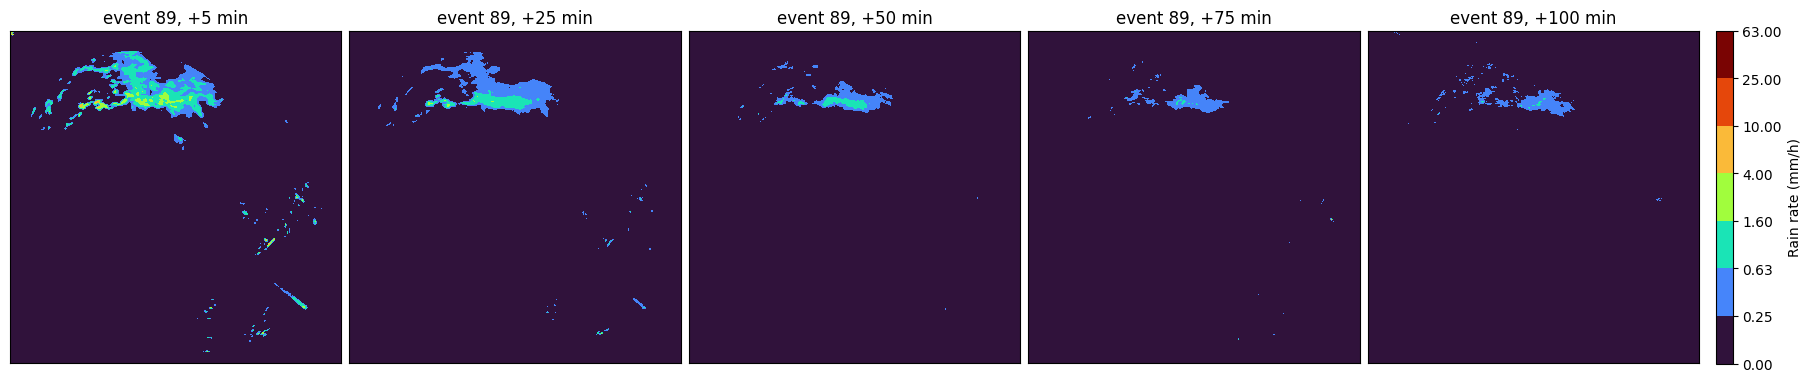

In [9]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import zarr
%matplotlib inline
PRED_ZARR = Path("/scratch/brussel/114/vsc11442/mlcast_predictions/test_2021_6hourly/predictions/ldcast/ldcast_full_2021_month12.zarr")

root = zarr.open_group(str(PRED_ZARR), mode="r")
print("arrays:", list(root.array_keys()))
print("attrs:", dict(root.attrs))

fc = root["forecast"]   # expected: event, member, lead, y, x
print("forecast shape:", fc.shape)

rng = np.random.default_rng()
event_idx = int(rng.integers(0, fc.shape[0]))

pred = np.asarray(fc[event_idx], dtype=np.float32)   # member, lead, y, x
mean = np.nanmean(pred, axis=0)                      # lead, y, x

print("event_idx:", event_idx)
print("finite fraction:", np.isfinite(pred).mean())
print("min/max:", np.nanmin(pred), np.nanmax(pred))
print("p50/p95/p99:", np.nanpercentile(pred, [50, 95, 99]))

FRAMES = [0, 4, 9, 14, 19]   # +5, +25, +50, +75, +100 min
BOUNDS = [0, 0.25, 0.63, 1.6, 4, 10, 25, 63]

cmap = plt.get_cmap("turbo").copy()
cmap.set_under("white")
cmap.set_bad("white")
norm = mcolors.BoundaryNorm(BOUNDS, cmap.N)

fig, axes = plt.subplots(1, len(FRAMES), figsize=(18, 4), constrained_layout=True)

for ax, lead_idx in zip(axes, FRAMES):
    field = mean[lead_idx]
    im = ax.imshow(field, origin="upper", cmap=cmap, norm=norm)
    ax.set_title(f"event {event_idx}, +{(lead_idx + 1) * 5} min")
    ax.set_xticks([])
    ax.set_yticks([])

cbar = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.01)
cbar.set_label("Rain rate (mm/h)")

plt.show()

In [10]:
import numpy as np
import zarr
from pathlib import Path

PRED_ZARR = Path("/scratch/brussel/114/vsc11442/mlcast_predictions/test_2021_6hourly/predictions/ldcast/ldcast_full_2021_month12.zarr")
root = zarr.open_group(str(PRED_ZARR), mode="r")
fc = root["forecast"]   # event, member, lead, y, x

def diagnose_event(event_idx):
    pred = np.asarray(fc[event_idx], dtype=np.float32)
    mean = np.nanmean(pred, axis=0)

    print("=" * 80)
    print("event", event_idx)
    print("member forecast shape:", pred.shape)

    for name, arr in [("all members", pred), ("ensemble mean", mean)]:
        finite = np.isfinite(arr)
        vals = arr[finite]
        print("\n", name)
        print("finite fraction:", finite.mean())
        print("min/max:", float(vals.min()), float(vals.max()))
        print("p50/p90/p95/p99/p99.9:", np.percentile(vals, [50, 90, 95, 99, 99.9]))
        print("frac > 10 mm/h:", float((vals > 10).mean()))
        print("frac > 25 mm/h:", float((vals > 25).mean()))
        print("frac > 63 mm/h:", float((vals > 63).mean()))
        print("frac >= 200 mm/h:", float((vals >= 200).mean()))

for i in [9, 21, 36, 103, 110]:
    diagnose_event(i)

event 9
member forecast shape: (20, 20, 704, 704)

 all members
finite fraction: 1.0
min/max: 0.036468505859375 205.0
p50/p90/p95/p99/p99.9: [3.98864746e-02 4.27551270e-02 1.17858887e-01 2.05000000e+02
 2.05000000e+02]
frac > 10 mm/h: 0.027316864265883263
frac > 25 mm/h: 0.027315830199186465
frac > 63 mm/h: 0.02731480117671746
frac >= 200 mm/h: 0.027313555252453513

 ensemble mean
finite fraction: 1.0
min/max: 0.036468505859375 205.0
p50/p90/p95/p99/p99.9: [10.28464508 10.29059029 10.30056477 10.39884758 10.66084836]
frac > 10 mm/h: 0.5462407387977789
frac > 25 mm/h: 5.3468814566115706e-06
frac > 63 mm/h: 2.219460227272727e-06
frac >= 200 mm/h: 2.0176911157024793e-07
event 21
member forecast shape: (20, 20, 704, 704)

 all members
finite fraction: 1.0
min/max: 0.036468505859375 205.0
p50/p90/p95/p99/p99.9: [3.98559570e-02 4.27551270e-02 1.81518555e-01 2.05000000e+02
 2.05000000e+02]
frac > 10 mm/h: 0.028634068512719525
frac > 25 mm/h: 0.028167210098140497
frac > 63 mm/h: 0.027839930510

In [11]:
def diagnose_members(event_idx, lead_idx=0):
    pred = np.asarray(fc[event_idx], dtype=np.float32)  # member, lead, y, x

    print("=" * 80)
    print("event", event_idx, "lead", lead_idx)

    for m in range(pred.shape[0]):
        arr = pred[m, lead_idx]
        vals = arr[np.isfinite(arr)]
        if vals.size == 0:
            print(f"member {m:02d}: all NaN")
            continue

        print(
            f"member {m:02d}: "
            f"max={vals.max():.2f}, "
            f"p99={np.percentile(vals, 99):.2f}, "
            f"frac>=200={(vals >= 200).mean():.4f}, "
            f"frac>25={(vals > 25).mean():.4f}"
        )

diagnose_members(21, lead_idx=0)
diagnose_members(9, lead_idx=0)
diagnose_members(110, lead_idx=0)

event 21 lead 0
member 00: max=102.44, p99=0.04, frac>=200=0.0000, frac>25=0.0000
member 01: max=205.00, p99=0.04, frac>=200=0.0000, frac>25=0.0000
member 02: max=17.19, p99=0.04, frac>=200=0.0000, frac>25=0.0000
member 03: max=205.00, p99=0.04, frac>=200=0.0000, frac>25=0.0000
member 04: max=91.50, p99=0.04, frac>=200=0.0000, frac>25=0.0000
member 05: max=62.94, p99=0.04, frac>=200=0.0000, frac>25=0.0000
member 06: max=205.00, p99=0.04, frac>=200=0.0000, frac>25=0.0000
member 07: max=205.00, p99=0.04, frac>=200=0.0000, frac>25=0.0000
member 08: max=26.56, p99=0.04, frac>=200=0.0000, frac>25=0.0000
member 09: max=205.00, p99=0.04, frac>=200=0.0000, frac>25=0.0000
member 10: max=205.00, p99=0.04, frac>=200=0.0000, frac>25=0.0000
member 11: max=5.28, p99=0.04, frac>=200=0.0000, frac>25=0.0000
member 12: max=205.00, p99=205.00, frac>=200=0.0852, frac>25=0.0994
member 13: max=205.00, p99=0.04, frac>=200=0.0000, frac>25=0.0000
member 14: max=37.28, p99=0.04, frac>=200=0.0000, frac>25=0.0000

arrays: ['event_index', 'forecast', 't_start', 'start_time']
attrs: {'kind': 'forecast', 'model': 'pysteps', 'split': 'full', 'checkpoint': '', 'unit': 'mm/h', 'tin': 4, 'tout': 20, 'target_size': 704, 'n_members': 20, 'month': -1, 'event_scope': 'full_year', 'prediction_masking': 'none; validity masks are stored in the observation Zarr'}
forecast shape: (1460, 20, 20, 704, 704)


/tmp/ipykernel_1045624/3472355198.py:20: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(pred, axis=0)                      # lead, y, x


event_idx: 759
finite fraction: 0.96420118095461
min/max: 0.0 62.59375
p50/p95/p99: [0.         0.03646851 0.44677734]


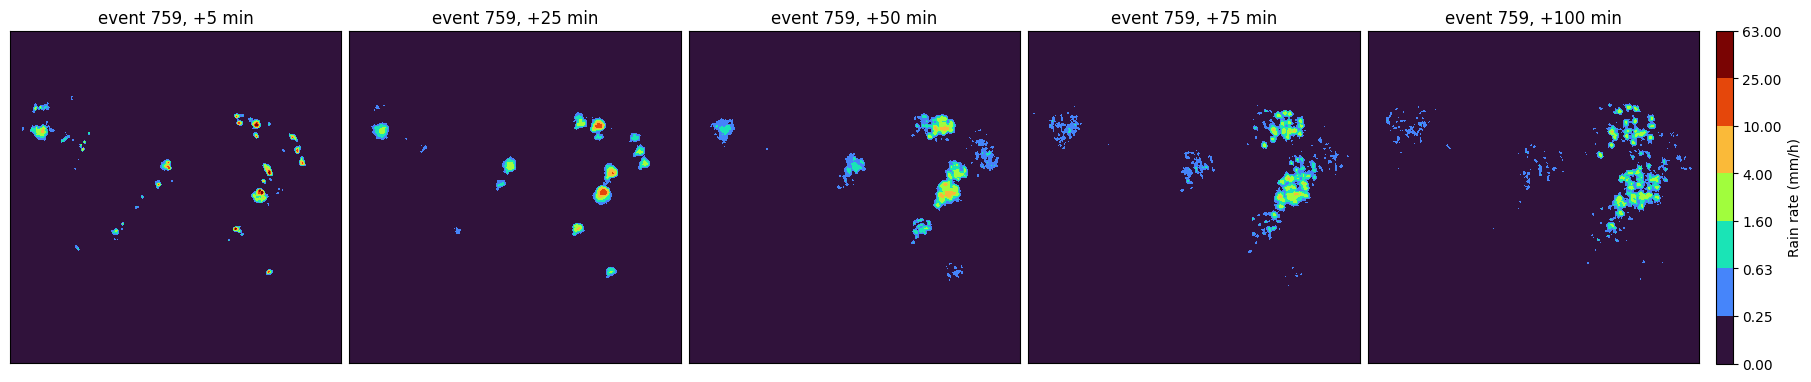

In [6]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import zarr
%matplotlib inline
PRED_ZARR = Path("/scratch/brussel/114/vsc11442/mlcast_predictions/test_2021_6hourly/predictions/pysteps/pysteps_full_2021.zarr")

root = zarr.open_group(str(PRED_ZARR), mode="r")
print("arrays:", list(root.array_keys()))
print("attrs:", dict(root.attrs))

fc = root["forecast"]   # expected: event, member, lead, y, x
print("forecast shape:", fc.shape)

rng = np.random.default_rng()
event_idx = int(rng.integers(0, fc.shape[0]))

pred = np.asarray(fc[event_idx], dtype=np.float32)   # member, lead, y, x
mean = np.nanmean(pred, axis=0)                      # lead, y, x

print("event_idx:", event_idx)
print("finite fraction:", np.isfinite(pred).mean())
print("min/max:", np.nanmin(pred), np.nanmax(pred))
print("p50/p95/p99:", np.nanpercentile(pred, [50, 95, 99]))

FRAMES = [0, 4, 9, 14, 19]   # +5, +25, +50, +75, +100 min
BOUNDS = [0, 0.25, 0.63, 1.6, 4, 10, 25, 63]

cmap = plt.get_cmap("turbo").copy()
cmap.set_under("white")
cmap.set_bad("white")
norm = mcolors.BoundaryNorm(BOUNDS, cmap.N)

fig, axes = plt.subplots(1, len(FRAMES), figsize=(18, 4), constrained_layout=True)

for ax, lead_idx in zip(axes, FRAMES):
    field = mean[lead_idx]
    im = ax.imshow(field, origin="upper", cmap=cmap, norm=norm)
    ax.set_title(f"event {event_idx}, +{(lead_idx + 1) * 5} min")
    ax.set_xticks([])
    ax.set_yticks([])

cbar = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.01)
cbar.set_label("Rain rate (mm/h)")

plt.show()

Pysteps configuration file found at: /data/brussel/114/vsc11442/venvs/mlcast_ldcast/lib/python3.12/site-packages/pysteps/pystepsrc

PySTEPS workflow event: 168615
Actual PySTEPS input shape: (3, 704, 704)
Displayed inputs: ['t-10', 't-5', 't0']
Running final PySTEPS configuration: 20 members, 3 inputs, 20 forecast steps
Inputs validated and initialized successfully.
Computing STEPS nowcast
-----------------------

Inputs
------
input dimensions: 704x704
km/pixel:         1.0
time step:        5 minutes

Methods
-------
extrapolation:          semilagrangian
bandpass filter:        gaussian
decomposition:          fft
noise generator:        nonparametric
noise adjustment:       no
velocity perturbator:   bps
conditional statistics: no
precip. mask method:    incremental
probability matching:   cdf
FFT method:             numpy
domain:                 spatial

Parameters
----------
number of time steps:     20
ensemble size:            20
parallel threads:         1
number of cascade le

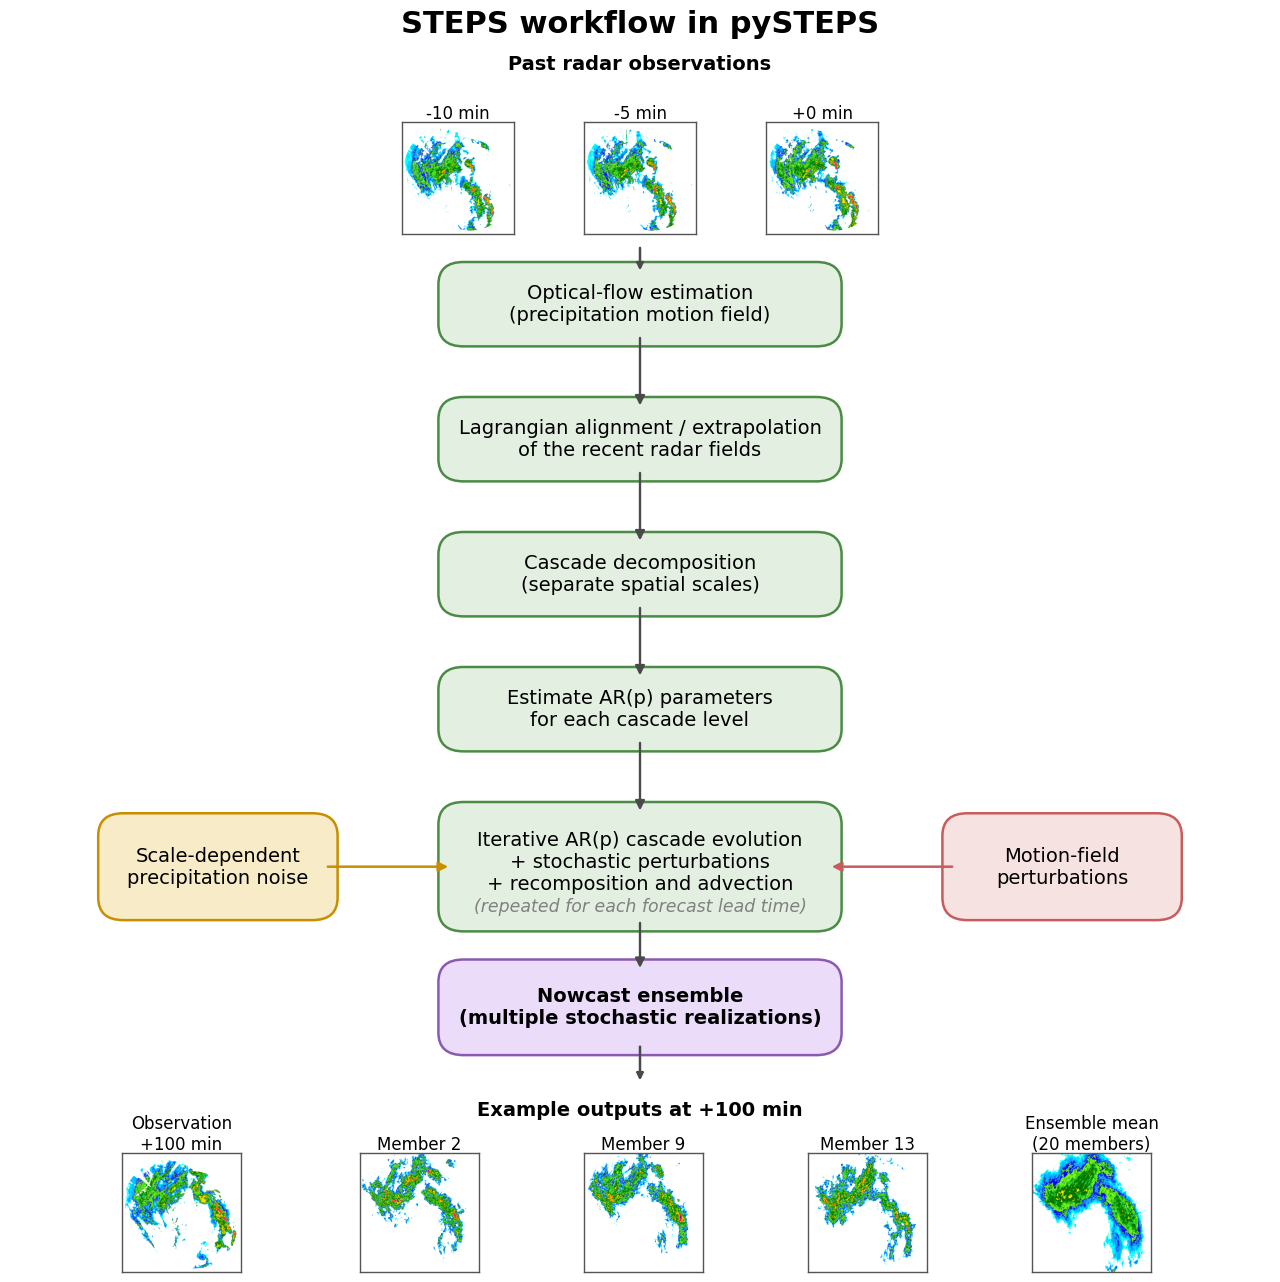

In [1]:
# ============================================================
# PySTEPS WORKFLOW FIGURE
#
# Final thesis PySTEPS inference:
# - latest THREE radar fields
# - rain rate -> dBR
# - 0.1 mm/h rain/no-rain threshold
# - -15 dBR dry value
# - Lucas-Kanade optical flow
# - AR(2) STEPS
# - 6 cascade levels
# - FFT / Gaussian cascade decomposition
# - nonparametric precipitation noise
# - BPS motion perturbations
# - incremental precipitation mask
# - CDF probability matching
# - ONE 20-member STEPS call
# - no outside-domain zero monkey patch
# - no deterministic fallback
#
# Figure layout/design is otherwise kept unchanged.
# ============================================================

import inspect
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D

from pysteps import motion, nowcasts
from pysteps.utils import transformation

%matplotlib inline


# ============================================================
# SETTINGS
# ============================================================

# Keep the same workflow example event as before.
WORKFLOW_EVENT_T = 168615

# Same displayed forecast lead as before.
OUTPUT_LEAD_IDX = 19          # +100 min
OUTPUT_LEAD_MIN = (OUTPUT_LEAD_IDX + 1) * 5

# Final common ensemble size.
PYSTEPS_N_MEMBERS = 20

# Same reproducible seed used in thesis inference.
RANDOM_MEMBER_SEED = 42

# Probability field shown in the workflow.
EXCEEDANCE_THRESHOLD = 1.0    # mm/h

# Final reference-style PySTEPS thresholds.
PYSTEPS_RAIN_THRESHOLD_MM_H = 0.1
PYSTEPS_DRY_VALUE_DBR = -15.0
PYSTEPS_RAIN_THRESHOLD_DBR = -10.0

TOUT = 20
TARGET_SIZE = 704

RADAR_ZARR = (
    "/data/brussel/vo/000/bvo00029/data/observations/"
    "RADCLIMrates_2017_2023_5m_be_v1/"
    "RADCLIMrates_f16.zarr"
)

RADAR_VAR = "precip_intensity_EDK"


# ============================================================
# LOAD THE SAME EVENT FROM RADCLIM
# ============================================================

ds = xr.open_zarr(RADAR_ZARR)

# t_start refers to the first of the FOUR common model inputs:
#
#   index 0 = t-15
#   index 1 = t-10
#   index 2 = t-5
#   index 3 = t0
#
# PySTEPS finally uses only indices 1, 2, 3.

past_rr_four = (
    ds[RADAR_VAR]
    .isel(
        time=slice(
            WORKFLOW_EVENT_T,
            WORKFLOW_EVENT_T + 4,
        )
    )
    .values
    .astype(np.float32)
)

if past_rr_four.shape[0] != 4:
    raise ValueError(
        f"Expected four source radar frames, got {past_rr_four.shape}"
    )


# ============================================================
# PAD 700 x 700 -> 704 x 704
# Same spatial domain used by the other models.
# ============================================================

def pad_to_target(
    arr,
    target_size=TARGET_SIZE,
    fill_value=np.nan,
):
    arr = np.asarray(arr)

    h = arr.shape[-2]
    w = arr.shape[-1]

    if h > target_size or w > target_size:
        raise ValueError(
            f"Cannot pad {h}x{w} to {target_size}x{target_size}"
        )

    dh = target_size - h
    dw = target_size - w

    top = dh // 2
    bottom = dh - top

    left = dw // 2
    right = dw - left

    pad_spec = [(0, 0)] * arr.ndim
    pad_spec[-2] = (top, bottom)
    pad_spec[-1] = (left, right)

    return np.pad(
        arr,
        pad_spec,
        mode="constant",
        constant_values=fill_value,
    )


past_rr_four = pad_to_target(
    past_rr_four,
    target_size=TARGET_SIZE,
    fill_value=np.nan,
).astype(np.float32)


# ============================================================
# IMPORTANT:
# FINAL PySTEPS INPUT = latest THREE fields only
#
# Remove t-15.
#
# These correspond to:
#   t-10
#   t-5
#   t0
# ============================================================

past_rr = past_rr_four[-3:].copy()

if past_rr.shape != (
    3,
    TARGET_SIZE,
    TARGET_SIZE,
):
    raise ValueError(
        f"Unexpected PySTEPS input shape: {past_rr.shape}"
    )

print(
    "PySTEPS workflow event:",
    WORKFLOW_EVENT_T,
)

print(
    "Actual PySTEPS input shape:",
    past_rr.shape,
)

print(
    "Displayed inputs:",
    ["t-10", "t-5", "t0"],
)


# ============================================================
# FINAL PySTEPS PREPROCESSING
# rain rate -> logarithmic rain rate (dBR)
# ============================================================

past_dbr, _ = transformation.dB_transform(
    past_rr,
    threshold=PYSTEPS_RAIN_THRESHOLD_MM_H,
    zerovalue=PYSTEPS_DRY_VALUE_DBR,
)

past_dbr = np.asarray(
    past_dbr,
    dtype=np.float32,
)

# Padding / unavailable radar pixels are represented as dry
# for the PySTEPS input, matching the final workflow.
past_dbr[
    ~np.isfinite(past_dbr)
] = PYSTEPS_DRY_VALUE_DBR


# ============================================================
# LUCAS-KANADE OPTICAL FLOW
# ============================================================

oflow_method = motion.get_method("LK")

velocity = np.asarray(
    oflow_method(past_dbr),
    dtype=np.float32,
)

expected_velocity_shape = (
    2,
    TARGET_SIZE,
    TARGET_SIZE,
)

if velocity.shape != expected_velocity_shape:
    raise ValueError(
        f"Unexpected velocity shape {velocity.shape}; "
        f"expected {expected_velocity_shape}"
    )

if not np.isfinite(velocity).all():
    raise RuntimeError(
        "Non-finite values found in PySTEPS optical-flow field."
    )


# Motion magnitude used only as the workflow thumbnail.
motion_img = np.hypot(
    velocity[0],
    velocity[1],
).astype(np.float32)


# ============================================================
# FINAL STEPS INFERENCE
# ============================================================

steps_method = nowcasts.get_method("steps")

steps_signature = inspect.signature(
    steps_method
)

# PySTEPS changed the threshold argument name across versions.
if "R_thr" in steps_signature.parameters:

    threshold_kw = {
        "R_thr":
            PYSTEPS_RAIN_THRESHOLD_DBR
    }

elif "precip_thr" in steps_signature.parameters:

    threshold_kw = {
        "precip_thr":
            PYSTEPS_RAIN_THRESHOLD_DBR
    }

else:

    raise RuntimeError(
        "Installed PySTEPS STEPS implementation has neither "
        "'R_thr' nor 'precip_thr'."
    )


print(
    "Running final PySTEPS configuration:",
    f"{PYSTEPS_N_MEMBERS} members,",
    "3 inputs,",
    f"{TOUT} forecast steps",
)


forecast_dbr = steps_method(
    past_dbr,
    velocity,
    TOUT,

    n_ens_members=PYSTEPS_N_MEMBERS,
    n_cascade_levels=6,

    kmperpixel=1.0,
    timestep=5,

    decomp_method="fft",
    bandpass_filter_method="gaussian",

    noise_method="nonparametric",
    vel_pert_method="bps",

    mask_method="incremental",
    probmatching_method="cdf",

    seed=RANDOM_MEMBER_SEED,
    num_workers=1,

    **threshold_kw,
)


forecast_dbr = np.asarray(
    forecast_dbr,
    dtype=np.float32,
)

expected_forecast_shape = (
    PYSTEPS_N_MEMBERS,
    TOUT,
    TARGET_SIZE,
    TARGET_SIZE,
)

if forecast_dbr.shape != expected_forecast_shape:
    raise ValueError(
        f"Unexpected STEPS output shape {forecast_dbr.shape}; "
        f"expected {expected_forecast_shape}"
    )


# ============================================================
# dBR -> RAIN RATE
# Same inverse transformation used in final inference.
# ============================================================

forecast_rr, _ = transformation.dB_transform(
    forecast_dbr,
    threshold=PYSTEPS_RAIN_THRESHOLD_DBR,
    inverse=True,
)

forecast_rr = np.asarray(
    forecast_rr,
    dtype=np.float32,
)

forecast_rr = np.where(
    np.isfinite(forecast_rr),
    np.maximum(forecast_rr, 0.0),
    np.nan,
).astype(np.float32)


print(
    "Final PySTEPS forecast shape:",
    forecast_rr.shape,
)


# ============================================================
# DATA FOR THE WORKFLOW FIGURE
# ============================================================

# Exactly THREE actual PySTEPS inputs.
past_frames = [
    past_rr[0],
    past_rr[1],
    past_rr[2],
]


# Observation at the displayed lead time (+100 min).
obs_rr = (
    ds[RADAR_VAR]
    .isel(time=WORKFLOW_EVENT_T + 4 + OUTPUT_LEAD_IDX)
    .values
    .astype(np.float32)
)
obs_rr = pad_to_target(
    obs_rr,
    target_size=TARGET_SIZE,
    fill_value=np.nan,
).astype(np.float32)
obs_rr = np.where(
    np.isfinite(obs_rr),
    np.maximum(obs_rr, 0.0),
    np.nan,
).astype(np.float32)


# All 20 members at the same +100-min lead shown previously.
members_at_lead = forecast_rr[
    :,
    OUTPUT_LEAD_IDX,
]


# ------------------------------------------------------------
# Exact 20-member ensemble mean
# ------------------------------------------------------------

ensemble_mean = np.nanmean(
    members_at_lead,
    axis=0,
).astype(np.float32)


# ------------------------------------------------------------
# Exceedance probability
# Ignore unavailable values rather than counting them as
# non-exceedances.
# ------------------------------------------------------------

finite_members = np.isfinite(
    members_at_lead
)

n_finite = finite_members.sum(
    axis=0
)

n_exceed = (
    finite_members
    &
    (
        members_at_lead
        >= EXCEEDANCE_THRESHOLD
    )
).sum(
    axis=0
)

exceed_prob = np.divide(
    n_exceed,
    n_finite,
    out=np.full(
        n_finite.shape,
        np.nan,
        dtype=np.float32,
    ),
    where=n_finite > 0,
).astype(np.float32)


# ------------------------------------------------------------
# Three reproducibly selected example members.
# Only three are DISPLAYED; inference still uses all 20.
# ------------------------------------------------------------

rng = np.random.default_rng(
    RANDOM_MEMBER_SEED
)

display_member_indices = [1, 8, 12]

ensemble_members = [
    members_at_lead[i].copy()
    for i in display_member_indices
]

print(
    "Displayed members:",
    [
        i + 1
        for i in display_member_indices
    ],
)

print(
    "Ensemble mean uses:",
    PYSTEPS_N_MEMBERS,
    "members",
)

print(
    "Workflow output lead:",
    OUTPUT_LEAD_MIN,
    "min",
)


# ============================================================
# OPTIONAL PROCESS THUMBNAILS
# ============================================================

# Motion-field magnitude from the REAL updated inference.
# motion_img already defined above.


# For the existing "advected field" thumbnail, produce a
# one-step deterministic advection using the SAME dBR input
# and SAME optical-flow field.
extrapolation_method = nowcasts.get_method(
    "extrapolation"
)

advected_dbr = extrapolation_method(
    past_dbr[-1],
    velocity,
    1,
)

advected_dbr = np.asarray(
    advected_dbr,
    dtype=np.float32,
)

advected_rr, _ = transformation.dB_transform(
    advected_dbr,
    threshold=PYSTEPS_RAIN_THRESHOLD_DBR,
    inverse=True,
)

advected_rr = np.asarray(
    advected_rr,
    dtype=np.float32,
)

advected_rr = np.where(
    np.isfinite(advected_rr),
    np.maximum(advected_rr, 0.0),
    np.nan,
).astype(np.float32)

latest_field_img = advected_rr[0]


# Do not fabricate an internal cascade image.
# The original figure already allowed this thumbnail to be optional.
cascade_img = None


# Representative actual stochastic recomposed forecast.
recompose_img = members_at_lead[
    display_member_indices[0]
].copy()


# ============================================================
# ORIGINAL FIGURE CODE
# ============================================================

# ============================================================
# SETTINGS
# ============================================================

# Match the precipitation visualization used in plot_results_qualitative.
precip_colors = [
    "white", "cyan", "deepskyblue", "dodgerblue", "blue",
    "chartreuse", "limegreen", "green", "darkgreen",
    "yellow", "gold", "orange", "red", "magenta", "darkmagenta",
]

precip_levels = [
    0.0, 0.1, 0.25, 0.4, 0.63, 1, 1.6, 2.5,
    4, 6.3, 10, 16, 25, 40, 63, 100,
]

precip_cmap = mcolors.ListedColormap(precip_colors)
precip_cmap.set_bad(color=(1, 1, 1, 0))
precip_norm = mcolors.BoundaryNorm(
    precip_levels,
    precip_cmap.N,
    clip=True,
)

prob_cmap = "viridis"
img_vmin = 0.0
img_vmax = 10.0


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def add_box(
    ax,
    x,
    y,
    w,
    h,
    text,
    fc,
    ec,
    fontsize=11,
    lw=1.8,
    rounding=0.02,
    fontweight="normal",
    zorder=2,
):
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle=(
            f"round,pad=0.01,"
            f"rounding_size={rounding}"
        ),
        linewidth=lw,
        edgecolor=ec,
        facecolor=fc,
        zorder=zorder,
    )

    ax.add_patch(patch)

    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight=fontweight,
        wrap=True,
        zorder=zorder + 1,
    )

    return patch


def add_arrow(
    ax,
    x1,
    y1,
    x2,
    y2,
    color="#4A4A4A",
    lw=1.7,
    arrowstyle="-|>",
    mutation_scale=14,
    connectionstyle="arc3,rad=0.0",
    zorder=3,
):
    arr = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle=arrowstyle,
        mutation_scale=mutation_scale,
        linewidth=lw,
        color=color,
        connectionstyle=connectionstyle,
        zorder=zorder,
    )

    ax.add_patch(arr)

    return arr


def add_image_panel(
    fig,
    rect,
    image,
    title,
    cmap="turbo",
    vmin=None,
    vmax=None,
    norm=None,
    mask_below=None,
    title_size=9,
    frame_color="#555555",
):
    """
    rect = [left, bottom, width, height]
    in figure coordinates
    """

    image_ax = fig.add_axes(rect)

    if image is None:

        image_ax.set_facecolor(
            "#F2F2F2"
        )

        image_ax.text(
            0.5,
            0.5,
            "example\nimage",
            ha="center",
            va="center",
            fontsize=9,
            color="gray",
        )

    else:

        image_to_plot = np.asarray(
            image,
            dtype=np.float32,
        )

        if mask_below is not None:
            image_to_plot = np.ma.masked_where(
                (~np.isfinite(image_to_plot))
                | (image_to_plot < mask_below),
                image_to_plot,
            )

        imshow_kwargs = {
            "cmap": cmap,
        }

        if norm is not None:
            imshow_kwargs["norm"] = norm
        else:
            imshow_kwargs["vmin"] = vmin
            imshow_kwargs["vmax"] = vmax

        image_ax.imshow(
            image_to_plot,
            **imshow_kwargs,
        )

    image_ax.set_xticks([])
    image_ax.set_yticks([])

    for spine in image_ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_edgecolor(
            frame_color
        )

    image_ax.set_title(
        title,
        fontsize=title_size,
        pad=2,
    )

    return image_ax


def add_group_label(
    fig,
    x,
    y,
    text,
    fontsize=11,
    weight="bold",
    color="gray",
):
    fig.text(
        x,
        y,
        text,
        fontsize=fontsize,
        fontweight=weight,
        color=color,
        ha="left",
        va="center",
    )


# ============================================================
# CHECK INPUTS
# ============================================================

if past_frames is not None:
    assert len(past_frames) == 3, (
        "past_frames must contain exactly 3 arrays"
    )

if ensemble_members is not None:
    assert len(ensemble_members) == 3, (
        "ensemble_members must contain exactly 3 arrays"
    )


# ============================================================
# FIGURE
# ============================================================

fig = plt.figure(
    figsize=(14, 12.5)
)

ax = fig.add_axes(
    [0.05, 0.05, 0.90, 0.90]
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")


# ------------------------------------------------------------
# Colors
# ------------------------------------------------------------

input_fc = "#DCE7F7"
input_ec = "#436CA8"

proc_fc = "#E3F0E1"
proc_ec = "#4A8B45"

stoch_fc = "#F8EBC8"
stoch_ec = "#C78E00"

aux_fc = "#F7E2E2"
aux_ec = "#C85C5C"

output_fc = "#EBDDFA"
output_ec = "#8A5AB2"


# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

fig.text(
    0.5,
    0.990,
    "STEPS workflow in pySTEPS",
    ha="center",
    va="top",
    fontsize=22,
    fontweight="bold",
)



# ------------------------------------------------------------
# Section labels removed
# ------------------------------------------------------------

# ------------------------------------------------------------
# Example past radar frames
#
# ONLY CHANGE HERE:
# 4 frames -> actual 3 PySTEPS input frames
# t-10, t-5, t0
# ------------------------------------------------------------

frame_w = 0.08
frame_h = 0.10
frame_y = 0.805

# Three actual PySTEPS inputs, centered under the title.
frame_xs = [
    0.33,
    0.46,
    0.59,
]

frame_titles = [
    "-10 min",
    "-5 min",
    "+0 min",
]

for i, x in enumerate(
    frame_xs
):

    img = (
        None
        if past_frames is None
        else past_frames[i]
    )

    add_image_panel(
        fig,
        [
            x,
            frame_y,
            frame_w,
            frame_h,
        ],
        img,
        frame_titles[i],
        cmap=precip_cmap,
        norm=precip_norm,
        mask_below=precip_levels[1],
        title_size=12,
    )


fig.text(
    0.5,
    0.942,
    "Past radar observations",
    ha="center",
    fontsize=14,
    fontweight="bold",
)


# Arrow from radar frames to the first processing box (centered)
ax.annotate(
    "",
    xy=(0.50, 0.810),
    xytext=(0.50, 0.835),
    arrowprops=dict(
        arrowstyle="-|>",
        lw=1.8,
        color="#4A4A4A",
    ),
)


# ------------------------------------------------------------
# Main workflow boxes
# ------------------------------------------------------------

boxes = {
    "motion":
        (0.35, 0.755, 0.3, 0.055),

    "advect":
        (0.35, 0.635, 0.3, 0.055),

    "cascade":
        (0.35, 0.515, 0.3, 0.055),

    "ar_params":
        (0.35, 0.395, 0.3, 0.055),

    "ar":
        (0.35, 0.235, 0.3, 0.095),

    "ensemble":
        (0.35, 0.125, 0.3, 0.065),
}


add_box(
    ax,
    *boxes["motion"],
    (
        "Optical-flow estimation\n"
        "(precipitation motion field)"
    ),
    fc=proc_fc,
    ec=proc_ec,
    fontsize=14,
)


add_box(
    ax,
    *boxes["advect"],
    (
        "Lagrangian alignment / extrapolation\n"
        "of the recent radar fields"
    ),
    fc=proc_fc,
    ec=proc_ec,
    fontsize=14,
)


add_box(
    ax,
    *boxes["cascade"],
    (
        "Cascade decomposition\n"
        "(separate spatial scales)"
    ),
    fc=proc_fc,
    ec=proc_ec,
    fontsize=14,
)


add_box(
    ax,
    *boxes["ar_params"],
    (
        "Estimate AR(p) parameters\n"
        "for each cascade level"
    ),
    fc=proc_fc,
    ec=proc_ec,
    fontsize=14,
)


# Draw AR box without text
add_box(
    ax,
    *boxes["ar"],
    "",
    fc=proc_fc,
    ec=proc_ec,
)

# Main AR text
ax.text(
    0.50,
    0.287,
    "Iterative AR(p) cascade evolution\n"
    "+ stochastic perturbations\n"
    "+ recomposition and advection",
    ha="center",
    va="center",
    fontsize=14,
    zorder=3,
)

# Small explanatory line
ax.text(
    0.50,
    0.247,
    "(repeated for each forecast lead time)",
    ha="center",
    va="center",
    fontsize=12.5,
    color="gray",
    style="italic",
    zorder=3,
)


add_box(
    ax,
    *boxes["ensemble"],
    (
        "Nowcast ensemble\n"
        "(multiple stochastic realizations)"
    ),
    fc=output_fc,
    ec=output_ec,
    fontsize=14,
    fontweight="bold",
)


# ------------------------------------------------------------
# Main arrows
# ------------------------------------------------------------

def bottom_center(b):
    x, y, w, h = b
    return x + w / 2, y


def top_center(b):
    x, y, w, h = b
    return x + w / 2, y + h


add_arrow(
    ax,
    *bottom_center(
        boxes["motion"]
    ),
    *top_center(
        boxes["advect"]
    ),
)


add_arrow(
    ax,
    *bottom_center(
        boxes["advect"]
    ),
    *top_center(
        boxes["cascade"]
    ),
)


add_arrow(
    ax,
    *bottom_center(
        boxes["cascade"]
    ),
    *top_center(
        boxes["ar_params"]
    ),
)


add_arrow(
    ax,
    *bottom_center(
        boxes["ar_params"]
    ),
    *top_center(
        boxes["ar"]
    ),
)


add_arrow(
    ax,
    *bottom_center(
        boxes["ar"]
    ),
    *top_center(
        boxes["ensemble"]
    ),
)


# ------------------------------------------------------------
# Side stochastic boxes
# ------------------------------------------------------------

noise_box = (
    0.08,
    0.245,
    0.17,
    0.075,
)

motionp_box = (
    0.75,
    0.245,
    0.17,
    0.075,
)


add_box(
    ax,
    *noise_box,
    (
        "Scale-dependent\n"
        "precipitation noise"
    ),
    fc=stoch_fc,
    ec=stoch_ec,
    fontsize=14.0,
)


add_box(
    ax,
    *motionp_box,
    (
        "Motion-field\n"
        "perturbations"
    ),
    fc=aux_fc,
    ec=aux_ec,
    fontsize=14.0,
)


# ------------------------------------------------------------
# Side arrows
# ------------------------------------------------------------

x, y, w, h = noise_box

noise_end = (
    x + w,
    y + h / 2,
)

x2, y2, w2, h2 = boxes["ar"]

ar_left = (
    x2,
    y2 + h2 / 2,
)

add_arrow(
    ax,
    noise_end[0],
    noise_end[1],
    ar_left[0],
    ar_left[1],
    color=stoch_ec,
    lw=1.8,
)


x, y, w, h = motionp_box

motionp_start = (
    x,
    y + h / 2,
)

ar_right = (
    x2 + w2,
    y2 + h2 / 2,
)

add_arrow(
    ax,
    motionp_start[0],
    motionp_start[1],
    ar_right[0],
    ar_right[1],
    color=aux_ec,
    lw=1.8,
)


# ------------------------------------------------------------
# Process thumbnails removed
# ------------------------------------------------------------

# ------------------------------------------------------------
# Output panels: ensemble members + products
# ------------------------------------------------------------

member_y = -0.02
member_w = 0.085
member_h = 0.095

obs_x = 0.13
member_xs = [
    0.3,
    0.46,
    0.62,
]

member_titles = [
    "Member 2",
    "Member 9",
    "Member 13",
]


for i, x in enumerate(
    member_xs
):

    img = (
        None
        if ensemble_members is None
        else ensemble_members[i]
    )

    add_image_panel(
        fig,
        [
            x,
            member_y,
            member_w,
            member_h,
        ],
        img,
        member_titles[i],
        cmap=precip_cmap,
        norm=precip_norm,
        mask_below=precip_levels[1],
        title_size=12,
    )


fig.text(
    0.50,
    0.105,
    f"Example outputs at +{OUTPUT_LEAD_MIN} min",
    ha="center",
    fontsize=14,
    fontweight="bold",
)


add_image_panel(
    fig,
    [
        obs_x,
        member_y,
        member_w,
        member_h,
    ],
    obs_rr,
    f"Observation\n+{OUTPUT_LEAD_MIN} min",
    cmap=precip_cmap,
    norm=precip_norm,
    mask_below=precip_levels[1],
    title_size=12,
)


add_image_panel(
    fig,
    [
        0.78,
        member_y,
        member_w,
        member_h,
    ],
    ensemble_mean,
    "Ensemble mean\n(20 members)",
    cmap=precip_cmap,
    norm=precip_norm,
    mask_below=precip_levels[1],
    title_size=12,
)


# Arrow from ensemble box to the center of the output heading
ax.annotate(
    "",
    xy=(0.50, 0.090),
    xytext=(0.50, 0.125),
    arrowprops=dict(
        arrowstyle="-|>",
        lw=1.8,
        color="#4A4A4A",
    ),
)



plt.savefig(
    "pysteps_workflow.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()